# Opening Economy Extension

Business Cycles and Fluctuations - AE2E6

> **Objectives**
>
> -   Modify a modfile with a model extension.
> -   Compare model solutions for different parameterizations.

> **Modfiles**

Import dynare emulation from dyno.py.

In [1]:
from dyno import dynare

# Small Open Economy

Start from the same rbc [model](rbc_fixed.mod) as in last tutorial
session. Assume the representative agent can save $b^{\star}_t$ as
foreign assets, remunerated at a constant interest rate $r^{\star}-1$.

1.  **Write the new budget constraint for the representative
    household.**

> **Correction**
>
> At given date t, the household saves $b^{\star}_t$ in the foreigh
> country and receives repayment $b^{\star}_{t-1}$ plus interests
> $(r^{\star} − 1)b^{\star}_{t-1}$ . Starting from the RBC constraint,
> the new constraint becomes:
> $$c_t + i_t + b^ {\star}_t \leq w_t n_t + r_t k_{t-1} + r^ {\star} b^{\star}_{t-1}$$
>
> and the lagrangian is:
>
> $$\mathcal{L} = E_t \sum_{j=0}^\infty \beta^j\left[\log c_{t+j} + \chi \dfrac{(1-n_{t+j})^{1-\eta}}{1-\eta} \right.$$
>
> $$+\lambda_{t+j} (w_{t+j}n_{t+j} + r_{t+j}k_{t+j-1} - c_{t+j}-k_{t+j} + (1-\delta)k_{t+j-1} + r^* b^*_{t+j-1} - b^*_{t+j} )\Bigg]$$

1.  **Write the new optimality condition.**

> **Correction**
>
> We must add the optimality condition relative to $b^{\star}_t$ : the
> representative household chooses amount of savings to maximise its
> intertemporal utility of consumption. We find :
>
> $$ -\lambda_t + \beta E_t[\lambda_{t+1}r^*]=0$$ or :
> $$ \frac{1}{c_t}=\beta r^* E_t\left[\frac{1}{c_{t+1}} \right]$$

1.  **What is the long run constraint on interest rate $r^{\star}$?**

> **Correction**
>
> In the deterministic steady-state the euler equation implies
> $r^{\star}= \frac{1}{\beta}$ . In principle $r^{\star}$ is a a foreign
> interest rate determined by factors external to the country. Yet
> $\frac{1}{\beta}$ is the only value it can take that is compatible
> with the existence of a long run steady-state. This can be interpreted
> as an arbitrage condition: $\frac{1}{\beta}$ is the domestic intesrest
> rate. If it was lower/higher than world interest rate, there would be
> infinite capital flows from/to the country.
>
> (in a deterministic setting the arbitrage principle implies that all
> investment opportunities must yield the same return)

1.  **Update the modfile (set $\overline{b^{\star}}=0$)**

> **Correction**
>
> To update the modfile, one must declare a new variable $b^{\star}$ and
> the new parameter $r^\star$. The latter is set to $\frac{1}{\beta}$ .
> One must also add the above optimality condition and update the
> equation characterizing the equilibrium on the goods markets. That one
> comes from the budget constraint. Rewriting the budget constraint for
> a small open economy we have:
>
> $$c_t + i_t + b^{\star}_t = w_t n_t + r_t k_{t-1} + r^{\star} b^{\star}_{t-1}$$
>
> Since we assume competitive markets, the firm doesn’t do any profit.
> We have $y_t = w_t n_t + r_t k_{t−1}$ and:
>
> $$c_t + i_t + b^{\star}_t - r^{\star} b^{\star}_{t-1} = y_t$$
>
> Next, we can observe that the static model doesn’t pin down the
> steady-state level of $b^{\star}$ ; we set it to 0, so that the
> steady-state values of all other variables ar unchanged. We thus add
> $b^{\star}=0$ in the `steady_state_model;` block.
>
> Here is the output we get:
>
> ``` python
> # as we modify the modfile, we can check it runs without 
> dynare("rbc_open.mod") # remove the ; to print the result
> ```
>
>     Could not normalize the dynamic model. Variable i is not in the maximum cardinality matching.
>
> <h3>Model: rbc_open</h3>
>
> |              |     |                                        |
> |--------------|-----|----------------------------------------|
> | equations    | 9   |                                        |
> | variables    | 10  |                                        |
> |   endogenous | 9   | y, i, c, n, a, b, k, r, w              |
> |   exogenous  | 1   | epsilon                                |
> | constants    | 8   | alp, bet, del, eta, khi, nss, rho, rst |
>
> <br><h3>Check</h3><br><div style="margin:10px 0 14px 0;"><div style="font-weight:600;color:#0f172a;margin-bottom:6px;">Residuals</div><div style="overflow-x:auto;">
>
> <table data-quarto-postprocess="true" style="border-collapse:collapse;">
> <colgroup>
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> <col style="width: 11%" />
> </colgroup>
> <tbody>
> <tr>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 1
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 2
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 3
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 2.22045e-16
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 4
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 5
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 6
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 7
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 8
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> eq 9
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> </tr>
> </tbody>
> </table>
>
> </div></div><br><div style="margin:10px 0 14px 0;"><div style="font-weight:600;color:#0f172a;margin-bottom:6px;">Generalized Eigenvalues</div><div style="overflow-x:auto;">
>
> <table data-quarto-postprocess="true" style="border-collapse:collapse;">
> <colgroup>
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> <col style="width: 5%" />
> </colgroup>
> <tbody>
> <tr>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 1
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 2
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 3
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 4
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 5
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 6
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 7
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 5.54131e-16
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 8
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 0.95
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 9
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 1
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 10
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> 1.02041
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 11
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 12
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 13
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 14
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 15
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 16
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 17
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> <td
> style="padding: 6px 10px; border: 1px solid #e2e8f0; white-space: nowrap"><div
> style="font-size:11px;color:#64748b;">
> 18
> </div>
> <div style="font-size:13px;color:#0f172a;font-weight:400;">
> inf
> </div></td>
> </tr>
> </tbody>
> </table>
>
> </div></div><br>
>         <h3>Decision Rule</h3>
>         <h4>Steady-state</h4>
>         
>
> | y        | i        | c        | n    | a   | b   | k        | r        | w        |
> |----------|----------|----------|------|-----|-----|----------|----------|----------|
> | 0.876548 | 0.159256 | 0.717292 | 0.33 | 1.0 | 0.0 | 6.370239 | 0.045408 | 1.779658 |
>
>         <h4>Jacobian</h4>
>         
>
> |  | y\[t-1\] | i\[t-1\] | c\[t-1\] | n\[t-1\] | a\[t-1\] | b\[t-1\] | k\[t-1\] | r\[t-1\] | w\[t-1\] | epsilon\[t\] |
> |----|----|----|----|----|----|----|----|----|----|----|
> | y\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 1.243780 | -7.668729e-03 | 7.444880e-02 | 0.0 | 0.0 | 1.309242 |
> | i\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 21.161664 | -1.389137e-01 | -1.118949e+00 | 0.0 | 0.0 | 22.275436 |
> | c\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 0.268469 | 7.704146e-03 | 7.983403e-03 | 0.0 | 0.0 | 0.282599 |
> | n\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 0.230977 | -4.309102e-03 | 1.631810e-02 | 0.0 | 0.0 | 0.243133 |
> | a\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 0.950000 | 6.824851e-18 | -3.139696e-18 | 0.0 | 0.0 | 1.000000 |
> | b\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | -20.186354 | 1.143949e+00 | 1.185414e+00 | 0.0 | 0.0 | -21.248793 |
> | k\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 21.161664 | -1.389137e-01 | -1.439490e-01 | 0.0 | 0.0 | 22.275436 |
> | r\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 0.064432 | -3.972662e-04 | -3.271472e-03 | 0.0 | 0.0 | 0.067823 |
> | w\[t\] | 0.0 | 0.0 | 0.0 | 0.0 | 1.279616 | 7.668729e-03 | 6.315169e-02 | 0.0 | 0.0 | 1.346964 |
>
>         <br><h3>Moments</h3><br><h4>Theoretical Moments</h4><br>
>
> |          | Mean   | Std. Dev. | Variance |
> |----------|--------|-----------|----------|
> | VARIABLE |        |           |          |
> | y        | 0.8765 | NaN       | NaN      |
> | i        | 0.1593 | NaN       | NaN      |
> | c        | 0.7173 | NaN       | NaN      |
> | n        | 0.3300 | NaN       | NaN      |
> | a        | 1.0000 | 0.0290    | 0.0008   |
> | b        | 0.0000 | NaN       | NaN      |
> | k        | 6.3702 | NaN       | NaN      |
> | r        | 0.0454 | 0.0006    | 0.0000   |
> | w        | 1.7797 | 0.0737    | 0.0054   |
>
> <br><h4>Unconditional Covariances</h4><br>
>
> |  | y | i | c | n | a | b | k | r | w |
> |----|----|----|----|----|----|----|----|----|----|
> | y | NaN | NaN | NaN | NaN | 0.002889 | NaN | NaN | 1.638272e-05 | 0.008644 |
> | i | NaN | NaN | NaN | NaN | 0.001229 | NaN | NaN | 1.032229e-04 | 0.001421 |
> | c | NaN | NaN | NaN | NaN | 0.000110 | NaN | NaN | -1.937608e-06 | -0.000187 |
> | n | NaN | NaN | NaN | NaN | 0.000695 | NaN | NaN | 4.795388e-06 | 0.002237 |
> | a | 0.002894 | 0.001118 | 0.000112 | 0.000695 | 0.000839 | -0.036262 | 0.021017 | 4.877599e-06 | 0.002110 |
> | b | NaN | NaN | NaN | NaN | -0.036409 | NaN | NaN | -6.253319e-04 | -0.163198 |
> | k | NaN | NaN | NaN | NaN | 0.020930 | NaN | NaN | 1.813458e-04 | 0.061056 |
> | r | 0.000017 | 0.000103 | -0.000002 | 0.000005 | 0.000005 | -0.000655 | 0.000184 | 3.087781e-07 | 0.000008 |
> | w | 0.008610 | 0.001164 | -0.000205 | 0.002242 | 0.002095 | -0.163139 | 0.061252 | 7.383436e-06 | 0.005438 |
>
> <br><h4>Conditional Covariances</h4><br>
>
> |  | y | i | c | n | a | b | k | r | w |
> |----|----|----|----|----|----|----|----|----|----|
> | y | 0.000139 | 0.002362 | 0.000030 | 0.000026 | 0.000106 | -0.002253 | 0.002362 | 7.192557e-06 | 0.000143 |
> | i | 0.002362 | 0.040192 | 0.000510 | 0.000439 | 0.001804 | -0.038339 | 0.040192 | 1.223741e-04 | 0.002430 |
> | c | 0.000030 | 0.000510 | 0.000006 | 0.000006 | 0.000023 | -0.000486 | 0.000510 | 1.552511e-06 | 0.000031 |
> | n | 0.000026 | 0.000439 | 0.000006 | 0.000005 | 0.000020 | -0.000418 | 0.000439 | 1.335697e-06 | 0.000027 |
> | a | 0.000106 | 0.001804 | 0.000023 | 0.000020 | 0.000081 | -0.001721 | 0.001804 | 5.493679e-06 | 0.000109 |
> | b | -0.002253 | -0.038339 | -0.000486 | -0.000418 | -0.001721 | 0.036572 | -0.038339 | -1.167340e-04 | -0.002318 |
> | k | 0.002362 | 0.040192 | 0.000510 | 0.000439 | 0.001804 | -0.038339 | 0.040192 | 1.223741e-04 | 0.002430 |
> | r | 0.000007 | 0.000122 | 0.000002 | 0.000001 | 0.000005 | -0.000117 | 0.000122 | 3.725988e-07 | 0.000007 |
> | w | 0.000143 | 0.002430 | 0.000031 | 0.000027 | 0.000109 | -0.002318 | 0.002430 | 7.399787e-06 | 0.000147 |
>
> <br><h3>Simulation</h3><br><svg xmlns="http://www.w3.org/2000/svg" width="520" height="878" viewBox="0 0 520 878" role="img" aria-label="Simulation charts"><rect width="100%" height="100%" fill="white"/><line x1="12" y1="16" x2="30" y2="16" stroke="#0f766e" stroke-width="2"/><text x="36" y="20" font-size="12" fill="#334155">epsilon</text><line x1="36" y1="142.67" x2="240" y2="142.67" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="36" y="46" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="36" y="40" font-size="13" font-weight="600" fill="#0f172a">y</text><text x="36" y="182" font-size="11" fill="#64748b">0</text><text x="232" y="182" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="30" y="56" text-anchor="end" font-size="11" fill="#64748b">0.0276</text><text x="30" y="164" text-anchor="end" font-size="11" fill="#64748b">-0.00609</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="36.00,142.67 38.04,101.38 40.08,46.00 42.12,51.94 44.16,57.58 46.20,62.94 48.24,68.03 50.28,72.87 52.32,77.47 54.36,81.83 56.40,85.98 58.44,89.92 60.48,93.66 62.52,97.22 64.56,100.60 66.60,103.80 68.64,106.85 70.68,109.75 72.72,112.50 74.76,115.12 76.80,117.60 78.84,119.96 80.88,122.20 82.92,124.33 84.96,126.35 87.00,128.27 89.04,130.10 91.08,131.83 93.12,133.48 95.16,135.04 97.20,136.53 99.24,137.94 101.28,139.28 103.32,140.56 105.36,141.77 107.40,142.92 109.44,144.01 111.48,145.05 113.52,146.04 115.56,146.98 117.60,147.87 119.64,148.71 121.68,149.51 123.72,150.28 125.76,151.00 127.80,151.69 129.84,152.35 131.88,152.97 133.92,153.56 135.96,154.12 138.00,154.65 140.04,155.16 142.08,155.64 144.12,156.10 146.16,156.53 148.20,156.94 150.24,157.34 152.28,157.71 154.32,158.06 156.36,158.40 158.40,158.72 160.44,159.02 162.48,159.31 164.52,159.58 166.56,159.84 168.60,160.09 170.64,160.32 172.68,160.54 174.72,160.76 176.76,160.96 178.80,161.15 180.84,161.33 182.88,161.50 184.92,161.67 186.96,161.82 189.00,161.97 191.04,162.11 193.08,162.24 195.12,162.37 197.16,162.49 199.20,162.61 201.24,162.71 203.28,162.82 205.32,162.92 207.36,163.01 209.40,163.10 211.44,163.18 213.48,163.26 215.52,163.34 217.56,163.41 219.60,163.48 221.64,163.54 223.68,163.60 225.72,163.66 227.76,163.72 229.80,163.77 231.84,163.82 233.88,163.87 235.92,163.92 237.96,163.96 240.00,164.00"/><line x1="296" y1="159.85" x2="500" y2="159.85" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="296" y="46" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="296" y="40" font-size="13" font-weight="600" fill="#0f172a">i</text><text x="296" y="182" font-size="11" fill="#64748b">0</text><text x="492" y="182" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="290" y="56" text-anchor="end" font-size="11" fill="#64748b">0.2</text><text x="290" y="164" text-anchor="end" font-size="11" fill="#64748b">-0.0073</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="296.00,159.85 298.04,46.00 300.08,164.00 302.12,163.83 304.16,163.66 306.20,163.50 308.24,163.35 310.28,163.21 312.32,163.07 314.36,162.94 316.40,162.82 318.44,162.71 320.48,162.60 322.52,162.49 324.56,162.39 326.60,162.30 328.64,162.21 330.68,162.12 332.72,162.04 334.76,161.96 336.80,161.89 338.84,161.82 340.88,161.76 342.92,161.69 344.96,161.63 347.00,161.58 349.04,161.52 351.08,161.47 353.12,161.42 355.16,161.38 357.20,161.33 359.24,161.29 361.28,161.25 363.32,161.22 365.36,161.18 367.40,161.15 369.44,161.11 371.48,161.08 373.52,161.05 375.56,161.03 377.60,161.00 379.64,160.98 381.68,160.95 383.72,160.93 385.76,160.91 387.80,160.89 389.84,160.87 391.88,160.85 393.92,160.83 395.96,160.82 398.00,160.80 400.04,160.79 402.08,160.77 404.12,160.76 406.16,160.75 408.20,160.73 410.24,160.72 412.28,160.71 414.32,160.70 416.36,160.69 418.40,160.68 420.44,160.67 422.48,160.66 424.52,160.66 426.56,160.65 428.60,160.64 430.64,160.63 432.68,160.63 434.72,160.62 436.76,160.62 438.80,160.61 440.84,160.60 442.88,160.60 444.92,160.59 446.96,160.59 449.00,160.59 451.04,160.58 453.08,160.58 455.12,160.57 457.16,160.57 459.20,160.57 461.24,160.56 463.28,160.56 465.32,160.56 467.36,160.55 469.40,160.55 471.44,160.55 473.48,160.55 475.52,160.55 477.56,160.54 479.60,160.54 481.64,160.54 483.68,160.54 485.72,160.54 487.76,160.53 489.80,160.53 491.84,160.53 493.88,160.53 495.92,160.53 497.96,160.53 500.00,160.53"/><line x1="36" y1="334.00" x2="240" y2="334.00" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="36" y="216" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="36" y="210" font-size="13" font-weight="600" fill="#0f172a">c</text><text x="36" y="352" font-size="11" fill="#64748b">0</text><text x="232" y="352" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="30" y="226" text-anchor="end" font-size="11" fill="#64748b">0.00254</text><text x="30" y="334" text-anchor="end" font-size="11" fill="#64748b">0</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="36.00,334.00 38.04,216.00 40.08,216.00 42.12,216.00 44.16,216.00 46.20,216.00 48.24,216.00 50.28,216.00 52.32,216.00 54.36,216.00 56.40,216.00 58.44,216.00 60.48,216.00 62.52,216.00 64.56,216.00 66.60,216.00 68.64,216.00 70.68,216.00 72.72,216.00 74.76,216.00 76.80,216.00 78.84,216.00 80.88,216.00 82.92,216.00 84.96,216.00 87.00,216.00 89.04,216.00 91.08,216.00 93.12,216.00 95.16,216.00 97.20,216.00 99.24,216.00 101.28,216.00 103.32,216.00 105.36,216.00 107.40,216.00 109.44,216.00 111.48,216.00 113.52,216.00 115.56,216.00 117.60,216.00 119.64,216.00 121.68,216.00 123.72,216.00 125.76,216.00 127.80,216.00 129.84,216.00 131.88,216.00 133.92,216.00 135.96,216.00 138.00,216.00 140.04,216.00 142.08,216.00 144.12,216.00 146.16,216.00 148.20,216.00 150.24,216.00 152.28,216.00 154.32,216.00 156.36,216.00 158.40,216.00 160.44,216.00 162.48,216.00 164.52,216.00 166.56,216.00 168.60,216.00 170.64,216.00 172.68,216.00 174.72,216.00 176.76,216.00 178.80,216.00 180.84,216.00 182.88,216.00 184.92,216.00 186.96,216.00 189.00,216.00 191.04,216.00 193.08,216.00 195.12,216.00 197.16,216.00 199.20,216.00 201.24,216.00 203.28,216.00 205.32,216.00 207.36,216.00 209.40,216.00 211.44,216.00 213.48,216.00 215.52,216.00 217.56,216.00 219.60,216.00 221.64,216.00 223.68,216.00 225.72,216.00 227.76,216.00 229.80,216.00 231.84,216.00 233.88,216.00 235.92,216.00 237.96,216.00 240.00,216.00"/><line x1="296" y1="301.78" x2="500" y2="301.78" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="296" y="216" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="296" y="210" font-size="13" font-weight="600" fill="#0f172a">n</text><text x="296" y="352" font-size="11" fill="#64748b">0</text><text x="492" y="352" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="290" y="226" text-anchor="end" font-size="11" fill="#64748b">0.00617</text><text x="290" y="334" text-anchor="end" font-size="11" fill="#64748b">-0.00232</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="296.00,301.78 298.04,271.38 300.08,216.00 302.12,221.94 304.16,227.58 306.20,232.94 308.24,238.03 310.28,242.87 312.32,247.47 314.36,251.83 316.40,255.98 318.44,259.92 320.48,263.66 322.52,267.22 324.56,270.60 326.60,273.80 328.64,276.85 330.68,279.75 332.72,282.50 334.76,285.12 336.80,287.60 338.84,289.96 340.88,292.20 342.92,294.33 344.96,296.35 347.00,298.27 349.04,300.10 351.08,301.83 353.12,303.48 355.16,305.04 357.20,306.53 359.24,307.94 361.28,309.28 363.32,310.56 365.36,311.77 367.40,312.92 369.44,314.01 371.48,315.05 373.52,316.04 375.56,316.98 377.60,317.87 379.64,318.71 381.68,319.51 383.72,320.28 385.76,321.00 387.80,321.69 389.84,322.35 391.88,322.97 393.92,323.56 395.96,324.12 398.00,324.65 400.04,325.16 402.08,325.64 404.12,326.10 406.16,326.53 408.20,326.94 410.24,327.34 412.28,327.71 414.32,328.06 416.36,328.40 418.40,328.72 420.44,329.02 422.48,329.31 424.52,329.58 426.56,329.84 428.60,330.09 430.64,330.32 432.68,330.54 434.72,330.76 436.76,330.96 438.80,331.15 440.84,331.33 442.88,331.50 444.92,331.67 446.96,331.82 449.00,331.97 451.04,332.11 453.08,332.24 455.12,332.37 457.16,332.49 459.20,332.61 461.24,332.71 463.28,332.82 465.32,332.92 467.36,333.01 469.40,333.10 471.44,333.18 473.48,333.26 475.52,333.34 477.56,333.41 479.60,333.48 481.64,333.54 483.68,333.60 485.72,333.66 487.76,333.72 489.80,333.77 491.84,333.82 493.88,333.87 495.92,333.92 497.96,333.96 500.00,334.00"/><line x1="36" y1="504.00" x2="240" y2="504.00" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="36" y="386" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="36" y="380" font-size="13" font-weight="600" fill="#0f172a">a</text><text x="36" y="522" font-size="11" fill="#64748b">0</text><text x="232" y="522" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="30" y="396" text-anchor="end" font-size="11" fill="#64748b">0.009</text><text x="30" y="504" text-anchor="end" font-size="11" fill="#64748b">0</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="36.00,504.00 38.04,386.00 40.08,391.90 42.12,397.50 44.16,402.83 46.20,407.89 48.24,412.69 50.28,417.26 52.32,421.60 54.36,425.72 56.40,429.63 58.44,433.35 60.48,436.88 62.52,440.24 64.56,443.43 66.60,446.45 68.64,449.33 70.68,452.07 72.72,454.66 74.76,457.13 76.80,459.47 78.84,461.70 80.88,463.81 82.92,465.82 84.96,467.73 87.00,469.55 89.04,471.27 91.08,472.90 93.12,474.46 95.16,475.94 97.20,477.34 99.24,478.67 101.28,479.94 103.32,481.14 105.36,482.28 107.40,483.37 109.44,484.40 111.48,485.38 113.52,486.31 115.56,487.20 117.60,488.04 119.64,488.84 121.68,489.59 123.72,490.31 125.76,491.00 127.80,491.65 129.84,492.27 131.88,492.85 133.92,493.41 135.96,493.94 138.00,494.44 140.04,494.92 142.08,495.37 144.12,495.81 146.16,496.22 148.20,496.60 150.24,496.97 152.28,497.33 154.32,497.66 156.36,497.98 158.40,498.28 160.44,498.56 162.48,498.84 164.52,499.09 166.56,499.34 168.60,499.57 170.64,499.79 172.68,500.00 174.72,500.20 176.76,500.39 178.80,500.57 180.84,500.75 182.88,500.91 184.92,501.06 186.96,501.21 189.00,501.35 191.04,501.48 193.08,501.61 195.12,501.73 197.16,501.84 199.20,501.95 201.24,502.05 203.28,502.15 205.32,502.24 207.36,502.33 209.40,502.41 211.44,502.49 213.48,502.57 215.52,502.64 217.56,502.71 219.60,502.77 221.64,502.83 223.68,502.89 225.72,502.95 227.76,503.00 229.80,503.05 231.84,503.10 233.88,503.14 235.92,503.19 237.96,503.23 240.00,503.26"/><line x1="296" y1="464.08" x2="500" y2="464.08" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="296" y="386" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="296" y="380" font-size="13" font-weight="600" fill="#0f172a">b</text><text x="296" y="522" font-size="11" fill="#64748b">0</text><text x="492" y="522" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="290" y="396" text-anchor="end" font-size="11" fill="#64748b">0.374</text><text x="290" y="504" text-anchor="end" font-size="11" fill="#64748b">-0.191</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="296.00,464.08 298.04,504.00 300.08,498.06 302.12,492.42 304.16,487.06 306.20,481.97 308.24,477.14 310.28,472.54 312.32,468.18 314.36,464.03 316.40,460.10 318.44,456.35 320.48,452.80 322.52,449.42 324.56,446.21 326.60,443.17 328.64,440.27 330.68,437.52 332.72,434.91 334.76,432.43 336.80,430.07 338.84,427.83 340.88,425.70 342.92,423.68 344.96,421.76 347.00,419.93 349.04,418.20 351.08,416.55 353.12,414.99 355.16,413.50 357.20,412.09 359.24,410.75 361.28,409.47 363.32,408.26 365.36,407.11 367.40,406.02 369.44,404.98 371.48,403.99 373.52,403.06 375.56,402.17 377.60,401.32 379.64,400.52 381.68,399.76 383.72,399.03 385.76,398.34 387.80,397.69 389.84,397.07 391.88,396.48 393.92,395.92 395.96,395.38 398.00,394.88 400.04,394.40 402.08,393.94 404.12,393.51 406.16,393.09 408.20,392.70 410.24,392.33 412.28,391.98 414.32,391.64 416.36,391.32 418.40,391.02 420.44,390.73 422.48,390.46 424.52,390.20 426.56,389.95 428.60,389.72 430.64,389.49 432.68,389.28 434.72,389.08 436.76,388.89 438.80,388.71 440.84,388.54 442.88,388.37 444.92,388.22 446.96,388.07 449.00,387.93 451.04,387.79 453.08,387.67 455.12,387.55 457.16,387.43 459.20,387.32 461.24,387.22 463.28,387.12 465.32,387.03 467.36,386.94 469.40,386.86 471.44,386.78 473.48,386.70 475.52,386.63 477.56,386.56 479.60,386.50 481.64,386.43 483.68,386.38 485.72,386.32 487.76,386.27 489.80,386.22 491.84,386.17 493.88,386.12 495.92,386.08 497.96,386.04 500.00,386.00"/><line x1="36" y1="652.63" x2="240" y2="652.63" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="36" y="556" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="36" y="550" font-size="13" font-weight="600" fill="#0f172a">k</text><text x="36" y="692" font-size="11" fill="#64748b">0</text><text x="232" y="692" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="30" y="566" text-anchor="end" font-size="11" fill="#64748b">0.2</text><text x="30" y="674" text-anchor="end" font-size="11" fill="#64748b">-0.0443</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="36.00,652.63 38.04,556.00 40.08,561.94 42.12,567.58 44.16,572.94 46.20,578.03 48.24,582.86 50.28,587.46 52.32,591.82 54.36,595.97 56.40,599.90 58.44,603.65 60.48,607.20 62.52,610.58 64.56,613.79 66.60,616.83 68.64,619.73 70.68,622.48 72.72,625.09 74.76,627.57 76.80,629.93 78.84,632.17 80.88,634.30 82.92,636.32 84.96,638.24 87.00,640.07 89.04,641.80 91.08,643.45 93.12,645.01 95.16,646.50 97.20,647.91 99.24,649.25 101.28,650.53 103.32,651.74 105.36,652.89 107.40,653.98 109.44,655.02 111.48,656.01 113.52,656.94 115.56,657.83 117.60,658.68 119.64,659.48 121.68,660.24 123.72,660.97 125.76,661.66 127.80,662.31 129.84,662.93 131.88,663.52 133.92,664.08 135.96,664.62 138.00,665.12 140.04,665.60 142.08,666.06 144.12,666.49 146.16,666.91 148.20,667.30 150.24,667.67 152.28,668.02 154.32,668.36 156.36,668.68 158.40,668.98 160.44,669.27 162.48,669.54 164.52,669.80 166.56,670.05 168.60,670.28 170.64,670.51 172.68,670.72 174.72,670.92 176.76,671.11 178.80,671.29 180.84,671.46 182.88,671.63 184.92,671.78 186.96,671.93 189.00,672.07 191.04,672.21 193.08,672.33 195.12,672.45 197.16,672.57 199.20,672.68 201.24,672.78 203.28,672.88 205.32,672.97 207.36,673.06 209.40,673.14 211.44,673.22 213.48,673.30 215.52,673.37 217.56,673.44 219.60,673.50 221.64,673.57 223.68,673.62 225.72,673.68 227.76,673.73 229.80,673.78 231.84,673.83 233.88,673.88 235.92,673.92 237.96,673.96 240.00,674.00"/><line x1="296" y1="674.00" x2="500" y2="674.00" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="296" y="556" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="296" y="550" font-size="13" font-weight="600" fill="#0f172a">r</text><text x="296" y="692" font-size="11" fill="#64748b">0</text><text x="492" y="692" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="290" y="566" text-anchor="end" font-size="11" fill="#64748b">0.00061</text><text x="290" y="674" text-anchor="end" font-size="11" fill="#64748b">0</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="296.00,674.00 298.04,556.00 300.08,674.00 302.12,674.00 304.16,674.00 306.20,674.00 308.24,674.00 310.28,674.00 312.32,674.00 314.36,674.00 316.40,674.00 318.44,674.00 320.48,674.00 322.52,674.00 324.56,674.00 326.60,674.00 328.64,674.00 330.68,674.00 332.72,674.00 334.76,674.00 336.80,674.00 338.84,674.00 340.88,674.00 342.92,674.00 344.96,674.00 347.00,674.00 349.04,674.00 351.08,674.00 353.12,674.00 355.16,674.00 357.20,674.00 359.24,674.00 361.28,674.00 363.32,674.00 365.36,674.00 367.40,674.00 369.44,674.00 371.48,674.00 373.52,674.00 375.56,674.00 377.60,674.00 379.64,674.00 381.68,674.00 383.72,674.00 385.76,674.00 387.80,674.00 389.84,674.00 391.88,674.00 393.92,674.00 395.96,674.00 398.00,674.00 400.04,674.00 402.08,674.00 404.12,674.00 406.16,674.00 408.20,674.00 410.24,674.00 412.28,674.00 414.32,674.00 416.36,674.00 418.40,674.00 420.44,674.00 422.48,674.00 424.52,674.00 426.56,674.00 428.60,674.00 430.64,674.00 432.68,674.00 434.72,674.00 436.76,674.00 438.80,674.00 440.84,674.00 442.88,674.00 444.92,674.00 446.96,674.00 449.00,674.00 451.04,674.00 453.08,674.00 455.12,674.00 457.16,674.00 459.20,674.00 461.24,674.00 463.28,674.00 465.32,674.00 467.36,674.00 469.40,674.00 471.44,674.00 473.48,674.00 475.52,674.00 477.56,674.00 479.60,674.00 481.64,674.00 483.68,674.00 485.72,674.00 487.76,674.00 489.80,674.00 491.84,674.00 493.88,674.00 495.92,674.00 497.96,674.00 500.00,674.00"/><line x1="36" y1="844.00" x2="240" y2="844.00" stroke="#cbd5e1" stroke-width="1" stroke-dasharray="4 3"/><rect x="36" y="726" width="204" height="118" fill="none" stroke="#cbd5e1" stroke-width="1"/><text x="36" y="720" font-size="13" font-weight="600" fill="#0f172a">w</text><text x="36" y="862" font-size="11" fill="#64748b">0</text><text x="232" y="862" text-anchor="end" font-size="11" fill="#64748b">100</text><text x="30" y="736" text-anchor="end" font-size="11" fill="#64748b">0.0227</text><text x="30" y="844" text-anchor="end" font-size="11" fill="#64748b">0</text><polyline fill="none" stroke="#0f766e" stroke-width="2" points="36.00,844.00 38.04,781.01 40.08,726.00 42.12,731.90 44.16,737.50 46.20,742.83 48.24,747.89 50.28,752.69 52.32,757.26 54.36,761.60 56.40,765.72 58.44,769.63 60.48,773.35 62.52,776.88 64.56,780.24 66.60,783.43 68.64,786.45 70.68,789.33 72.72,792.07 74.76,794.66 76.80,797.13 78.84,799.47 80.88,801.70 82.92,803.81 84.96,805.82 87.00,807.73 89.04,809.55 91.08,811.27 93.12,812.90 95.16,814.46 97.20,815.94 99.24,817.34 101.28,818.67 103.32,819.94 105.36,821.14 107.40,822.28 109.44,823.37 111.48,824.40 113.52,825.38 115.56,826.31 117.60,827.20 119.64,828.04 121.68,828.84 123.72,829.59 125.76,830.31 127.80,831.00 129.84,831.65 131.88,832.27 133.92,832.85 135.96,833.41 138.00,833.94 140.04,834.44 142.08,834.92 144.12,835.37 146.16,835.81 148.20,836.22 150.24,836.60 152.28,836.97 154.32,837.33 156.36,837.66 158.40,837.98 160.44,838.28 162.48,838.56 164.52,838.84 166.56,839.09 168.60,839.34 170.64,839.57 172.68,839.79 174.72,840.00 176.76,840.20 178.80,840.39 180.84,840.57 182.88,840.75 184.92,840.91 186.96,841.06 189.00,841.21 191.04,841.35 193.08,841.48 195.12,841.61 197.16,841.73 199.20,841.84 201.24,841.95 203.28,842.05 205.32,842.15 207.36,842.24 209.40,842.33 211.44,842.41 213.48,842.49 215.52,842.57 217.56,842.64 219.60,842.71 221.64,842.77 223.68,842.83 225.72,842.89 227.76,842.95 229.80,843.00 231.84,843.05 233.88,843.10 235.92,843.14 237.96,843.19 240.00,843.23"/></svg>

1.  **Print theoretical moments. Comment.**

> **Correction**
>
> In the output from the above question we have:
>
> ``` python
> report = dynare("rbc_open.mod") # remove the ; to print the result
> report.simple_moments_df
> ```
>
>     Could not normalize the dynamic model. Variable i is not in the maximum cardinality matching.
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | Mean     | Std. Dev. | Variance     |
> |-----|----------|-----------|--------------|
> | y   | 0.876548 | NaN       | NaN          |
> | i   | 0.159256 | NaN       | NaN          |
> | c   | 0.717292 | NaN       | NaN          |
> | n   | 0.330000 | NaN       | NaN          |
> | a   | 1.000000 | 0.028960  | 8.386944e-04 |
> | b   | 0.000000 | NaN       | NaN          |
> | k   | 6.370239 | NaN       | NaN          |
> | r   | 0.045408 | 0.000556  | 3.087781e-07 |
> | w   | 1.779658 | 0.073741  | 5.437802e-03 |
>
> </div>
>
> We can see that Dynare cannot compute the moments (mean and standard
> deviation) for all variables. This is a property associated to the
> existence of a unit root: the ergodic distribution of this variables
> is undefined.
>
> We say the model is non-stationary.

1.  **Simulate the model over 100 periods. Comment.**

> **Correction (simulation)**
>
> ``` python
> report = dynare("rbc_open.mod")
> report.simulation
> report.figure
> ```
>
>     Could not normalize the dynamic model. Variable i is not in the maximum cardinality matching.
>
> <style>
>   #altair-viz-2984fcb7bbd748fba10000ec876b5036.vega-embed {
>     width: 100%;
>     display: flex;
>   }
>
>   #altair-viz-2984fcb7bbd748fba10000ec876b5036.vega-embed details,
>   #altair-viz-2984fcb7bbd748fba10000ec876b5036.vega-embed details summary {
>     position: relative;
>   }
> </style>
> <div id="altair-viz-2984fcb7bbd748fba10000ec876b5036"></div>
> <script type="text/javascript">
>   var VEGA_DEBUG = (typeof VEGA_DEBUG == "undefined") ? {} : VEGA_DEBUG;
>   (function(spec, embedOpt){
>     let outputDiv = document.currentScript.previousElementSibling;
>     if (outputDiv.id !== "altair-viz-2984fcb7bbd748fba10000ec876b5036") {
>       outputDiv = document.getElementById("altair-viz-2984fcb7bbd748fba10000ec876b5036");
>     }
>
>     const paths = {
>       "vega": "https://cdn.jsdelivr.net/npm/vega@6?noext",
>       "vega-lib": "https://cdn.jsdelivr.net/npm/vega-lib?noext",
>       "vega-lite": "https://cdn.jsdelivr.net/npm/vega-lite@6.4.1?noext",
>       "vega-embed": "https://cdn.jsdelivr.net/npm/vega-embed@7?noext",
>     };
>
>     function maybeLoadScript(lib, version) {
>       var key = `${lib.replace("-", "")}_version`;
>       return (VEGA_DEBUG[key] == version) ?
>         Promise.resolve(paths[lib]) :
>         new Promise(function(resolve, reject) {
>           var s = document.createElement('script');
>           document.getElementsByTagName("head")[0].appendChild(s);
>           s.async = true;
>           s.onload = () => {
>             VEGA_DEBUG[key] = version;
>             return resolve(paths[lib]);
>           };
>           s.onerror = () => reject(`Error loading script: ${paths[lib]}`);
>           s.src = paths[lib];
>         });
>     }
>
>     function showError(err) {
>       outputDiv.innerHTML = `<div class="error" style="color:red;">${err}</div>`;
>       throw err;
>     }
>
>     function displayChart(vegaEmbed) {
>       vegaEmbed(outputDiv, spec, embedOpt)
>         .catch(err => showError(`Javascript Error: ${err.message}<br>This usually means there's a typo in your chart specification. See the javascript console for the full traceback.`));
>     }
>
>     if(typeof define === "function" && define.amd) {
>       requirejs.config({paths});
>       let deps = ["vega-embed"];
>       require(deps, displayChart, err => showError(`Error loading script: ${err.message}`));
>     } else {
>       maybeLoadScript("vega", "6")
>         .then(() => maybeLoadScript("vega-lite", "6.4.1"))
>         .then(() => maybeLoadScript("vega-embed", "7"))
>         .catch(showError)
>         .then(() => displayChart(vegaEmbed));
>     }
>   })({"config": {"view": {"continuousWidth": 300, "continuousHeight": 300}}, "data": {"name": "data-5a0537d4138ded81e62e9b8aaec03747"}, "mark": {"type": "line"}, "encoding": {"color": {"field": "shock", "type": "nominal"}, "facet": {"columns": 2, "field": "variable", "type": "nominal"}, "x": {"field": "t", "type": "quantitative"}, "y": {"field": "value", "type": "quantitative"}}, "height": 100, "params": [{"name": "param_1e9efca18e7a2868", "select": {"type": "interval", "encodings": ["x", "y"]}, "bind": "scales"}], "resolve": {"scale": {"y": "independent"}}, "width": 200, "$schema": "https://vega.github.io/schema/vega-lite/v6.4.1.json", "datasets": {"data-5a0537d4138ded81e62e9b8aaec03747": [{"shock": "epsilon", "t": 0, "variable": "y", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "y", "value": 0.011783181048068041}, {"shock": "epsilon", "t": 2, "variable": "y", "value": 0.02758599931399011}, {"shock": "epsilon", "t": 3, "variable": "y", "value": 0.025891181150699164}, {"shock": "epsilon", "t": 4, "variable": "y", "value": 0.024281103895572552}, {"shock": "epsilon", "t": 5, "variable": "y", "value": 0.022751530503202267}, {"shock": "epsilon", "t": 6, "variable": "y", "value": 0.021298435780450497}, {"shock": "epsilon", "t": 7, "variable": "y", "value": 0.019917995793836317}, {"shock": "epsilon", "t": 8, "variable": "y", "value": 0.018606577806552844}, {"shock": "epsilon", "t": 9, "variable": "y", "value": 0.017360730718633546}, {"shock": "epsilon", "t": 10, "variable": "y", "value": 0.01617717598511022}, {"shock": "epsilon", "t": 11, "variable": "y", "value": 0.015052798988263057}, {"shock": "epsilon", "t": 12, "variable": "y", "value": 0.013984640841258254}, {"shock": "epsilon", "t": 13, "variable": "y", "value": 0.012969890601603688}, {"shock": "epsilon", "t": 14, "variable": "y", "value": 0.012005877873931852}, {"shock": "epsilon", "t": 15, "variable": "y", "value": 0.011090065782643606}, {"shock": "epsilon", "t": 16, "variable": "y", "value": 0.01022004429591978}, {"shock": "epsilon", "t": 17, "variable": "y", "value": 0.00939352388353214}, {"shock": "epsilon", "t": 18, "variable": "y", "value": 0.008608329491763883}, {"shock": "epsilon", "t": 19, "variable": "y", "value": 0.00786239481958404}, {"shock": "epsilon", "t": 20, "variable": "y", "value": 0.0071537568810131884}, {"shock": "epsilon", "t": 21, "variable": "y", "value": 0.0064805508393708765}, {"shock": "epsilon", "t": 22, "variable": "y", "value": 0.0058410050998106856}, {"shock": "epsilon", "t": 23, "variable": "y", "value": 0.005233436647228502}, {"shock": "epsilon", "t": 24, "variable": "y", "value": 0.004656246617275427}, {"shock": "epsilon", "t": 25, "variable": "y", "value": 0.004107916088820008}, {"shock": "epsilon", "t": 26, "variable": "y", "value": 0.0035870020867873574}, {"shock": "epsilon", "t": 27, "variable": "y", "value": 0.003092133784856339}, {"shock": "epsilon", "t": 28, "variable": "y", "value": 0.0026220088980218733}, {"shock": "epsilon", "t": 29, "variable": "y", "value": 0.0021753902555291327}, {"shock": "epsilon", "t": 30, "variable": "y", "value": 0.001751102545161027}, {"shock": "epsilon", "t": 31, "variable": "y", "value": 0.0013480292203113275}, {"shock": "epsilon", "t": 32, "variable": "y", "value": 0.0009651095617041134}, {"shock": "epsilon", "t": 33, "variable": "y", "value": 0.0006013358860272595}, {"shock": "epsilon", "t": 34, "variable": "y", "value": 0.0002557508941342479}, {"shock": "epsilon", "t": 35, "variable": "y", "value": -7.255484816411344e-05}, {"shock": "epsilon", "t": 36, "variable": "y", "value": -0.0003844453033475556}, {"shock": "epsilon", "t": 37, "variable": "y", "value": -0.000680741235771826}, {"shock": "epsilon", "t": 38, "variable": "y", "value": -0.0009622223715748833}, {"shock": "epsilon", "t": 39, "variable": "y", "value": -0.0012296294505877861}, {"shock": "epsilon", "t": 40, "variable": "y", "value": -0.0014836661756500453}, {"shock": "epsilon", "t": 41, "variable": "y", "value": -0.0017250010644591913}, {"shock": "epsilon", "t": 42, "variable": "y", "value": -0.00195426920882788}, {"shock": "epsilon", "t": 43, "variable": "y", "value": -0.0021720739459781344}, {"shock": "epsilon", "t": 44, "variable": "y", "value": -0.0023789884462708756}, {"shock": "epsilon", "t": 45, "variable": "y", "value": -0.0025755572215489784}, {"shock": "epsilon", "t": 46, "variable": "y", "value": -0.0027622975580631768}, {"shock": "epsilon", "t": 47, "variable": "y", "value": -0.0029397008777516656}, {"shock": "epsilon", "t": 48, "variable": "y", "value": -0.003108234031455729}, {"shock": "epsilon", "t": 49, "variable": "y", "value": -0.0032683405274745903}, {"shock": "epsilon", "t": 50, "variable": "y", "value": -0.0034204416986925086}, {"shock": "epsilon", "t": 51, "variable": "y", "value": -0.0035649378113495295}, {"shock": "epsilon", "t": 52, "variable": "y", "value": -0.003702209118373701}, {"shock": "epsilon", "t": 53, "variable": "y", "value": -0.0038326168600466637}, {"shock": "epsilon", "t": 54, "variable": "y", "value": -0.003956504214635979}, {"shock": "epsilon", "t": 55, "variable": "y", "value": -0.004074197201495826}, {"shock": "epsilon", "t": 56, "variable": "y", "value": -0.004186005539012683}, {"shock": "epsilon", "t": 57, "variable": "y", "value": -0.004292223459653697}, {"shock": "epsilon", "t": 58, "variable": "y", "value": -0.004393130484262659}, {"shock": "epsilon", "t": 59, "variable": "y", "value": -0.004488992157641175}, {"shock": "epsilon", "t": 60, "variable": "y", "value": -0.004580060747350763}, {"shock": "epsilon", "t": 61, "variable": "y", "value": -0.004666575907574873}, {"shock": "epsilon", "t": 62, "variable": "y", "value": -0.004748765309787777}, {"shock": "epsilon", "t": 63, "variable": "y", "value": -0.004826845241890036}, {"shock": "epsilon", "t": 64, "variable": "y", "value": -0.004901021177387183}, {"shock": "epsilon", "t": 65, "variable": "y", "value": -0.0049714883161094715}, {"shock": "epsilon", "t": 66, "variable": "y", "value": -0.005038432097895645}, {"shock": "epsilon", "t": 67, "variable": "y", "value": -0.00510202869059251}, {"shock": "epsilon", "t": 68, "variable": "y", "value": -0.005162445453654532}, {"shock": "epsilon", "t": 69, "variable": "y", "value": -0.005219841378563454}, {"shock": "epsilon", "t": 70, "variable": "y", "value": -0.005274367507226928}, {"shock": "epsilon", "t": 71, "variable": "y", "value": -0.00532616732945723}, {"shock": "epsilon", "t": 72, "variable": "y", "value": -0.005375377160576017}, {"shock": "epsilon", "t": 73, "variable": "y", "value": -0.0054221265001388646}, {"shock": "epsilon", "t": 74, "variable": "y", "value": -0.005466538372723569}, {"shock": "epsilon", "t": 75, "variable": "y", "value": -0.005508729651679039}, {"shock": "epsilon", "t": 76, "variable": "y", "value": -0.005548811366686736}, {"shock": "epsilon", "t": 77, "variable": "y", "value": -0.005586888995944048}, {"shock": "epsilon", "t": 78, "variable": "y", "value": -0.0056230627437384925}, {"shock": "epsilon", "t": 79, "variable": "y", "value": -0.005657427804143217}, {"shock": "epsilon", "t": 80, "variable": "y", "value": -0.005690074611527705}, {"shock": "epsilon", "t": 81, "variable": "y", "value": -0.005721089078542968}, {"shock": "epsilon", "t": 82, "variable": "y", "value": -0.005750552822207466}, {"shock": "epsilon", "t": 83, "variable": "y", "value": -0.005778543378688741}, {"shock": "epsilon", "t": 84, "variable": "y", "value": -0.005805134407345952}, {"shock": "epsilon", "t": 85, "variable": "y", "value": -0.005830395884570302}, {"shock": "epsilon", "t": 86, "variable": "y", "value": -0.005854394287933435}, {"shock": "epsilon", "t": 87, "variable": "y", "value": -0.005877192771128411}, {"shock": "epsilon", "t": 88, "variable": "y", "value": -0.00589885133016364}, {"shock": "epsilon", "t": 89, "variable": "y", "value": -0.005919426961247106}, {"shock": "epsilon", "t": 90, "variable": "y", "value": -0.005938973810776399}, {"shock": "epsilon", "t": 91, "variable": "y", "value": -0.005957543317829227}, {"shock": "epsilon", "t": 92, "variable": "y", "value": -0.0059751843495294155}, {"shock": "epsilon", "t": 93, "variable": "y", "value": -0.005991943329644594}, {"shock": "epsilon", "t": 94, "variable": "y", "value": -0.006007864360754013}, {"shock": "epsilon", "t": 95, "variable": "y", "value": -0.006022989340307962}, {"shock": "epsilon", "t": 96, "variable": "y", "value": -0.006037358070884211}, {"shock": "epsilon", "t": 97, "variable": "y", "value": -0.00605100836493165}, {"shock": "epsilon", "t": 98, "variable": "y", "value": -0.006063976144276717}, {"shock": "epsilon", "t": 99, "variable": "y", "value": -0.00607629553465453}, {"shock": "epsilon", "t": 100, "variable": "y", "value": -0.006087998955513451}, {"shock": "epsilon", "t": 0, "variable": "i", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "i", "value": 0.2004789253515584}, {"shock": "epsilon", "t": 2, "variable": "i", "value": -0.007304975046171568}, {"shock": "epsilon", "t": 3, "variable": "i", "value": -0.006997051341675206}, {"shock": "epsilon", "t": 4, "variable": "i", "value": -0.006704523822401047}, {"shock": "epsilon", "t": 5, "variable": "i", "value": -0.00642662267909065}, {"shock": "epsilon", "t": 6, "variable": "i", "value": -0.006162616592945732}, {"shock": "epsilon", "t": 7, "variable": "i", "value": -0.005911810811108097}, {"shock": "epsilon", "t": 8, "variable": "i", "value": -0.0056735453183622804}, {"shock": "epsilon", "t": 9, "variable": "i", "value": -0.0054471931002537995}, {"shock": "epsilon", "t": 10, "variable": "i", "value": -0.0052321584930507484}, {"shock": "epsilon", "t": 11, "variable": "i", "value": -0.005027875616207816}, {"shock": "epsilon", "t": 12, "variable": "i", "value": -0.004833806883207069}, {"shock": "epsilon", "t": 13, "variable": "i", "value": -0.004649441586856343}, {"shock": "epsilon", "t": 14, "variable": "i", "value": -0.004474294555323156}, {"shock": "epsilon", "t": 15, "variable": "i", "value": -0.004307904875366602}, {"shock": "epsilon", "t": 16, "variable": "i", "value": -0.004149834679407903}, {"shock": "epsilon", "t": 17, "variable": "i", "value": -0.00399966799324716}, {"shock": "epsilon", "t": 18, "variable": "i", "value": -0.0038570096413944044}, {"shock": "epsilon", "t": 19, "variable": "i", "value": -0.0037214842071343207}, {"shock": "epsilon", "t": 20, "variable": "i", "value": -0.0035927350445872468}, {"shock": "epsilon", "t": 21, "variable": "i", "value": -0.0034704233401675055}, {"shock": "epsilon", "t": 22, "variable": "i", "value": -0.003354227220968748}, {"shock": "epsilon", "t": 23, "variable": "i", "value": -0.0032438409077299515}, {"shock": "epsilon", "t": 24, "variable": "i", "value": -0.0031389739101530846}, {"shock": "epsilon", "t": 25, "variable": "i", "value": -0.003039350262455068}, {"shock": "epsilon", "t": 26, "variable": "i", "value": -0.0029447077971419405}, {"shock": "epsilon", "t": 27, "variable": "i", "value": -0.0028547974550944683}, {"shock": "epsilon", "t": 28, "variable": "i", "value": -0.002769382630149371}, {"shock": "epsilon", "t": 29, "variable": "i", "value": -0.0026882385464515324}, {"shock": "epsilon", "t": 30, "variable": "i", "value": -0.00261115166693858}, {"shock": "epsilon", "t": 31, "variable": "i", "value": -0.0025379191314012853}, {"shock": "epsilon", "t": 32, "variable": "i", "value": -0.0024683482226408524}, {"shock": "epsilon", "t": 33, "variable": "i", "value": -0.002402255859318435}, {"shock": "epsilon", "t": 34, "variable": "i", "value": -0.0023394681141621493}, {"shock": "epsilon", "t": 35, "variable": "i", "value": -0.002279819756263679}, {"shock": "epsilon", "t": 36, "variable": "i", "value": -0.0022231538162601067}, {"shock": "epsilon", "t": 37, "variable": "i", "value": -0.002169321173256737}, {"shock": "epsilon", "t": 38, "variable": "i", "value": -0.0021181801624035254}, {"shock": "epsilon", "t": 39, "variable": "i", "value": -0.002069596202092988}, {"shock": "epsilon", "t": 40, "variable": "i", "value": -0.0020234414397979628}, {"shock": "epsilon", "t": 41, "variable": "i", "value": -0.001979594415617708}, {"shock": "epsilon", "t": 42, "variable": "i", "value": -0.001937939742646437}, {"shock": "epsilon", "t": 43, "variable": "i", "value": -0.0018983678033237528}, {"shock": "epsilon", "t": 44, "variable": "i", "value": -0.0018607744609671767}, {"shock": "epsilon", "t": 45, "variable": "i", "value": -0.0018250607857284648}, {"shock": "epsilon", "t": 46, "variable": "i", "value": -0.0017911327942516514}, {"shock": "epsilon", "t": 47, "variable": "i", "value": -0.0017589012023487144}, {"shock": "epsilon", "t": 48, "variable": "i", "value": -0.0017282811900409117}, {"shock": "epsilon", "t": 49, "variable": "i", "value": -0.001699192178348491}, {"shock": "epsilon", "t": 50, "variable": "i", "value": -0.0016715576172406862}, {"shock": "epsilon", "t": 51, "variable": "i", "value": -0.001645304784188291}, {"shock": "epsilon", "t": 52, "variable": "i", "value": -0.001620364592788505}, {"shock": "epsilon", "t": 53, "variable": "i", "value": -0.0015966714109587124}, {"shock": "epsilon", "t": 54, "variable": "i", "value": -0.00157416288822039}, {"shock": "epsilon", "t": 55, "variable": "i", "value": -0.0015527797916190245}, {"shock": "epsilon", "t": 56, "variable": "i", "value": -0.001532465849847689}, {"shock": "epsilon", "t": 57, "variable": "i", "value": -0.0015131676051649418}, {"shock": "epsilon", "t": 58, "variable": "i", "value": -0.0014948342727163222}, {"shock": "epsilon", "t": 59, "variable": "i", "value": -0.001477417606890137}, {"shock": "epsilon", "t": 60, "variable": "i", "value": -0.001460871774355256}, {"shock": "epsilon", "t": 61, "variable": "i", "value": -0.0014451532334471204}, {"shock": "epsilon", "t": 62, "variable": "i", "value": -0.0014302206195844075}, {"shock": "epsilon", "t": 63, "variable": "i", "value": -0.0014160346364148063}, {"shock": "epsilon", "t": 64, "variable": "i", "value": -0.0014025579524036963}, {"shock": "epsilon", "t": 65, "variable": "i", "value": -0.0013897551025931418}, {"shock": "epsilon", "t": 66, "variable": "i", "value": -0.0013775923952731098}, {"shock": "epsilon", "t": 67, "variable": "i", "value": -0.001366037823319087}, {"shock": "epsilon", "t": 68, "variable": "i", "value": -0.0013550609799627689}, {"shock": "epsilon", "t": 69, "variable": "i", "value": -0.0013446329787742545}, {"shock": "epsilon", "t": 70, "variable": "i", "value": -0.0013347263776451804}, {"shock": "epsilon", "t": 71, "variable": "i", "value": -0.001325315106572543}, {"shock": "epsilon", "t": 72, "variable": "i", "value": -0.0013163743990535492}, {"shock": "epsilon", "t": 73, "variable": "i", "value": -0.0013078807269105014}, {"shock": "epsilon", "t": 74, "variable": "i", "value": -0.0012998117383746094}, {"shock": "epsilon", "t": 75, "variable": "i", "value": -0.0012921461992655078}, {"shock": "epsilon", "t": 76, "variable": "i", "value": -0.0012848639371118575}, {"shock": "epsilon", "t": 77, "variable": "i", "value": -0.0012779457880658929}, {"shock": "epsilon", "t": 78, "variable": "i", "value": -0.0012713735464722278}, {"shock": "epsilon", "t": 79, "variable": "i", "value": -0.001265129916958256}, {"shock": "epsilon", "t": 80, "variable": "i", "value": -0.0012591984689199684}, {"shock": "epsilon", "t": 81, "variable": "i", "value": -0.0012535635932835881}, {"shock": "epsilon", "t": 82, "variable": "i", "value": -0.0012482104614290473}, {"shock": "epsilon", "t": 83, "variable": "i", "value": -0.0012431249861672294}, {"shock": "epsilon", "t": 84, "variable": "i", "value": -0.0012382937846684844}, {"shock": "epsilon", "t": 85, "variable": "i", "value": -0.001233704143244696}, {"shock": "epsilon", "t": 86, "variable": "i", "value": -0.0012293439838920936}, {"shock": "epsilon", "t": 87, "variable": "i", "value": -0.0012252018325071279}, {"shock": "epsilon", "t": 88, "variable": "i", "value": -0.0012212667886913886}, {"shock": "epsilon", "t": 89, "variable": "i", "value": -0.001217528497066453}, {"shock": "epsilon", "t": 90, "variable": "i", "value": -0.0012139771200227675}, {"shock": "epsilon", "t": 91, "variable": "i", "value": -0.0012106033118312598}, {"shock": "epsilon", "t": 92, "variable": "i", "value": -0.0012073981940493167}, {"shock": "epsilon", "t": 93, "variable": "i", "value": -0.001204353332156488}, {"shock": "epsilon", "t": 94, "variable": "i", "value": -0.0012014607133582975}, {"shock": "epsilon", "t": 95, "variable": "i", "value": -0.001198712725500005}, {"shock": "epsilon", "t": 96, "variable": "i", "value": -0.001196102137034638}, {"shock": "epsilon", "t": 97, "variable": "i", "value": -0.0011936220779925413}, {"shock": "epsilon", "t": 98, "variable": "i", "value": -0.0011912660219025387}, {"shock": "epsilon", "t": 99, "variable": "i", "value": -0.0011890277686170334}, {"shock": "epsilon", "t": 100, "variable": "i", "value": -0.0011869014279958234}, {"shock": "epsilon", "t": 0, "variable": "c", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "c", "value": 0.0025433952068080767}, {"shock": "epsilon", "t": 2, "variable": "c", "value": 0.002543395206808077}, {"shock": "epsilon", "t": 3, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 4, "variable": "c", "value": 0.0025433952068080736}, {"shock": "epsilon", "t": 5, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 6, "variable": "c", "value": 0.0025433952068080715}, {"shock": "epsilon", "t": 7, "variable": "c", "value": 0.0025433952068080706}, {"shock": "epsilon", "t": 8, "variable": "c", "value": 0.0025433952068080693}, {"shock": "epsilon", "t": 9, "variable": "c", "value": 0.002543395206808069}, {"shock": "epsilon", "t": 10, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 11, "variable": "c", "value": 0.0025433952068080676}, {"shock": "epsilon", "t": 12, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 13, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 14, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 15, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 16, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 17, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 18, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 19, "variable": "c", "value": 0.0025433952068080632}, {"shock": "epsilon", "t": 20, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 21, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 22, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 23, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 24, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 25, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 26, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 27, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 28, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 29, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 30, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 31, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 32, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 33, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 34, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 35, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 36, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 37, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 38, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 39, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 40, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 41, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 42, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 43, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 44, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 45, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 46, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 47, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 48, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 49, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 50, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 51, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 52, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 53, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 54, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 55, "variable": "c", "value": 0.002543395206808063}, {"shock": "epsilon", "t": 56, "variable": "c", "value": 0.002543395206808063}, {"shock": "epsilon", "t": 57, "variable": "c", "value": 0.0025433952068080632}, {"shock": "epsilon", "t": 58, "variable": "c", "value": 0.0025433952068080637}, {"shock": "epsilon", "t": 59, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 60, "variable": "c", "value": 0.0025433952068080645}, {"shock": "epsilon", "t": 61, "variable": "c", "value": 0.0025433952068080645}, {"shock": "epsilon", "t": 62, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 63, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 64, "variable": "c", "value": 0.0025433952068080654}, {"shock": "epsilon", "t": 65, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 66, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 67, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 68, "variable": "c", "value": 0.0025433952068080663}, {"shock": "epsilon", "t": 69, "variable": "c", "value": 0.0025433952068080663}, {"shock": "epsilon", "t": 70, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 71, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 72, "variable": "c", "value": 0.0025433952068080676}, {"shock": "epsilon", "t": 73, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 74, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 75, "variable": "c", "value": 0.0025433952068080684}, {"shock": "epsilon", "t": 76, "variable": "c", "value": 0.0025433952068080693}, {"shock": "epsilon", "t": 77, "variable": "c", "value": 0.0025433952068080697}, {"shock": "epsilon", "t": 78, "variable": "c", "value": 0.0025433952068080697}, {"shock": "epsilon", "t": 79, "variable": "c", "value": 0.00254339520680807}, {"shock": "epsilon", "t": 80, "variable": "c", "value": 0.0025433952068080706}, {"shock": "epsilon", "t": 81, "variable": "c", "value": 0.00254339520680807}, {"shock": "epsilon", "t": 82, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 83, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 84, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 85, "variable": "c", "value": 0.0025433952068080715}, {"shock": "epsilon", "t": 86, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 87, "variable": "c", "value": 0.0025433952068080723}, {"shock": "epsilon", "t": 88, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 89, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 90, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 91, "variable": "c", "value": 0.0025433952068080736}, {"shock": "epsilon", "t": 92, "variable": "c", "value": 0.002543395206808074}, {"shock": "epsilon", "t": 93, "variable": "c", "value": 0.002543395206808074}, {"shock": "epsilon", "t": 94, "variable": "c", "value": 0.002543395206808075}, {"shock": "epsilon", "t": 95, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 96, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 97, "variable": "c", "value": 0.002543395206808076}, {"shock": "epsilon", "t": 98, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 99, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 100, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 0, "variable": "n", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "n", "value": 0.0021882002614605238}, {"shock": "epsilon", "t": 2, "variable": "n", "value": 0.006174294436639016}, {"shock": "epsilon", "t": 3, "variable": "n", "value": 0.005746794436639077}, {"shock": "epsilon", "t": 4, "variable": "n", "value": 0.005340669436639078}, {"shock": "epsilon", "t": 5, "variable": "n", "value": 0.004954850686639081}, {"shock": "epsilon", "t": 6, "variable": "n", "value": 0.004588322874139082}, {"shock": "epsilon", "t": 7, "variable": "n", "value": 0.004240121452264083}, {"shock": "epsilon", "t": 8, "variable": "n", "value": 0.003909330101482836}, {"shock": "epsilon", "t": 9, "variable": "n", "value": 0.0035950783182406507}, {"shock": "epsilon", "t": 10, "variable": "n", "value": 0.003296539124160575}, {"shock": "epsilon", "t": 11, "variable": "n", "value": 0.003012926889784503}, {"shock": "epsilon", "t": 12, "variable": "n", "value": 0.0027434952671272356}, {"shock": "epsilon", "t": 13, "variable": "n", "value": 0.002487535225602831}, {"shock": "epsilon", "t": 14, "variable": "n", "value": 0.002244373186154646}, {"shock": "epsilon", "t": 15, "variable": "n", "value": 0.002013369248678871}, {"shock": "epsilon", "t": 16, "variable": "n", "value": 0.0017939155080768856}, {"shock": "epsilon", "t": 17, "variable": "n", "value": 0.0015854344545049989}, {"shock": "epsilon", "t": 18, "variable": "n", "value": 0.0013873774536117063}, {"shock": "epsilon", "t": 19, "variable": "n", "value": 0.0011992233027630784}, {"shock": "epsilon", "t": 20, "variable": "n", "value": 0.0010204768594568822}, {"shock": "epsilon", "t": 21, "variable": "n", "value": 0.000850667738315995}, {"shock": "epsilon", "t": 22, "variable": "n", "value": 0.0006893490732321531}, {"shock": "epsilon", "t": 23, "variable": "n", "value": 0.0005360963414025033}, {"shock": "epsilon", "t": 24, "variable": "n", "value": 0.00039050624616433576}, {"shock": "epsilon", "t": 25, "variable": "n", "value": 0.00025219565568807673}, {"shock": "epsilon", "t": 26, "variable": "n", "value": 0.00012080059473563033}, {"shock": "epsilon", "t": 27, "variable": "n", "value": -4.024713169193772e-06}, {"shock": "epsilon", "t": 28, "variable": "n", "value": -0.00012260875567877646}, {"shock": "epsilon", "t": 29, "variable": "n", "value": -0.0002352635960628795}, {"shock": "epsilon", "t": 30, "variable": "n", "value": -0.000342285694427778}, {"shock": "epsilon", "t": 31, "variable": "n", "value": -0.00044395668787443115}, {"shock": "epsilon", "t": 32, "variable": "n", "value": -0.0005405441316487516}, {"shock": "epsilon", "t": 33, "variable": "n", "value": -0.0006323022032343562}, {"shock": "epsilon", "t": 34, "variable": "n", "value": -0.0007194723712406805}, {"shock": "epsilon", "t": 35, "variable": "n", "value": -0.000802284030846689}, {"shock": "epsilon", "t": 36, "variable": "n", "value": -0.0008809551074723965}, {"shock": "epsilon", "t": 37, "variable": "n", "value": -0.0009556926302668188}, {"shock": "epsilon", "t": 38, "variable": "n", "value": -0.0010266932769215202}, {"shock": "epsilon", "t": 39, "variable": "n", "value": -0.001094143891243486}, {"shock": "epsilon", "t": 40, "variable": "n", "value": -0.001158221974849354}, {"shock": "epsilon", "t": 41, "variable": "n", "value": -0.0012190961542749286}, {"shock": "epsilon", "t": 42, "variable": "n", "value": -0.0012769266247292244}, {"shock": "epsilon", "t": 43, "variable": "n", "value": -0.0013318655716608053}, {"shock": "epsilon", "t": 44, "variable": "n", "value": -0.0013840575712458071}, {"shock": "epsilon", "t": 45, "variable": "n", "value": -0.0014336399708515587}, {"shock": "epsilon", "t": 46, "variable": "n", "value": -0.0014807432504770229}, {"shock": "epsilon", "t": 47, "variable": "n", "value": -0.0015254913661212136}, {"shock": "epsilon", "t": 48, "variable": "n", "value": -0.001568002075983195}, {"shock": "epsilon", "t": 49, "variable": "n", "value": -0.001608387250352077}, {"shock": "epsilon", "t": 50, "variable": "n", "value": -0.0016467531660025153}, {"shock": "epsilon", "t": 51, "variable": "n", "value": -0.0016832007858704314}, {"shock": "epsilon", "t": 52, "variable": "n", "value": -0.0017178260247449522}, {"shock": "epsilon", "t": 53, "variable": "n", "value": -0.0017507200016757467}, {"shock": "epsilon", "t": 54, "variable": "n", "value": -0.0017819692797600012}, {"shock": "epsilon", "t": 55, "variable": "n", "value": -0.0018116560939400433}, {"shock": "epsilon", "t": 56, "variable": "n", "value": -0.0018398585674110832}, {"shock": "epsilon", "t": 57, "variable": "n", "value": -0.0018666509172085713}, {"shock": "epsilon", "t": 58, "variable": "n", "value": -0.0018921036495161848}, {"shock": "epsilon", "t": 59, "variable": "n", "value": -0.001916283745208418}, {"shock": "epsilon", "t": 60, "variable": "n", "value": -0.0019392548361160393}, {"shock": "epsilon", "t": 61, "variable": "n", "value": -0.0019610773724782794}, {"shock": "epsilon", "t": 62, "variable": "n", "value": -0.0019818087820224076}, {"shock": "epsilon", "t": 63, "variable": "n", "value": -0.0020015036210893292}, {"shock": "epsilon", "t": 64, "variable": "n", "value": -0.0020202137182029054}, {"shock": "epsilon", "t": 65, "variable": "n", "value": -0.0020379883104608026}, {"shock": "epsilon", "t": 66, "variable": "n", "value": -0.0020548741731058044}, {"shock": "epsilon", "t": 67, "variable": "n", "value": -0.0020709157426185565}, {"shock": "epsilon", "t": 68, "variable": "n", "value": -0.0020861552336556705}, {"shock": "epsilon", "t": 69, "variable": "n", "value": -0.0021006327501409293}, {"shock": "epsilon", "t": 70, "variable": "n", "value": -0.002114386390801925}, {"shock": "epsilon", "t": 71, "variable": "n", "value": -0.002127452349429871}, {"shock": "epsilon", "t": 72, "variable": "n", "value": -0.00213986501012642}, {"shock": "epsilon", "t": 73, "variable": "n", "value": -0.002151657037788141}, {"shock": "epsilon", "t": 74, "variable": "n", "value": -0.002162859464066777}, {"shock": "epsilon", "t": 75, "variable": "n", "value": -0.0021735017690314804}, {"shock": "epsilon", "t": 76, "variable": "n", "value": -0.002183611958747949}, {"shock": "epsilon", "t": 77, "variable": "n", "value": -0.0021932166389785936}, {"shock": "epsilon", "t": 78, "variable": "n", "value": -0.002202341085197706}, {"shock": "epsilon", "t": 79, "variable": "n", "value": -0.002211009309105863}, {"shock": "epsilon", "t": 80, "variable": "n", "value": -0.002219244121818613}, {"shock": "epsilon", "t": 81, "variable": "n", "value": -0.0022270671938957242}, {"shock": "epsilon", "t": 82, "variable": "n", "value": -0.0022344991123689805}, {"shock": "epsilon", "t": 83, "variable": "n", "value": -0.002241559434918574}, {"shock": "epsilon", "t": 84, "variable": "n", "value": -0.0022482667413406873}, {"shock": "epsilon", "t": 85, "variable": "n", "value": -0.0022546386824416954}, {"shock": "epsilon", "t": 86, "variable": "n", "value": -0.0022606920264876527}, {"shock": "epsilon", "t": 87, "variable": "n", "value": -0.002266442703331313}, {"shock": "epsilon", "t": 88, "variable": "n", "value": -0.0022719058463327897}, {"shock": "epsilon", "t": 89, "variable": "n", "value": -0.002277095832184193}, {"shock": "epsilon", "t": 90, "variable": "n", "value": -0.002282026318743026}, {"shock": "epsilon", "t": 91, "variable": "n", "value": -0.002286710280973917}, {"shock": "epsilon", "t": 92, "variable": "n", "value": -0.0022911600450932637}, {"shock": "epsilon", "t": 93, "variable": "n", "value": -0.0022953873210066434}, {"shock": "epsilon", "t": 94, "variable": "n", "value": -0.002299403233124354}, {"shock": "epsilon", "t": 95, "variable": "n", "value": -0.0023032183496361786}, {"shock": "epsilon", "t": 96, "variable": "n", "value": -0.0023068427103224124}, {"shock": "epsilon", "t": 97, "variable": "n", "value": -0.0023102858529743344}, {"shock": "epsilon", "t": 98, "variable": "n", "value": -0.0023135568384936604}, {"shock": "epsilon", "t": 99, "variable": "n", "value": -0.00231666427473702}, {"shock": "epsilon", "t": 100, "variable": "n", "value": -0.002319616339168212}, {"shock": "epsilon", "t": 0, "variable": "a", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "a", "value": 0.009}, {"shock": "epsilon", "t": 2, "variable": "a", "value": 0.008549999999999999}, {"shock": "epsilon", "t": 3, "variable": "a", "value": 0.008122499999999998}, {"shock": "epsilon", "t": 4, "variable": "a", "value": 0.0077163749999999975}, {"shock": "epsilon", "t": 5, "variable": "a", "value": 0.0073305562499999975}, {"shock": "epsilon", "t": 6, "variable": "a", "value": 0.006964028437499997}, {"shock": "epsilon", "t": 7, "variable": "a", "value": 0.006615827015624997}, {"shock": "epsilon", "t": 8, "variable": "a", "value": 0.006285035664843748}, {"shock": "epsilon", "t": 9, "variable": "a", "value": 0.005970783881601562}, {"shock": "epsilon", "t": 10, "variable": "a", "value": 0.005672244687521485}, {"shock": "epsilon", "t": 11, "variable": "a", "value": 0.005388632453145412}, {"shock": "epsilon", "t": 12, "variable": "a", "value": 0.005119200830488142}, {"shock": "epsilon", "t": 13, "variable": "a", "value": 0.004863240788963736}, {"shock": "epsilon", "t": 14, "variable": "a", "value": 0.004620078749515551}, {"shock": "epsilon", "t": 15, "variable": "a", "value": 0.004389074812039775}, {"shock": "epsilon", "t": 16, "variable": "a", "value": 0.004169621071437787}, {"shock": "epsilon", "t": 17, "variable": "a", "value": 0.0039611400178659}, {"shock": "epsilon", "t": 18, "variable": "a", "value": 0.0037630830169726064}, {"shock": "epsilon", "t": 19, "variable": "a", "value": 0.0035749288661239774}, {"shock": "epsilon", "t": 20, "variable": "a", "value": 0.00339618242281778}, {"shock": "epsilon", "t": 21, "variable": "a", "value": 0.003226373301676893}, {"shock": "epsilon", "t": 22, "variable": "a", "value": 0.00306505463659305}, {"shock": "epsilon", "t": 23, "variable": "a", "value": 0.0029118019047633995}, {"shock": "epsilon", "t": 24, "variable": "a", "value": 0.0027662118095252313}, {"shock": "epsilon", "t": 25, "variable": "a", "value": 0.0026279012190489714}, {"shock": "epsilon", "t": 26, "variable": "a", "value": 0.0024965061580965245}, {"shock": "epsilon", "t": 27, "variable": "a", "value": 0.0023716808501917}, {"shock": "epsilon", "t": 28, "variable": "a", "value": 0.0022530968076821174}, {"shock": "epsilon", "t": 29, "variable": "a", "value": 0.0021404419672980137}, {"shock": "epsilon", "t": 30, "variable": "a", "value": 0.002033419868933115}, {"shock": "epsilon", "t": 31, "variable": "a", "value": 0.0019317488754864614}, {"shock": "epsilon", "t": 32, "variable": "a", "value": 0.0018351614317121403}, {"shock": "epsilon", "t": 33, "variable": "a", "value": 0.0017434033601265353}, {"shock": "epsilon", "t": 34, "variable": "a", "value": 0.0016562331921202106}, {"shock": "epsilon", "t": 35, "variable": "a", "value": 0.0015734215325142024}, {"shock": "epsilon", "t": 36, "variable": "a", "value": 0.0014947504558884945}, {"shock": "epsilon", "t": 37, "variable": "a", "value": 0.001420012933094072}, {"shock": "epsilon", "t": 38, "variable": "a", "value": 0.0013490122864393706}, {"shock": "epsilon", "t": 39, "variable": "a", "value": 0.0012815616721174043}, {"shock": "epsilon", "t": 40, "variable": "a", "value": 0.0012174835885115363}, {"shock": "epsilon", "t": 41, "variable": "a", "value": 0.0011566094090859616}, {"shock": "epsilon", "t": 42, "variable": "a", "value": 0.0010987789386316658}, {"shock": "epsilon", "t": 43, "variable": "a", "value": 0.0010438399917000849}, {"shock": "epsilon", "t": 44, "variable": "a", "value": 0.000991647992115083}, {"shock": "epsilon", "t": 45, "variable": "a", "value": 0.0009420655925093314}, {"shock": "epsilon", "t": 46, "variable": "a", "value": 0.0008949623128838673}, {"shock": "epsilon", "t": 47, "variable": "a", "value": 0.0008502141972396764}, {"shock": "epsilon", "t": 48, "variable": "a", "value": 0.000807703487377695}, {"shock": "epsilon", "t": 49, "variable": "a", "value": 0.0007673183130088128}, {"shock": "epsilon", "t": 50, "variable": "a", "value": 0.0007289523973583747}, {"shock": "epsilon", "t": 51, "variable": "a", "value": 0.0006925047774904584}, {"shock": "epsilon", "t": 52, "variable": "a", "value": 0.000657879538615938}, {"shock": "epsilon", "t": 53, "variable": "a", "value": 0.0006249855616851436}, {"shock": "epsilon", "t": 54, "variable": "a", "value": 0.000593736283600889}, {"shock": "epsilon", "t": 55, "variable": "a", "value": 0.000564049469420847}, {"shock": "epsilon", "t": 56, "variable": "a", "value": 0.0005358469959498072}, {"shock": "epsilon", "t": 57, "variable": "a", "value": 0.0005090546461523195}, {"shock": "epsilon", "t": 58, "variable": "a", "value": 0.000483601913844706}, {"shock": "epsilon", "t": 59, "variable": "a", "value": 0.0004594218181524733}, {"shock": "epsilon", "t": 60, "variable": "a", "value": 0.0004364507272448522}, {"shock": "epsilon", "t": 61, "variable": "a", "value": 0.00041462819088261213}, {"shock": "epsilon", "t": 62, "variable": "a", "value": 0.00039389678133848406}, {"shock": "epsilon", "t": 63, "variable": "a", "value": 0.00037420194227156243}, {"shock": "epsilon", "t": 64, "variable": "a", "value": 0.00035549184515798693}, {"shock": "epsilon", "t": 65, "variable": "a", "value": 0.0003377172529000902}, {"shock": "epsilon", "t": 66, "variable": "a", "value": 0.00032083139025508833}, {"shock": "epsilon", "t": 67, "variable": "a", "value": 0.00030478982074233653}, {"shock": "epsilon", "t": 68, "variable": "a", "value": 0.0002895503297052223}, {"shock": "epsilon", "t": 69, "variable": "a", "value": 0.00027507281321996377}, {"shock": "epsilon", "t": 70, "variable": "a", "value": 0.0002613191725589682}, {"shock": "epsilon", "t": 71, "variable": "a", "value": 0.00024825321393102235}, {"shock": "epsilon", "t": 72, "variable": "a", "value": 0.00023584055323447388}, {"shock": "epsilon", "t": 73, "variable": "a", "value": 0.00022404852557275282}, {"shock": "epsilon", "t": 74, "variable": "a", "value": 0.00021284609929411784}, {"shock": "epsilon", "t": 75, "variable": "a", "value": 0.0002022037943294146}, {"shock": "epsilon", "t": 76, "variable": "a", "value": 0.00019209360461294655}, {"shock": "epsilon", "t": 77, "variable": "a", "value": 0.0001824889243823019}, {"shock": "epsilon", "t": 78, "variable": "a", "value": 0.00017336447816318945}, {"shock": "epsilon", "t": 79, "variable": "a", "value": 0.00016469625425503265}, {"shock": "epsilon", "t": 80, "variable": "a", "value": 0.00015646144154228368}, {"shock": "epsilon", "t": 81, "variable": "a", "value": 0.0001486383694651722}, {"shock": "epsilon", "t": 82, "variable": "a", "value": 0.00014120645099191626}, {"shock": "epsilon", "t": 83, "variable": "a", "value": 0.00013414612844232313}, {"shock": "epsilon", "t": 84, "variable": "a", "value": 0.00012743882202020964}, {"shock": "epsilon", "t": 85, "variable": "a", "value": 0.00012106688091920184}, {"shock": "epsilon", "t": 86, "variable": "a", "value": 0.00011501353687324442}, {"shock": "epsilon", "t": 87, "variable": "a", "value": 0.00010926286002958489}, {"shock": "epsilon", "t": 88, "variable": "a", "value": 0.00010379971702810833}, {"shock": "epsilon", "t": 89, "variable": "a", "value": 9.86097311767056e-05}, {"shock": "epsilon", "t": 90, "variable": "a", "value": 9.3679244617873e-05}, {"shock": "epsilon", "t": 91, "variable": "a", "value": 8.899528238698204e-05}, {"shock": "epsilon", "t": 92, "variable": "a", "value": 8.454551826763562e-05}, {"shock": "epsilon", "t": 93, "variable": "a", "value": 8.031824235425652e-05}, {"shock": "epsilon", "t": 94, "variable": "a", "value": 7.630233023654639e-05}, {"shock": "epsilon", "t": 95, "variable": "a", "value": 7.248721372472177e-05}, {"shock": "epsilon", "t": 96, "variable": "a", "value": 6.886285303848838e-05}, {"shock": "epsilon", "t": 97, "variable": "a", "value": 6.541971038656665e-05}, {"shock": "epsilon", "t": 98, "variable": "a", "value": 6.214872486724101e-05}, {"shock": "epsilon", "t": 99, "variable": "a", "value": 5.904128862388165e-05}, {"shock": "epsilon", "t": 100, "variable": "a", "value": 5.608922419269027e-05}, {"shock": "epsilon", "t": 0, "variable": "b", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "b", "value": -0.19123913951029844}, {"shock": "epsilon", "t": 2, "variable": "b", "value": -0.16279439993878775}, {"shock": "epsilon", "t": 3, "variable": "b", "value": -0.13577189734584985}, {"shock": "epsilon", "t": 4, "variable": "b", "value": -0.11010051988255887}, {"shock": "epsilon", "t": 5, "variable": "b", "value": -0.08571271129243238}, {"shock": "epsilon", "t": 6, "variable": "b", "value": -0.06254429313181227}, {"shock": "epsilon", "t": 7, "variable": "b", "value": -0.040534295879223164}, {"shock": "epsilon", "t": 8, "variable": "b", "value": -0.01962479848926356}, {"shock": "epsilon", "t": 9, "variable": "b", "value": 0.000239224031198082}, {"shock": "epsilon", "t": 10, "variable": "b", "value": 0.019110045425636615}, {"shock": "epsilon", "t": 11, "variable": "b", "value": 0.03703732575035321}, {"shock": "epsilon", "t": 12, "variable": "b", "value": 0.05406824205883401}, {"shock": "epsilon", "t": 13, "variable": "b", "value": 0.07024761255189074}, {"shock": "epsilon", "t": 14, "variable": "b", "value": 0.08561801452029465}, {"shock": "epsilon", "t": 15, "variable": "b", "value": 0.10021989639027833}, {"shock": "epsilon", "t": 16, "variable": "b", "value": 0.11409168416676284}, {"shock": "epsilon", "t": 17, "variable": "b", "value": 0.12726988255442312}, {"shock": "epsilon", "t": 18, "variable": "b", "value": 0.1397891710227004}, {"shock": "epsilon", "t": 19, "variable": "b", "value": 0.15168249506756376}, {"shock": "epsilon", "t": 20, "variable": "b", "value": 0.162981152910184}, {"shock": "epsilon", "t": 21, "variable": "b", "value": 0.17371487786067322}, {"shock": "epsilon", "t": 22, "variable": "b", "value": 0.18391191656363798}, {"shock": "epsilon", "t": 23, "variable": "b", "value": 0.1935991033314545}, {"shock": "epsilon", "t": 24, "variable": "b", "value": 0.2028019307608802}, {"shock": "epsilon", "t": 25, "variable": "b", "value": 0.21154461681883463}, {"shock": "epsilon", "t": 26, "variable": "b", "value": 0.21985016857389134}, {"shock": "epsilon", "t": 27, "variable": "b", "value": 0.22774044274119518}, {"shock": "epsilon", "t": 28, "variable": "b", "value": 0.23523620320013383}, {"shock": "epsilon", "t": 29, "variable": "b", "value": 0.24235717563612558}, {"shock": "epsilon", "t": 30, "variable": "b", "value": 0.2491220994503177}, {"shock": "epsilon", "t": 31, "variable": "b", "value": 0.25554877707380025}, {"shock": "epsilon", "t": 32, "variable": "b", "value": 0.2616541208161086}, {"shock": "epsilon", "t": 33, "variable": "b", "value": 0.2674541973713016}, {"shock": "epsilon", "t": 34, "variable": "b", "value": 0.272964270098735}, {"shock": "epsilon", "t": 35, "variable": "b", "value": 0.27819883918979665}, {"shock": "epsilon", "t": 36, "variable": "b", "value": 0.28317167982630526}, {"shock": "epsilon", "t": 37, "variable": "b", "value": 0.2878958784309884}, {"shock": "epsilon", "t": 38, "variable": "b", "value": 0.2923838671054374}, {"shock": "epsilon", "t": 39, "variable": "b", "value": 0.29664745634616396}, {"shock": "epsilon", "t": 40, "variable": "b", "value": 0.3006978661248542}, {"shock": "epsilon", "t": 41, "variable": "b", "value": 0.30454575541460993}, {"shock": "epsilon", "t": 42, "variable": "b", "value": 0.3082012502398779}, {"shock": "epsilon", "t": 43, "variable": "b", "value": 0.3116739703238824}, {"shock": "epsilon", "t": 44, "variable": "b", "value": 0.31497305440368667}, {"shock": "epsilon", "t": 45, "variable": "b", "value": 0.31810718427950074}, {"shock": "epsilon", "t": 46, "variable": "b", "value": 0.32108460766152414}, {"shock": "epsilon", "t": 47, "variable": "b", "value": 0.32391315987444635}, {"shock": "epsilon", "t": 48, "variable": "b", "value": 0.32660028447672246}, {"shock": "epsilon", "t": 49, "variable": "b", "value": 0.32915305284888474}, {"shock": "epsilon", "t": 50, "variable": "b", "value": 0.33157818280243895}, {"shock": "epsilon", "t": 51, "variable": "b", "value": 0.33388205625831546}, {"shock": "epsilon", "t": 52, "variable": "b", "value": 0.33607073604139814}, {"shock": "epsilon", "t": 53, "variable": "b", "value": 0.33814998183532663}, {"shock": "epsilon", "t": 54, "variable": "b", "value": 0.3401252653395588}, {"shock": "epsilon", "t": 55, "variable": "b", "value": 0.3420017846685793}, {"shock": "epsilon", "t": 56, "variable": "b", "value": 0.34378447803114875}, {"shock": "epsilon", "t": 57, "variable": "b", "value": 0.3454780367255898}, {"shock": "epsilon", "t": 58, "variable": "b", "value": 0.3470869174853088}, {"shock": "epsilon", "t": 59, "variable": "b", "value": 0.3486153542070418}, {"shock": "epsilon", "t": 60, "variable": "b", "value": 0.35006736909268815}, {"shock": "epsilon", "t": 61, "variable": "b", "value": 0.3514467832340522}, {"shock": "epsilon", "t": 62, "variable": "b", "value": 0.3527572266683481}, {"shock": "epsilon", "t": 63, "variable": "b", "value": 0.35400214793092916}, {"shock": "epsilon", "t": 64, "variable": "b", "value": 0.3551848231303812}, {"shock": "epsilon", "t": 65, "variable": "b", "value": 0.3563083645698606}, {"shock": "epsilon", "t": 66, "variable": "b", "value": 0.357375728937366}, {"shock": "epsilon", "t": 67, "variable": "b", "value": 0.3583897250864962}, {"shock": "epsilon", "t": 68, "variable": "b", "value": 0.3593530214281698}, {"shock": "epsilon", "t": 69, "variable": "b", "value": 0.3602681529527598}, {"shock": "epsilon", "t": 70, "variable": "b", "value": 0.3611375279011203}, {"shock": "epsilon", "t": 71, "variable": "b", "value": 0.3619634341020628}, {"shock": "epsilon", "t": 72, "variable": "b", "value": 0.36274804499295815}, {"shock": "epsilon", "t": 73, "variable": "b", "value": 0.36349342533930873}, {"shock": "epsilon", "t": 74, "variable": "b", "value": 0.3642015366683418}, {"shock": "epsilon", "t": 75, "variable": "b", "value": 0.36487424243092326}, {"shock": "epsilon", "t": 76, "variable": "b", "value": 0.3655133129053756}, {"shock": "epsilon", "t": 77, "variable": "b", "value": 0.36612042985610527}, {"shock": "epsilon", "t": 78, "variable": "b", "value": 0.36669719095929854}, {"shock": "epsilon", "t": 79, "variable": "b", "value": 0.3672451140073321}, {"shock": "epsilon", "t": 80, "variable": "b", "value": 0.367765640902964}, {"shock": "epsilon", "t": 81, "variable": "b", "value": 0.3682601414538143}, {"shock": "epsilon", "t": 82, "variable": "b", "value": 0.3687299169771221}, {"shock": "epsilon", "t": 83, "variable": "b", "value": 0.36917620372426446}, {"shock": "epsilon", "t": 84, "variable": "b", "value": 0.3696001761340497}, {"shock": "epsilon", "t": 85, "variable": "b", "value": 0.3700029499233457}, {"shock": "epsilon", "t": 86, "variable": "b", "value": 0.370385585023177}, {"shock": "epsilon", "t": 87, "variable": "b", "value": 0.3707490883680167}, {"shock": "epsilon", "t": 88, "variable": "b", "value": 0.37109441654561437}, {"shock": "epsilon", "t": 89, "variable": "b", "value": 0.37142247831433217}, {"shock": "epsilon", "t": 90, "variable": "b", "value": 0.3717341369946141}, {"shock": "epsilon", "t": 91, "variable": "b", "value": 0.37203021274088194}, {"shock": "epsilon", "t": 92, "variable": "b", "value": 0.3723114846998364}, {"shock": "epsilon", "t": 93, "variable": "b", "value": 0.3725786930608431}, {"shock": "epsilon", "t": 94, "variable": "b", "value": 0.37283254100379953}, {"shock": "epsilon", "t": 95, "variable": "b", "value": 0.3730736965496081}, {"shock": "epsilon", "t": 96, "variable": "b", "value": 0.37330279431812624}, {"shock": "epsilon", "t": 97, "variable": "b", "value": 0.3735204371982185}, {"shock": "epsilon", "t": 98, "variable": "b", "value": 0.3737271979343061}, {"shock": "epsilon", "t": 99, "variable": "b", "value": 0.3739236206335893}, {"shock": "epsilon", "t": 100, "variable": "b", "value": 0.37411022219790835}, {"shock": "epsilon", "t": 0, "variable": "k", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "k", "value": 0.2004789253515584}, {"shock": "epsilon", "t": 2, "variable": "k", "value": 0.1881619771715979}, {"shock": "epsilon", "t": 3, "variable": "k", "value": 0.1764608764006328}, {"shock": "epsilon", "t": 4, "variable": "k", "value": 0.16534483066821598}, {"shock": "epsilon", "t": 5, "variable": "k", "value": 0.15478458722241994}, {"shock": "epsilon", "t": 6, "variable": "k", "value": 0.14475235594891375}, {"shock": "epsilon", "t": 7, "variable": "k", "value": 0.13522173623908285}, {"shock": "epsilon", "t": 8, "variable": "k", "value": 0.12616764751474352}, {"shock": "epsilon", "t": 9, "variable": "k", "value": 0.11756626322662117}, {"shock": "epsilon", "t": 10, "variable": "k", "value": 0.10939494815290494}, {"shock": "epsilon", "t": 11, "variable": "k", "value": 0.10163219883287454}, {"shock": "epsilon", "t": 12, "variable": "k", "value": 0.09425758697884563}, {"shock": "epsilon", "t": 13, "variable": "k", "value": 0.08725170571751818}, {"shock": "epsilon", "t": 14, "variable": "k", "value": 0.08059611851925709}, {"shock": "epsilon", "t": 15, "variable": "k", "value": 0.07427331068090909}, {"shock": "epsilon", "t": 16, "variable": "k", "value": 0.06826664323447848}, {"shock": "epsilon", "t": 17, "variable": "k", "value": 0.06256030916036939}, {"shock": "epsilon", "t": 18, "variable": "k", "value": 0.05713929178996577}, {"shock": "epsilon", "t": 19, "variable": "k", "value": 0.051989325288082325}, {"shock": "epsilon", "t": 20, "variable": "k", "value": 0.047096857111293036}, {"shock": "epsilon", "t": 21, "variable": "k", "value": 0.04244901234334324}, {"shock": "epsilon", "t": 22, "variable": "k", "value": 0.038033559813790925}, {"shock": "epsilon", "t": 23, "variable": "k", "value": 0.03383887991071623}, {"shock": "epsilon", "t": 24, "variable": "k", "value": 0.02985393400279527}, {"shock": "epsilon", "t": 25, "variable": "k", "value": 0.02606823539027035}, {"shock": "epsilon", "t": 26, "variable": "k", "value": 0.02247182170837167}, {"shock": "epsilon", "t": 27, "variable": "k", "value": 0.01905522871056793}, {"shock": "epsilon", "t": 28, "variable": "k", "value": 0.015809465362654394}, {"shock": "epsilon", "t": 29, "variable": "k", "value": 0.01272599018213652}, {"shock": "epsilon", "t": 30, "variable": "k", "value": 0.009796688760644552}, {"shock": "epsilon", "t": 31, "variable": "k", "value": 0.00701385241022718}, {"shock": "epsilon", "t": 32, "variable": "k", "value": 0.004370157877330673}, {"shock": "epsilon", "t": 33, "variable": "k", "value": 0.0018586480710789943}, {"shock": "epsilon", "t": 34, "variable": "k", "value": -0.0005272862448601062}, {"shock": "epsilon", "t": 35, "variable": "k", "value": -0.0027939238450022524}, {"shock": "epsilon", "t": 36, "variable": "k", "value": -0.004947229565137282}, {"shock": "epsilon", "t": 37, "variable": "k", "value": -0.006992869999265572}, {"shock": "epsilon", "t": 38, "variable": "k", "value": -0.008936228411687428}, {"shock": "epsilon", "t": 39, "variable": "k", "value": -0.010782418903488206}, {"shock": "epsilon", "t": 40, "variable": "k", "value": -0.012536299870698937}, {"shock": "epsilon", "t": 41, "variable": "k", "value": -0.014202486789549145}, {"shock": "epsilon", "t": 42, "variable": "k", "value": -0.01578536436245683}, {"shock": "epsilon", "t": 43, "variable": "k", "value": -0.01728909805671914}, {"shock": "epsilon", "t": 44, "variable": "k", "value": -0.018717645066268315}, {"shock": "epsilon", "t": 45, "variable": "k", "value": -0.020074764725340047}, {"shock": "epsilon", "t": 46, "variable": "k", "value": -0.021364028401458176}, {"shock": "epsilon", "t": 47, "variable": "k", "value": -0.022588828893770407}, {"shock": "epsilon", "t": 48, "variable": "k", "value": -0.02375238936146703}, {"shock": "epsilon", "t": 49, "variable": "k", "value": -0.024857771805778823}, {"shock": "epsilon", "t": 50, "variable": "k", "value": -0.025907885127875015}, {"shock": "epsilon", "t": 51, "variable": "k", "value": -0.02690549278386641}, {"shock": "epsilon", "t": 52, "variable": "k", "value": -0.027853220057058235}, {"shock": "epsilon", "t": 53, "variable": "k", "value": -0.02875356096659047}, {"shock": "epsilon", "t": 54, "variable": "k", "value": -0.029608884830646075}, {"shock": "epsilon", "t": 55, "variable": "k", "value": -0.030421442501498922}, {"shock": "epsilon", "t": 56, "variable": "k", "value": -0.031193372288809116}, {"shock": "epsilon", "t": 57, "variable": "k", "value": -0.0319267055867538}, {"shock": "epsilon", "t": 58, "variable": "k", "value": -0.03262337221980126}, {"shock": "epsilon", "t": 59, "variable": "k", "value": -0.03328520552119634}, {"shock": "epsilon", "t": 60, "variable": "k", "value": -0.03391394715752167}, {"shock": "epsilon", "t": 61, "variable": "k", "value": -0.03451125171203072}, {"shock": "epsilon", "t": 62, "variable": "k", "value": -0.035078691038814336}, {"shock": "epsilon", "t": 63, "variable": "k", "value": -0.035617758399258764}, {"shock": "epsilon", "t": 64, "variable": "k", "value": -0.03612987239168097}, {"shock": "epsilon", "t": 65, "variable": "k", "value": -0.036616380684482065}, {"shock": "epsilon", "t": 66, "variable": "k", "value": -0.03707856356264311}, {"shock": "epsilon", "t": 67, "variable": "k", "value": -0.03751763729689609}, {"shock": "epsilon", "t": 68, "variable": "k", "value": -0.03793475734443643}, {"shock": "epsilon", "t": 69, "variable": "k", "value": -0.03833102138959975}, {"shock": "epsilon", "t": 70, "variable": "k", "value": -0.03870747223250491}, {"shock": "epsilon", "t": 71, "variable": "k", "value": -0.03906510053326481}, {"shock": "epsilon", "t": 72, "variable": "k", "value": -0.03940484741898671}, {"shock": "epsilon", "t": 73, "variable": "k", "value": -0.039727606960422525}, {"shock": "epsilon", "t": 74, "variable": "k", "value": -0.040034228524786546}, {"shock": "epsilon", "t": 75, "variable": "k", "value": -0.04032551901093237}, {"shock": "epsilon", "t": 76, "variable": "k", "value": -0.0406022449727709}, {"shock": "epsilon", "t": 77, "variable": "k", "value": -0.0408651346365175}, {"shock": "epsilon", "t": 78, "variable": "k", "value": -0.04111487981707677}, {"shock": "epsilon", "t": 79, "variable": "k", "value": -0.04135213773860808}, {"shock": "epsilon", "t": 80, "variable": "k", "value": -0.04157753276406283}, {"shock": "epsilon", "t": 81, "variable": "k", "value": -0.04179165803824482}, {"shock": "epsilon", "t": 82, "variable": "k", "value": -0.04199507704871773}, {"shock": "epsilon", "t": 83, "variable": "k", "value": -0.04218832510866699}, {"shock": "epsilon", "t": 84, "variable": "k", "value": -0.04237191076561878}, {"shock": "epsilon", "t": 85, "variable": "k", "value": -0.04254631713972298}, {"shock": "epsilon", "t": 86, "variable": "k", "value": -0.04271200319512198}, {"shock": "epsilon", "t": 87, "variable": "k", "value": -0.042869404947751044}, {"shock": "epsilon", "t": 88, "variable": "k", "value": -0.04301893661274864}, {"shock": "epsilon", "t": 89, "variable": "k", "value": -0.04316099169449635}, {"shock": "epsilon", "t": 90, "variable": "k", "value": -0.04329594402215668}, {"shock": "epsilon", "t": 91, "variable": "k", "value": -0.043424148733434004}, {"shock": "epsilon", "t": 92, "variable": "k", "value": -0.04354594320914745}, {"shock": "epsilon", "t": 93, "variable": "k", "value": -0.04366164796107523}, {"shock": "epsilon", "t": 94, "variable": "k", "value": -0.04377156747540663}, {"shock": "epsilon", "t": 95, "variable": "k", "value": -0.04387599101402144}, {"shock": "epsilon", "t": 96, "variable": "k", "value": -0.04397519337570552}, {"shock": "epsilon", "t": 97, "variable": "k", "value": -0.0440694356193054}, {"shock": "epsilon", "t": 98, "variable": "k", "value": -0.04415896575072528}, {"shock": "epsilon", "t": 99, "variable": "k", "value": -0.044244019375574165}, {"shock": "epsilon", "t": 100, "variable": "k", "value": -0.044324820319180606}, {"shock": "epsilon", "t": 0, "variable": "r", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "r", "value": 0.0006104087532326695}, {"shock": "epsilon", "t": 2, "variable": "r", "value": 8.524539581167279e-18}, {"shock": "epsilon", "t": 3, "variable": "r", "value": 5.285485590866834e-19}, {"shock": "epsilon", "t": 4, "variable": "r", "value": 6.2341624917916505e-19}, {"shock": "epsilon", "t": 5, "variable": "r", "value": 4.811147140404426e-19}, {"shock": "epsilon", "t": 6, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 7, "variable": "r", "value": 5.149960319306146e-19}, {"shock": "epsilon", "t": 8, "variable": "r", "value": 6.06475590234079e-19}, {"shock": "epsilon", "t": 9, "variable": "r", "value": 6.166399856011306e-19}, {"shock": "epsilon", "t": 10, "variable": "r", "value": 6.414156993083189e-19}, {"shock": "epsilon", "t": 11, "variable": "r", "value": 6.403569081242511e-19}, {"shock": "epsilon", "t": 12, "variable": "r", "value": 5.454892180317694e-19}, {"shock": "epsilon", "t": 13, "variable": "r", "value": 5.624298769768554e-19}, {"shock": "epsilon", "t": 14, "variable": "r", "value": 5.89534931288993e-19}, {"shock": "epsilon", "t": 15, "variable": "r", "value": 6.708500942254059e-19}, {"shock": "epsilon", "t": 16, "variable": "r", "value": 6.437450399132683e-19}, {"shock": "epsilon", "t": 17, "variable": "r", "value": 5.624298769768554e-19}, {"shock": "epsilon", "t": 18, "variable": "r", "value": 6.437450399132683e-19}, {"shock": "epsilon", "t": 19, "variable": "r", "value": 6.166399856011306e-19}, {"shock": "epsilon", "t": 20, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 21, "variable": "r", "value": 6.369687763352339e-19}, {"shock": "epsilon", "t": 22, "variable": "r", "value": 6.2341624917916505e-19}, {"shock": "epsilon", "t": 23, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 24, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 25, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 26, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 27, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 28, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 29, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 30, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 31, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 32, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 33, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 34, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 35, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 36, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 37, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 38, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 39, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 40, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 41, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 42, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 43, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 44, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 45, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 46, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 47, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 48, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 49, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 50, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 51, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 52, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 53, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 54, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 55, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 56, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 57, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 58, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 59, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 60, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 61, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 62, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 63, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 64, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 65, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 66, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 67, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 68, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 69, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 70, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 71, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 72, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 73, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 74, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 75, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 76, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 77, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 78, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 79, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 80, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 81, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 82, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 83, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 84, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 85, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 86, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 87, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 88, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 89, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 90, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 91, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 92, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 93, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 94, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 95, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 96, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 97, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 98, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 99, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 100, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 0, "variable": "w", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "w", "value": 0.012122675149933874}, {"shock": "epsilon", "t": 2, "variable": "w", "value": 0.02271056338810166}, {"shock": "epsilon", "t": 3, "variable": "w", "value": 0.021575035218696723}, {"shock": "epsilon", "t": 4, "variable": "w", "value": 0.020496283457761895}, {"shock": "epsilon", "t": 5, "variable": "w", "value": 0.019471469284873803}, {"shock": "epsilon", "t": 6, "variable": "w", "value": 0.018497895820630113}, {"shock": "epsilon", "t": 7, "variable": "w", "value": 0.01757300102959861}, {"shock": "epsilon", "t": 8, "variable": "w", "value": 0.01669435097811868}, {"shock": "epsilon", "t": 9, "variable": "w", "value": 0.015859633429212754}, {"shock": "epsilon", "t": 10, "variable": "w", "value": 0.015066651757752122}, {"shock": "epsilon", "t": 11, "variable": "w", "value": 0.014313319169864523}, {"shock": "epsilon", "t": 12, "variable": "w", "value": 0.013597653211371304}, {"shock": "epsilon", "t": 13, "variable": "w", "value": 0.012917770550802744}, {"shock": "epsilon", "t": 14, "variable": "w", "value": 0.012271882023262614}, {"shock": "epsilon", "t": 15, "variable": "w", "value": 0.011658287922099489}, {"shock": "epsilon", "t": 16, "variable": "w", "value": 0.011075373525994522}, {"shock": "epsilon", "t": 17, "variable": "w", "value": 0.010521604849694803}, {"shock": "epsilon", "t": 18, "variable": "w", "value": 0.00999552460721007}, {"shock": "epsilon", "t": 19, "variable": "w", "value": 0.009495748376849576}, {"shock": "epsilon", "t": 20, "variable": "w", "value": 0.009020960958007104}, {"shock": "epsilon", "t": 21, "variable": "w", "value": 0.008569912910106756}, {"shock": "epsilon", "t": 22, "variable": "w", "value": 0.008141417264601426}, {"shock": "epsilon", "t": 23, "variable": "w", "value": 0.007734346401371363}, {"shock": "epsilon", "t": 24, "variable": "w", "value": 0.007347629081302804}, {"shock": "epsilon", "t": 25, "variable": "w", "value": 0.006980247627237672}, {"shock": "epsilon", "t": 26, "variable": "w", "value": 0.006631235245875796}, {"shock": "epsilon", "t": 27, "variable": "w", "value": 0.006299673483582014}, {"shock": "epsilon", "t": 28, "variable": "w", "value": 0.005984689809402921}, {"shock": "epsilon", "t": 29, "variable": "w", "value": 0.0056854553189327845}, {"shock": "epsilon", "t": 30, "variable": "w", "value": 0.005401182552986154}, {"shock": "epsilon", "t": 31, "variable": "w", "value": 0.005131123425336856}, {"shock": "epsilon", "t": 32, "variable": "w", "value": 0.004874567254070022}, {"shock": "epsilon", "t": 33, "variable": "w", "value": 0.004630838891366529}, {"shock": "epsilon", "t": 34, "variable": "w", "value": 0.0043992969467982115}, {"shock": "epsilon", "t": 35, "variable": "w", "value": 0.0041793320994583105}, {"shock": "epsilon", "t": 36, "variable": "w", "value": 0.003970365494485404}, {"shock": "epsilon", "t": 37, "variable": "w", "value": 0.003771847219761143}, {"shock": "epsilon", "t": 38, "variable": "w", "value": 0.0035832548587730944}, {"shock": "epsilon", "t": 39, "variable": "w", "value": 0.0034040921158344497}, {"shock": "epsilon", "t": 40, "variable": "w", "value": 0.003233887510042736}, {"shock": "epsilon", "t": 41, "variable": "w", "value": 0.003072193134540609}, {"shock": "epsilon", "t": 42, "variable": "w", "value": 0.002918583477813587}, {"shock": "epsilon", "t": 43, "variable": "w", "value": 0.0027726543039229175}, {"shock": "epsilon", "t": 44, "variable": "w", "value": 0.0026340215887267803}, {"shock": "epsilon", "t": 45, "variable": "w", "value": 0.0025023205092904515}, {"shock": "epsilon", "t": 46, "variable": "w", "value": 0.0023772044838259385}, {"shock": "epsilon", "t": 47, "variable": "w", "value": 0.0022583442596346517}, {"shock": "epsilon", "t": 48, "variable": "w", "value": 0.002145427046652929}, {"shock": "epsilon", "t": 49, "variable": "w", "value": 0.002038155694320292}, {"shock": "epsilon", "t": 50, "variable": "w", "value": 0.0019362479096042872}, {"shock": "epsilon", "t": 51, "variable": "w", "value": 0.0018394355141240837}, {"shock": "epsilon", "t": 52, "variable": "w", "value": 0.0017474637384178892}, {"shock": "epsilon", "t": 53, "variable": "w", "value": 0.0016600905514970044}, {"shock": "epsilon", "t": 54, "variable": "w", "value": 0.0015770860239221636}, {"shock": "epsilon", "t": 55, "variable": "w", "value": 0.0014982317227260668}, {"shock": "epsilon", "t": 56, "variable": "w", "value": 0.0014233201365897725}, {"shock": "epsilon", "t": 57, "variable": "w", "value": 0.001352154129760294}, {"shock": "epsilon", "t": 58, "variable": "w", "value": 0.0012845464232722902}, {"shock": "epsilon", "t": 59, "variable": "w", "value": 0.0012203191021086853}, {"shock": "epsilon", "t": 60, "variable": "w", "value": 0.001159303147003261}, {"shock": "epsilon", "t": 61, "variable": "w", "value": 0.0011013379896531077}, {"shock": "epsilon", "t": 62, "variable": "w", "value": 0.0010462710901704632}, {"shock": "epsilon", "t": 63, "variable": "w", "value": 0.0009939575356619494}, {"shock": "epsilon", "t": 64, "variable": "w", "value": 0.0009442596588788621}, {"shock": "epsilon", "t": 65, "variable": "w", "value": 0.0008970466759349292}, {"shock": "epsilon", "t": 66, "variable": "w", "value": 0.0008521943421381929}, {"shock": "epsilon", "t": 67, "variable": "w", "value": 0.0008095846250312938}, {"shock": "epsilon", "t": 68, "variable": "w", "value": 0.0007691053937797397}, {"shock": "epsilon", "t": 69, "variable": "w", "value": 0.0007306501240907622}, {"shock": "epsilon", "t": 70, "variable": "w", "value": 0.000694117617886235}, {"shock": "epsilon", "t": 71, "variable": "w", "value": 0.0006594117369919327}, {"shock": "epsilon", "t": 72, "variable": "w", "value": 0.0006264411501423462}, {"shock": "epsilon", "t": 73, "variable": "w", "value": 0.0005951190926352392}, {"shock": "epsilon", "t": 74, "variable": "w", "value": 0.0005653631380034881}, {"shock": "epsilon", "t": 75, "variable": "w", "value": 0.0005370949811033237}, {"shock": "epsilon", "t": 76, "variable": "w", "value": 0.0005102402320481679}, {"shock": "epsilon", "t": 77, "variable": "w", "value": 0.00048472822044576995}, {"shock": "epsilon", "t": 78, "variable": "w", "value": 0.0004604918094234913}, {"shock": "epsilon", "t": 79, "variable": "w", "value": 0.0004374672189523276}, {"shock": "epsilon", "t": 80, "variable": "w", "value": 0.0004155938580047212}, {"shock": "epsilon", "t": 81, "variable": "w", "value": 0.000394814165104495}, {"shock": "epsilon", "t": 82, "variable": "w", "value": 0.00037507345684928157}, {"shock": "epsilon", "t": 83, "variable": "w", "value": 0.0003563197840068277}, {"shock": "epsilon", "t": 84, "variable": "w", "value": 0.0003385037948064962}, {"shock": "epsilon", "t": 85, "variable": "w", "value": 0.0003215786050661815}, {"shock": "epsilon", "t": 86, "variable": "w", "value": 0.00030549967481288296}, {"shock": "epsilon", "t": 87, "variable": "w", "value": 0.0002902246910722497}, {"shock": "epsilon", "t": 88, "variable": "w", "value": 0.000275713456518647}, {"shock": "epsilon", "t": 89, "variable": "w", "value": 0.0002619277836927252}, {"shock": "epsilon", "t": 90, "variable": "w", "value": 0.00024883139450809994}, {"shock": "epsilon", "t": 91, "variable": "w", "value": 0.00023638982478270572}, {"shock": "epsilon", "t": 92, "variable": "w", "value": 0.00022457033354358023}, {"shock": "epsilon", "t": 93, "variable": "w", "value": 0.00021334181686641146}, {"shock": "epsilon", "t": 94, "variable": "w", "value": 0.00020267472602310136}, {"shock": "epsilon", "t": 95, "variable": "w", "value": 0.0001925409897219569}, {"shock": "epsilon", "t": 96, "variable": "w", "value": 0.00018291394023586946}, {"shock": "epsilon", "t": 97, "variable": "w", "value": 0.00017376824322408663}, {"shock": "epsilon", "t": 98, "variable": "w", "value": 0.00016507983106289195}, {"shock": "epsilon", "t": 99, "variable": "w", "value": 0.0001568258395097579}, {"shock": "epsilon", "t": 100, "variable": "w", "value": 0.0001489845475342805}]}}, {"mode": "vega-lite"});
> </script>
>
> The simulation horizon is specified in the
> `stoch_simul(irf=200, order=1)` as the argument to the `irf` keyword.
> Here we save the report with a specific name to access the simulation
> and the graph.
>
> The simulation object is a dictionary with keys the shock names and
> values the simulated time series as python dataframes.
>
> ``` python
> report.simulation
> ```
>
>     {'epsilon':             y         i         c         n         a         b         k  \
>      0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
>      1    0.011783  0.200479  0.002543  0.002188  0.009000 -0.191239  0.200479   
>      2    0.027586 -0.007305  0.002543  0.006174  0.008550 -0.162794  0.188162   
>      3    0.025891 -0.006997  0.002543  0.005747  0.008122 -0.135772  0.176461   
>      4    0.024281 -0.006705  0.002543  0.005341  0.007716 -0.110101  0.165345   
>      ..        ...       ...       ...       ...       ...       ...       ...   
>      96  -0.006037 -0.001196  0.002543 -0.002307  0.000069  0.373303 -0.043975   
>      97  -0.006051 -0.001194  0.002543 -0.002310  0.000065  0.373520 -0.044069   
>      98  -0.006064 -0.001191  0.002543 -0.002314  0.000062  0.373727 -0.044159   
>      99  -0.006076 -0.001189  0.002543 -0.002317  0.000059  0.373924 -0.044244   
>      100 -0.006088 -0.001187  0.002543 -0.002320  0.000056  0.374110 -0.044325   
>      
>                      r         w  
>      0    0.000000e+00  0.000000  
>      1    6.104088e-04  0.012123  
>      2    8.524540e-18  0.022711  
>      3    5.285486e-19  0.021575  
>      4    6.234162e-19  0.020496  
>      ..            ...       ...  
>      96   5.421011e-19  0.000183  
>      97   5.692061e-19  0.000174  
>      98   5.692061e-19  0.000165  
>      99   5.692061e-19  0.000157  
>      100  5.692061e-19  0.000149  
>      
>      [101 rows x 9 columns]}
>
> Instead of creating custom graph from the dataframe, one can access
> the the figure instead
>
> ``` python
> report.figure
> ```
>
> <style>
>   #altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f.vega-embed {
>     width: 100%;
>     display: flex;
>   }
>
>   #altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f.vega-embed details,
>   #altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f.vega-embed details summary {
>     position: relative;
>   }
> </style>
> <div id="altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f"></div>
> <script type="text/javascript">
>   var VEGA_DEBUG = (typeof VEGA_DEBUG == "undefined") ? {} : VEGA_DEBUG;
>   (function(spec, embedOpt){
>     let outputDiv = document.currentScript.previousElementSibling;
>     if (outputDiv.id !== "altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f") {
>       outputDiv = document.getElementById("altair-viz-1fce41c2f73b4cf5bd5f46a1c474ae7f");
>     }
>
>     const paths = {
>       "vega": "https://cdn.jsdelivr.net/npm/vega@6?noext",
>       "vega-lib": "https://cdn.jsdelivr.net/npm/vega-lib?noext",
>       "vega-lite": "https://cdn.jsdelivr.net/npm/vega-lite@6.4.1?noext",
>       "vega-embed": "https://cdn.jsdelivr.net/npm/vega-embed@7?noext",
>     };
>
>     function maybeLoadScript(lib, version) {
>       var key = `${lib.replace("-", "")}_version`;
>       return (VEGA_DEBUG[key] == version) ?
>         Promise.resolve(paths[lib]) :
>         new Promise(function(resolve, reject) {
>           var s = document.createElement('script');
>           document.getElementsByTagName("head")[0].appendChild(s);
>           s.async = true;
>           s.onload = () => {
>             VEGA_DEBUG[key] = version;
>             return resolve(paths[lib]);
>           };
>           s.onerror = () => reject(`Error loading script: ${paths[lib]}`);
>           s.src = paths[lib];
>         });
>     }
>
>     function showError(err) {
>       outputDiv.innerHTML = `<div class="error" style="color:red;">${err}</div>`;
>       throw err;
>     }
>
>     function displayChart(vegaEmbed) {
>       vegaEmbed(outputDiv, spec, embedOpt)
>         .catch(err => showError(`Javascript Error: ${err.message}<br>This usually means there's a typo in your chart specification. See the javascript console for the full traceback.`));
>     }
>
>     if(typeof define === "function" && define.amd) {
>       requirejs.config({paths});
>       let deps = ["vega-embed"];
>       require(deps, displayChart, err => showError(`Error loading script: ${err.message}`));
>     } else {
>       maybeLoadScript("vega", "6")
>         .then(() => maybeLoadScript("vega-lite", "6.4.1"))
>         .then(() => maybeLoadScript("vega-embed", "7"))
>         .catch(showError)
>         .then(() => displayChart(vegaEmbed));
>     }
>   })({"config": {"view": {"continuousWidth": 300, "continuousHeight": 300}}, "data": {"name": "data-5a0537d4138ded81e62e9b8aaec03747"}, "mark": {"type": "line"}, "encoding": {"color": {"field": "shock", "type": "nominal"}, "facet": {"columns": 2, "field": "variable", "type": "nominal"}, "x": {"field": "t", "type": "quantitative"}, "y": {"field": "value", "type": "quantitative"}}, "height": 100, "params": [{"name": "param_1e9efca18e7a2868", "select": {"type": "interval", "encodings": ["x", "y"]}, "bind": "scales"}], "resolve": {"scale": {"y": "independent"}}, "width": 200, "$schema": "https://vega.github.io/schema/vega-lite/v6.4.1.json", "datasets": {"data-5a0537d4138ded81e62e9b8aaec03747": [{"shock": "epsilon", "t": 0, "variable": "y", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "y", "value": 0.011783181048068041}, {"shock": "epsilon", "t": 2, "variable": "y", "value": 0.02758599931399011}, {"shock": "epsilon", "t": 3, "variable": "y", "value": 0.025891181150699164}, {"shock": "epsilon", "t": 4, "variable": "y", "value": 0.024281103895572552}, {"shock": "epsilon", "t": 5, "variable": "y", "value": 0.022751530503202267}, {"shock": "epsilon", "t": 6, "variable": "y", "value": 0.021298435780450497}, {"shock": "epsilon", "t": 7, "variable": "y", "value": 0.019917995793836317}, {"shock": "epsilon", "t": 8, "variable": "y", "value": 0.018606577806552844}, {"shock": "epsilon", "t": 9, "variable": "y", "value": 0.017360730718633546}, {"shock": "epsilon", "t": 10, "variable": "y", "value": 0.01617717598511022}, {"shock": "epsilon", "t": 11, "variable": "y", "value": 0.015052798988263057}, {"shock": "epsilon", "t": 12, "variable": "y", "value": 0.013984640841258254}, {"shock": "epsilon", "t": 13, "variable": "y", "value": 0.012969890601603688}, {"shock": "epsilon", "t": 14, "variable": "y", "value": 0.012005877873931852}, {"shock": "epsilon", "t": 15, "variable": "y", "value": 0.011090065782643606}, {"shock": "epsilon", "t": 16, "variable": "y", "value": 0.01022004429591978}, {"shock": "epsilon", "t": 17, "variable": "y", "value": 0.00939352388353214}, {"shock": "epsilon", "t": 18, "variable": "y", "value": 0.008608329491763883}, {"shock": "epsilon", "t": 19, "variable": "y", "value": 0.00786239481958404}, {"shock": "epsilon", "t": 20, "variable": "y", "value": 0.0071537568810131884}, {"shock": "epsilon", "t": 21, "variable": "y", "value": 0.0064805508393708765}, {"shock": "epsilon", "t": 22, "variable": "y", "value": 0.0058410050998106856}, {"shock": "epsilon", "t": 23, "variable": "y", "value": 0.005233436647228502}, {"shock": "epsilon", "t": 24, "variable": "y", "value": 0.004656246617275427}, {"shock": "epsilon", "t": 25, "variable": "y", "value": 0.004107916088820008}, {"shock": "epsilon", "t": 26, "variable": "y", "value": 0.0035870020867873574}, {"shock": "epsilon", "t": 27, "variable": "y", "value": 0.003092133784856339}, {"shock": "epsilon", "t": 28, "variable": "y", "value": 0.0026220088980218733}, {"shock": "epsilon", "t": 29, "variable": "y", "value": 0.0021753902555291327}, {"shock": "epsilon", "t": 30, "variable": "y", "value": 0.001751102545161027}, {"shock": "epsilon", "t": 31, "variable": "y", "value": 0.0013480292203113275}, {"shock": "epsilon", "t": 32, "variable": "y", "value": 0.0009651095617041134}, {"shock": "epsilon", "t": 33, "variable": "y", "value": 0.0006013358860272595}, {"shock": "epsilon", "t": 34, "variable": "y", "value": 0.0002557508941342479}, {"shock": "epsilon", "t": 35, "variable": "y", "value": -7.255484816411344e-05}, {"shock": "epsilon", "t": 36, "variable": "y", "value": -0.0003844453033475556}, {"shock": "epsilon", "t": 37, "variable": "y", "value": -0.000680741235771826}, {"shock": "epsilon", "t": 38, "variable": "y", "value": -0.0009622223715748833}, {"shock": "epsilon", "t": 39, "variable": "y", "value": -0.0012296294505877861}, {"shock": "epsilon", "t": 40, "variable": "y", "value": -0.0014836661756500453}, {"shock": "epsilon", "t": 41, "variable": "y", "value": -0.0017250010644591913}, {"shock": "epsilon", "t": 42, "variable": "y", "value": -0.00195426920882788}, {"shock": "epsilon", "t": 43, "variable": "y", "value": -0.0021720739459781344}, {"shock": "epsilon", "t": 44, "variable": "y", "value": -0.0023789884462708756}, {"shock": "epsilon", "t": 45, "variable": "y", "value": -0.0025755572215489784}, {"shock": "epsilon", "t": 46, "variable": "y", "value": -0.0027622975580631768}, {"shock": "epsilon", "t": 47, "variable": "y", "value": -0.0029397008777516656}, {"shock": "epsilon", "t": 48, "variable": "y", "value": -0.003108234031455729}, {"shock": "epsilon", "t": 49, "variable": "y", "value": -0.0032683405274745903}, {"shock": "epsilon", "t": 50, "variable": "y", "value": -0.0034204416986925086}, {"shock": "epsilon", "t": 51, "variable": "y", "value": -0.0035649378113495295}, {"shock": "epsilon", "t": 52, "variable": "y", "value": -0.003702209118373701}, {"shock": "epsilon", "t": 53, "variable": "y", "value": -0.0038326168600466637}, {"shock": "epsilon", "t": 54, "variable": "y", "value": -0.003956504214635979}, {"shock": "epsilon", "t": 55, "variable": "y", "value": -0.004074197201495826}, {"shock": "epsilon", "t": 56, "variable": "y", "value": -0.004186005539012683}, {"shock": "epsilon", "t": 57, "variable": "y", "value": -0.004292223459653697}, {"shock": "epsilon", "t": 58, "variable": "y", "value": -0.004393130484262659}, {"shock": "epsilon", "t": 59, "variable": "y", "value": -0.004488992157641175}, {"shock": "epsilon", "t": 60, "variable": "y", "value": -0.004580060747350763}, {"shock": "epsilon", "t": 61, "variable": "y", "value": -0.004666575907574873}, {"shock": "epsilon", "t": 62, "variable": "y", "value": -0.004748765309787777}, {"shock": "epsilon", "t": 63, "variable": "y", "value": -0.004826845241890036}, {"shock": "epsilon", "t": 64, "variable": "y", "value": -0.004901021177387183}, {"shock": "epsilon", "t": 65, "variable": "y", "value": -0.0049714883161094715}, {"shock": "epsilon", "t": 66, "variable": "y", "value": -0.005038432097895645}, {"shock": "epsilon", "t": 67, "variable": "y", "value": -0.00510202869059251}, {"shock": "epsilon", "t": 68, "variable": "y", "value": -0.005162445453654532}, {"shock": "epsilon", "t": 69, "variable": "y", "value": -0.005219841378563454}, {"shock": "epsilon", "t": 70, "variable": "y", "value": -0.005274367507226928}, {"shock": "epsilon", "t": 71, "variable": "y", "value": -0.00532616732945723}, {"shock": "epsilon", "t": 72, "variable": "y", "value": -0.005375377160576017}, {"shock": "epsilon", "t": 73, "variable": "y", "value": -0.0054221265001388646}, {"shock": "epsilon", "t": 74, "variable": "y", "value": -0.005466538372723569}, {"shock": "epsilon", "t": 75, "variable": "y", "value": -0.005508729651679039}, {"shock": "epsilon", "t": 76, "variable": "y", "value": -0.005548811366686736}, {"shock": "epsilon", "t": 77, "variable": "y", "value": -0.005586888995944048}, {"shock": "epsilon", "t": 78, "variable": "y", "value": -0.0056230627437384925}, {"shock": "epsilon", "t": 79, "variable": "y", "value": -0.005657427804143217}, {"shock": "epsilon", "t": 80, "variable": "y", "value": -0.005690074611527705}, {"shock": "epsilon", "t": 81, "variable": "y", "value": -0.005721089078542968}, {"shock": "epsilon", "t": 82, "variable": "y", "value": -0.005750552822207466}, {"shock": "epsilon", "t": 83, "variable": "y", "value": -0.005778543378688741}, {"shock": "epsilon", "t": 84, "variable": "y", "value": -0.005805134407345952}, {"shock": "epsilon", "t": 85, "variable": "y", "value": -0.005830395884570302}, {"shock": "epsilon", "t": 86, "variable": "y", "value": -0.005854394287933435}, {"shock": "epsilon", "t": 87, "variable": "y", "value": -0.005877192771128411}, {"shock": "epsilon", "t": 88, "variable": "y", "value": -0.00589885133016364}, {"shock": "epsilon", "t": 89, "variable": "y", "value": -0.005919426961247106}, {"shock": "epsilon", "t": 90, "variable": "y", "value": -0.005938973810776399}, {"shock": "epsilon", "t": 91, "variable": "y", "value": -0.005957543317829227}, {"shock": "epsilon", "t": 92, "variable": "y", "value": -0.0059751843495294155}, {"shock": "epsilon", "t": 93, "variable": "y", "value": -0.005991943329644594}, {"shock": "epsilon", "t": 94, "variable": "y", "value": -0.006007864360754013}, {"shock": "epsilon", "t": 95, "variable": "y", "value": -0.006022989340307962}, {"shock": "epsilon", "t": 96, "variable": "y", "value": -0.006037358070884211}, {"shock": "epsilon", "t": 97, "variable": "y", "value": -0.00605100836493165}, {"shock": "epsilon", "t": 98, "variable": "y", "value": -0.006063976144276717}, {"shock": "epsilon", "t": 99, "variable": "y", "value": -0.00607629553465453}, {"shock": "epsilon", "t": 100, "variable": "y", "value": -0.006087998955513451}, {"shock": "epsilon", "t": 0, "variable": "i", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "i", "value": 0.2004789253515584}, {"shock": "epsilon", "t": 2, "variable": "i", "value": -0.007304975046171568}, {"shock": "epsilon", "t": 3, "variable": "i", "value": -0.006997051341675206}, {"shock": "epsilon", "t": 4, "variable": "i", "value": -0.006704523822401047}, {"shock": "epsilon", "t": 5, "variable": "i", "value": -0.00642662267909065}, {"shock": "epsilon", "t": 6, "variable": "i", "value": -0.006162616592945732}, {"shock": "epsilon", "t": 7, "variable": "i", "value": -0.005911810811108097}, {"shock": "epsilon", "t": 8, "variable": "i", "value": -0.0056735453183622804}, {"shock": "epsilon", "t": 9, "variable": "i", "value": -0.0054471931002537995}, {"shock": "epsilon", "t": 10, "variable": "i", "value": -0.0052321584930507484}, {"shock": "epsilon", "t": 11, "variable": "i", "value": -0.005027875616207816}, {"shock": "epsilon", "t": 12, "variable": "i", "value": -0.004833806883207069}, {"shock": "epsilon", "t": 13, "variable": "i", "value": -0.004649441586856343}, {"shock": "epsilon", "t": 14, "variable": "i", "value": -0.004474294555323156}, {"shock": "epsilon", "t": 15, "variable": "i", "value": -0.004307904875366602}, {"shock": "epsilon", "t": 16, "variable": "i", "value": -0.004149834679407903}, {"shock": "epsilon", "t": 17, "variable": "i", "value": -0.00399966799324716}, {"shock": "epsilon", "t": 18, "variable": "i", "value": -0.0038570096413944044}, {"shock": "epsilon", "t": 19, "variable": "i", "value": -0.0037214842071343207}, {"shock": "epsilon", "t": 20, "variable": "i", "value": -0.0035927350445872468}, {"shock": "epsilon", "t": 21, "variable": "i", "value": -0.0034704233401675055}, {"shock": "epsilon", "t": 22, "variable": "i", "value": -0.003354227220968748}, {"shock": "epsilon", "t": 23, "variable": "i", "value": -0.0032438409077299515}, {"shock": "epsilon", "t": 24, "variable": "i", "value": -0.0031389739101530846}, {"shock": "epsilon", "t": 25, "variable": "i", "value": -0.003039350262455068}, {"shock": "epsilon", "t": 26, "variable": "i", "value": -0.0029447077971419405}, {"shock": "epsilon", "t": 27, "variable": "i", "value": -0.0028547974550944683}, {"shock": "epsilon", "t": 28, "variable": "i", "value": -0.002769382630149371}, {"shock": "epsilon", "t": 29, "variable": "i", "value": -0.0026882385464515324}, {"shock": "epsilon", "t": 30, "variable": "i", "value": -0.00261115166693858}, {"shock": "epsilon", "t": 31, "variable": "i", "value": -0.0025379191314012853}, {"shock": "epsilon", "t": 32, "variable": "i", "value": -0.0024683482226408524}, {"shock": "epsilon", "t": 33, "variable": "i", "value": -0.002402255859318435}, {"shock": "epsilon", "t": 34, "variable": "i", "value": -0.0023394681141621493}, {"shock": "epsilon", "t": 35, "variable": "i", "value": -0.002279819756263679}, {"shock": "epsilon", "t": 36, "variable": "i", "value": -0.0022231538162601067}, {"shock": "epsilon", "t": 37, "variable": "i", "value": -0.002169321173256737}, {"shock": "epsilon", "t": 38, "variable": "i", "value": -0.0021181801624035254}, {"shock": "epsilon", "t": 39, "variable": "i", "value": -0.002069596202092988}, {"shock": "epsilon", "t": 40, "variable": "i", "value": -0.0020234414397979628}, {"shock": "epsilon", "t": 41, "variable": "i", "value": -0.001979594415617708}, {"shock": "epsilon", "t": 42, "variable": "i", "value": -0.001937939742646437}, {"shock": "epsilon", "t": 43, "variable": "i", "value": -0.0018983678033237528}, {"shock": "epsilon", "t": 44, "variable": "i", "value": -0.0018607744609671767}, {"shock": "epsilon", "t": 45, "variable": "i", "value": -0.0018250607857284648}, {"shock": "epsilon", "t": 46, "variable": "i", "value": -0.0017911327942516514}, {"shock": "epsilon", "t": 47, "variable": "i", "value": -0.0017589012023487144}, {"shock": "epsilon", "t": 48, "variable": "i", "value": -0.0017282811900409117}, {"shock": "epsilon", "t": 49, "variable": "i", "value": -0.001699192178348491}, {"shock": "epsilon", "t": 50, "variable": "i", "value": -0.0016715576172406862}, {"shock": "epsilon", "t": 51, "variable": "i", "value": -0.001645304784188291}, {"shock": "epsilon", "t": 52, "variable": "i", "value": -0.001620364592788505}, {"shock": "epsilon", "t": 53, "variable": "i", "value": -0.0015966714109587124}, {"shock": "epsilon", "t": 54, "variable": "i", "value": -0.00157416288822039}, {"shock": "epsilon", "t": 55, "variable": "i", "value": -0.0015527797916190245}, {"shock": "epsilon", "t": 56, "variable": "i", "value": -0.001532465849847689}, {"shock": "epsilon", "t": 57, "variable": "i", "value": -0.0015131676051649418}, {"shock": "epsilon", "t": 58, "variable": "i", "value": -0.0014948342727163222}, {"shock": "epsilon", "t": 59, "variable": "i", "value": -0.001477417606890137}, {"shock": "epsilon", "t": 60, "variable": "i", "value": -0.001460871774355256}, {"shock": "epsilon", "t": 61, "variable": "i", "value": -0.0014451532334471204}, {"shock": "epsilon", "t": 62, "variable": "i", "value": -0.0014302206195844075}, {"shock": "epsilon", "t": 63, "variable": "i", "value": -0.0014160346364148063}, {"shock": "epsilon", "t": 64, "variable": "i", "value": -0.0014025579524036963}, {"shock": "epsilon", "t": 65, "variable": "i", "value": -0.0013897551025931418}, {"shock": "epsilon", "t": 66, "variable": "i", "value": -0.0013775923952731098}, {"shock": "epsilon", "t": 67, "variable": "i", "value": -0.001366037823319087}, {"shock": "epsilon", "t": 68, "variable": "i", "value": -0.0013550609799627689}, {"shock": "epsilon", "t": 69, "variable": "i", "value": -0.0013446329787742545}, {"shock": "epsilon", "t": 70, "variable": "i", "value": -0.0013347263776451804}, {"shock": "epsilon", "t": 71, "variable": "i", "value": -0.001325315106572543}, {"shock": "epsilon", "t": 72, "variable": "i", "value": -0.0013163743990535492}, {"shock": "epsilon", "t": 73, "variable": "i", "value": -0.0013078807269105014}, {"shock": "epsilon", "t": 74, "variable": "i", "value": -0.0012998117383746094}, {"shock": "epsilon", "t": 75, "variable": "i", "value": -0.0012921461992655078}, {"shock": "epsilon", "t": 76, "variable": "i", "value": -0.0012848639371118575}, {"shock": "epsilon", "t": 77, "variable": "i", "value": -0.0012779457880658929}, {"shock": "epsilon", "t": 78, "variable": "i", "value": -0.0012713735464722278}, {"shock": "epsilon", "t": 79, "variable": "i", "value": -0.001265129916958256}, {"shock": "epsilon", "t": 80, "variable": "i", "value": -0.0012591984689199684}, {"shock": "epsilon", "t": 81, "variable": "i", "value": -0.0012535635932835881}, {"shock": "epsilon", "t": 82, "variable": "i", "value": -0.0012482104614290473}, {"shock": "epsilon", "t": 83, "variable": "i", "value": -0.0012431249861672294}, {"shock": "epsilon", "t": 84, "variable": "i", "value": -0.0012382937846684844}, {"shock": "epsilon", "t": 85, "variable": "i", "value": -0.001233704143244696}, {"shock": "epsilon", "t": 86, "variable": "i", "value": -0.0012293439838920936}, {"shock": "epsilon", "t": 87, "variable": "i", "value": -0.0012252018325071279}, {"shock": "epsilon", "t": 88, "variable": "i", "value": -0.0012212667886913886}, {"shock": "epsilon", "t": 89, "variable": "i", "value": -0.001217528497066453}, {"shock": "epsilon", "t": 90, "variable": "i", "value": -0.0012139771200227675}, {"shock": "epsilon", "t": 91, "variable": "i", "value": -0.0012106033118312598}, {"shock": "epsilon", "t": 92, "variable": "i", "value": -0.0012073981940493167}, {"shock": "epsilon", "t": 93, "variable": "i", "value": -0.001204353332156488}, {"shock": "epsilon", "t": 94, "variable": "i", "value": -0.0012014607133582975}, {"shock": "epsilon", "t": 95, "variable": "i", "value": -0.001198712725500005}, {"shock": "epsilon", "t": 96, "variable": "i", "value": -0.001196102137034638}, {"shock": "epsilon", "t": 97, "variable": "i", "value": -0.0011936220779925413}, {"shock": "epsilon", "t": 98, "variable": "i", "value": -0.0011912660219025387}, {"shock": "epsilon", "t": 99, "variable": "i", "value": -0.0011890277686170334}, {"shock": "epsilon", "t": 100, "variable": "i", "value": -0.0011869014279958234}, {"shock": "epsilon", "t": 0, "variable": "c", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "c", "value": 0.0025433952068080767}, {"shock": "epsilon", "t": 2, "variable": "c", "value": 0.002543395206808077}, {"shock": "epsilon", "t": 3, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 4, "variable": "c", "value": 0.0025433952068080736}, {"shock": "epsilon", "t": 5, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 6, "variable": "c", "value": 0.0025433952068080715}, {"shock": "epsilon", "t": 7, "variable": "c", "value": 0.0025433952068080706}, {"shock": "epsilon", "t": 8, "variable": "c", "value": 0.0025433952068080693}, {"shock": "epsilon", "t": 9, "variable": "c", "value": 0.002543395206808069}, {"shock": "epsilon", "t": 10, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 11, "variable": "c", "value": 0.0025433952068080676}, {"shock": "epsilon", "t": 12, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 13, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 14, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 15, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 16, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 17, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 18, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 19, "variable": "c", "value": 0.0025433952068080632}, {"shock": "epsilon", "t": 20, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 21, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 22, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 23, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 24, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 25, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 26, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 27, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 28, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 29, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 30, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 31, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 32, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 33, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 34, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 35, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 36, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 37, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 38, "variable": "c", "value": 0.0025433952068080606}, {"shock": "epsilon", "t": 39, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 40, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 41, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 42, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 43, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 44, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 45, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 46, "variable": "c", "value": 0.002543395206808061}, {"shock": "epsilon", "t": 47, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 48, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 49, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 50, "variable": "c", "value": 0.0025433952068080615}, {"shock": "epsilon", "t": 51, "variable": "c", "value": 0.002543395206808062}, {"shock": "epsilon", "t": 52, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 53, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 54, "variable": "c", "value": 0.0025433952068080624}, {"shock": "epsilon", "t": 55, "variable": "c", "value": 0.002543395206808063}, {"shock": "epsilon", "t": 56, "variable": "c", "value": 0.002543395206808063}, {"shock": "epsilon", "t": 57, "variable": "c", "value": 0.0025433952068080632}, {"shock": "epsilon", "t": 58, "variable": "c", "value": 0.0025433952068080637}, {"shock": "epsilon", "t": 59, "variable": "c", "value": 0.002543395206808064}, {"shock": "epsilon", "t": 60, "variable": "c", "value": 0.0025433952068080645}, {"shock": "epsilon", "t": 61, "variable": "c", "value": 0.0025433952068080645}, {"shock": "epsilon", "t": 62, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 63, "variable": "c", "value": 0.002543395206808065}, {"shock": "epsilon", "t": 64, "variable": "c", "value": 0.0025433952068080654}, {"shock": "epsilon", "t": 65, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 66, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 67, "variable": "c", "value": 0.002543395206808066}, {"shock": "epsilon", "t": 68, "variable": "c", "value": 0.0025433952068080663}, {"shock": "epsilon", "t": 69, "variable": "c", "value": 0.0025433952068080663}, {"shock": "epsilon", "t": 70, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 71, "variable": "c", "value": 0.0025433952068080667}, {"shock": "epsilon", "t": 72, "variable": "c", "value": 0.0025433952068080676}, {"shock": "epsilon", "t": 73, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 74, "variable": "c", "value": 0.002543395206808068}, {"shock": "epsilon", "t": 75, "variable": "c", "value": 0.0025433952068080684}, {"shock": "epsilon", "t": 76, "variable": "c", "value": 0.0025433952068080693}, {"shock": "epsilon", "t": 77, "variable": "c", "value": 0.0025433952068080697}, {"shock": "epsilon", "t": 78, "variable": "c", "value": 0.0025433952068080697}, {"shock": "epsilon", "t": 79, "variable": "c", "value": 0.00254339520680807}, {"shock": "epsilon", "t": 80, "variable": "c", "value": 0.0025433952068080706}, {"shock": "epsilon", "t": 81, "variable": "c", "value": 0.00254339520680807}, {"shock": "epsilon", "t": 82, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 83, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 84, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 85, "variable": "c", "value": 0.0025433952068080715}, {"shock": "epsilon", "t": 86, "variable": "c", "value": 0.002543395206808071}, {"shock": "epsilon", "t": 87, "variable": "c", "value": 0.0025433952068080723}, {"shock": "epsilon", "t": 88, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 89, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 90, "variable": "c", "value": 0.0025433952068080728}, {"shock": "epsilon", "t": 91, "variable": "c", "value": 0.0025433952068080736}, {"shock": "epsilon", "t": 92, "variable": "c", "value": 0.002543395206808074}, {"shock": "epsilon", "t": 93, "variable": "c", "value": 0.002543395206808074}, {"shock": "epsilon", "t": 94, "variable": "c", "value": 0.002543395206808075}, {"shock": "epsilon", "t": 95, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 96, "variable": "c", "value": 0.0025433952068080754}, {"shock": "epsilon", "t": 97, "variable": "c", "value": 0.002543395206808076}, {"shock": "epsilon", "t": 98, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 99, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 100, "variable": "c", "value": 0.0025433952068080763}, {"shock": "epsilon", "t": 0, "variable": "n", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "n", "value": 0.0021882002614605238}, {"shock": "epsilon", "t": 2, "variable": "n", "value": 0.006174294436639016}, {"shock": "epsilon", "t": 3, "variable": "n", "value": 0.005746794436639077}, {"shock": "epsilon", "t": 4, "variable": "n", "value": 0.005340669436639078}, {"shock": "epsilon", "t": 5, "variable": "n", "value": 0.004954850686639081}, {"shock": "epsilon", "t": 6, "variable": "n", "value": 0.004588322874139082}, {"shock": "epsilon", "t": 7, "variable": "n", "value": 0.004240121452264083}, {"shock": "epsilon", "t": 8, "variable": "n", "value": 0.003909330101482836}, {"shock": "epsilon", "t": 9, "variable": "n", "value": 0.0035950783182406507}, {"shock": "epsilon", "t": 10, "variable": "n", "value": 0.003296539124160575}, {"shock": "epsilon", "t": 11, "variable": "n", "value": 0.003012926889784503}, {"shock": "epsilon", "t": 12, "variable": "n", "value": 0.0027434952671272356}, {"shock": "epsilon", "t": 13, "variable": "n", "value": 0.002487535225602831}, {"shock": "epsilon", "t": 14, "variable": "n", "value": 0.002244373186154646}, {"shock": "epsilon", "t": 15, "variable": "n", "value": 0.002013369248678871}, {"shock": "epsilon", "t": 16, "variable": "n", "value": 0.0017939155080768856}, {"shock": "epsilon", "t": 17, "variable": "n", "value": 0.0015854344545049989}, {"shock": "epsilon", "t": 18, "variable": "n", "value": 0.0013873774536117063}, {"shock": "epsilon", "t": 19, "variable": "n", "value": 0.0011992233027630784}, {"shock": "epsilon", "t": 20, "variable": "n", "value": 0.0010204768594568822}, {"shock": "epsilon", "t": 21, "variable": "n", "value": 0.000850667738315995}, {"shock": "epsilon", "t": 22, "variable": "n", "value": 0.0006893490732321531}, {"shock": "epsilon", "t": 23, "variable": "n", "value": 0.0005360963414025033}, {"shock": "epsilon", "t": 24, "variable": "n", "value": 0.00039050624616433576}, {"shock": "epsilon", "t": 25, "variable": "n", "value": 0.00025219565568807673}, {"shock": "epsilon", "t": 26, "variable": "n", "value": 0.00012080059473563033}, {"shock": "epsilon", "t": 27, "variable": "n", "value": -4.024713169193772e-06}, {"shock": "epsilon", "t": 28, "variable": "n", "value": -0.00012260875567877646}, {"shock": "epsilon", "t": 29, "variable": "n", "value": -0.0002352635960628795}, {"shock": "epsilon", "t": 30, "variable": "n", "value": -0.000342285694427778}, {"shock": "epsilon", "t": 31, "variable": "n", "value": -0.00044395668787443115}, {"shock": "epsilon", "t": 32, "variable": "n", "value": -0.0005405441316487516}, {"shock": "epsilon", "t": 33, "variable": "n", "value": -0.0006323022032343562}, {"shock": "epsilon", "t": 34, "variable": "n", "value": -0.0007194723712406805}, {"shock": "epsilon", "t": 35, "variable": "n", "value": -0.000802284030846689}, {"shock": "epsilon", "t": 36, "variable": "n", "value": -0.0008809551074723965}, {"shock": "epsilon", "t": 37, "variable": "n", "value": -0.0009556926302668188}, {"shock": "epsilon", "t": 38, "variable": "n", "value": -0.0010266932769215202}, {"shock": "epsilon", "t": 39, "variable": "n", "value": -0.001094143891243486}, {"shock": "epsilon", "t": 40, "variable": "n", "value": -0.001158221974849354}, {"shock": "epsilon", "t": 41, "variable": "n", "value": -0.0012190961542749286}, {"shock": "epsilon", "t": 42, "variable": "n", "value": -0.0012769266247292244}, {"shock": "epsilon", "t": 43, "variable": "n", "value": -0.0013318655716608053}, {"shock": "epsilon", "t": 44, "variable": "n", "value": -0.0013840575712458071}, {"shock": "epsilon", "t": 45, "variable": "n", "value": -0.0014336399708515587}, {"shock": "epsilon", "t": 46, "variable": "n", "value": -0.0014807432504770229}, {"shock": "epsilon", "t": 47, "variable": "n", "value": -0.0015254913661212136}, {"shock": "epsilon", "t": 48, "variable": "n", "value": -0.001568002075983195}, {"shock": "epsilon", "t": 49, "variable": "n", "value": -0.001608387250352077}, {"shock": "epsilon", "t": 50, "variable": "n", "value": -0.0016467531660025153}, {"shock": "epsilon", "t": 51, "variable": "n", "value": -0.0016832007858704314}, {"shock": "epsilon", "t": 52, "variable": "n", "value": -0.0017178260247449522}, {"shock": "epsilon", "t": 53, "variable": "n", "value": -0.0017507200016757467}, {"shock": "epsilon", "t": 54, "variable": "n", "value": -0.0017819692797600012}, {"shock": "epsilon", "t": 55, "variable": "n", "value": -0.0018116560939400433}, {"shock": "epsilon", "t": 56, "variable": "n", "value": -0.0018398585674110832}, {"shock": "epsilon", "t": 57, "variable": "n", "value": -0.0018666509172085713}, {"shock": "epsilon", "t": 58, "variable": "n", "value": -0.0018921036495161848}, {"shock": "epsilon", "t": 59, "variable": "n", "value": -0.001916283745208418}, {"shock": "epsilon", "t": 60, "variable": "n", "value": -0.0019392548361160393}, {"shock": "epsilon", "t": 61, "variable": "n", "value": -0.0019610773724782794}, {"shock": "epsilon", "t": 62, "variable": "n", "value": -0.0019818087820224076}, {"shock": "epsilon", "t": 63, "variable": "n", "value": -0.0020015036210893292}, {"shock": "epsilon", "t": 64, "variable": "n", "value": -0.0020202137182029054}, {"shock": "epsilon", "t": 65, "variable": "n", "value": -0.0020379883104608026}, {"shock": "epsilon", "t": 66, "variable": "n", "value": -0.0020548741731058044}, {"shock": "epsilon", "t": 67, "variable": "n", "value": -0.0020709157426185565}, {"shock": "epsilon", "t": 68, "variable": "n", "value": -0.0020861552336556705}, {"shock": "epsilon", "t": 69, "variable": "n", "value": -0.0021006327501409293}, {"shock": "epsilon", "t": 70, "variable": "n", "value": -0.002114386390801925}, {"shock": "epsilon", "t": 71, "variable": "n", "value": -0.002127452349429871}, {"shock": "epsilon", "t": 72, "variable": "n", "value": -0.00213986501012642}, {"shock": "epsilon", "t": 73, "variable": "n", "value": -0.002151657037788141}, {"shock": "epsilon", "t": 74, "variable": "n", "value": -0.002162859464066777}, {"shock": "epsilon", "t": 75, "variable": "n", "value": -0.0021735017690314804}, {"shock": "epsilon", "t": 76, "variable": "n", "value": -0.002183611958747949}, {"shock": "epsilon", "t": 77, "variable": "n", "value": -0.0021932166389785936}, {"shock": "epsilon", "t": 78, "variable": "n", "value": -0.002202341085197706}, {"shock": "epsilon", "t": 79, "variable": "n", "value": -0.002211009309105863}, {"shock": "epsilon", "t": 80, "variable": "n", "value": -0.002219244121818613}, {"shock": "epsilon", "t": 81, "variable": "n", "value": -0.0022270671938957242}, {"shock": "epsilon", "t": 82, "variable": "n", "value": -0.0022344991123689805}, {"shock": "epsilon", "t": 83, "variable": "n", "value": -0.002241559434918574}, {"shock": "epsilon", "t": 84, "variable": "n", "value": -0.0022482667413406873}, {"shock": "epsilon", "t": 85, "variable": "n", "value": -0.0022546386824416954}, {"shock": "epsilon", "t": 86, "variable": "n", "value": -0.0022606920264876527}, {"shock": "epsilon", "t": 87, "variable": "n", "value": -0.002266442703331313}, {"shock": "epsilon", "t": 88, "variable": "n", "value": -0.0022719058463327897}, {"shock": "epsilon", "t": 89, "variable": "n", "value": -0.002277095832184193}, {"shock": "epsilon", "t": 90, "variable": "n", "value": -0.002282026318743026}, {"shock": "epsilon", "t": 91, "variable": "n", "value": -0.002286710280973917}, {"shock": "epsilon", "t": 92, "variable": "n", "value": -0.0022911600450932637}, {"shock": "epsilon", "t": 93, "variable": "n", "value": -0.0022953873210066434}, {"shock": "epsilon", "t": 94, "variable": "n", "value": -0.002299403233124354}, {"shock": "epsilon", "t": 95, "variable": "n", "value": -0.0023032183496361786}, {"shock": "epsilon", "t": 96, "variable": "n", "value": -0.0023068427103224124}, {"shock": "epsilon", "t": 97, "variable": "n", "value": -0.0023102858529743344}, {"shock": "epsilon", "t": 98, "variable": "n", "value": -0.0023135568384936604}, {"shock": "epsilon", "t": 99, "variable": "n", "value": -0.00231666427473702}, {"shock": "epsilon", "t": 100, "variable": "n", "value": -0.002319616339168212}, {"shock": "epsilon", "t": 0, "variable": "a", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "a", "value": 0.009}, {"shock": "epsilon", "t": 2, "variable": "a", "value": 0.008549999999999999}, {"shock": "epsilon", "t": 3, "variable": "a", "value": 0.008122499999999998}, {"shock": "epsilon", "t": 4, "variable": "a", "value": 0.0077163749999999975}, {"shock": "epsilon", "t": 5, "variable": "a", "value": 0.0073305562499999975}, {"shock": "epsilon", "t": 6, "variable": "a", "value": 0.006964028437499997}, {"shock": "epsilon", "t": 7, "variable": "a", "value": 0.006615827015624997}, {"shock": "epsilon", "t": 8, "variable": "a", "value": 0.006285035664843748}, {"shock": "epsilon", "t": 9, "variable": "a", "value": 0.005970783881601562}, {"shock": "epsilon", "t": 10, "variable": "a", "value": 0.005672244687521485}, {"shock": "epsilon", "t": 11, "variable": "a", "value": 0.005388632453145412}, {"shock": "epsilon", "t": 12, "variable": "a", "value": 0.005119200830488142}, {"shock": "epsilon", "t": 13, "variable": "a", "value": 0.004863240788963736}, {"shock": "epsilon", "t": 14, "variable": "a", "value": 0.004620078749515551}, {"shock": "epsilon", "t": 15, "variable": "a", "value": 0.004389074812039775}, {"shock": "epsilon", "t": 16, "variable": "a", "value": 0.004169621071437787}, {"shock": "epsilon", "t": 17, "variable": "a", "value": 0.0039611400178659}, {"shock": "epsilon", "t": 18, "variable": "a", "value": 0.0037630830169726064}, {"shock": "epsilon", "t": 19, "variable": "a", "value": 0.0035749288661239774}, {"shock": "epsilon", "t": 20, "variable": "a", "value": 0.00339618242281778}, {"shock": "epsilon", "t": 21, "variable": "a", "value": 0.003226373301676893}, {"shock": "epsilon", "t": 22, "variable": "a", "value": 0.00306505463659305}, {"shock": "epsilon", "t": 23, "variable": "a", "value": 0.0029118019047633995}, {"shock": "epsilon", "t": 24, "variable": "a", "value": 0.0027662118095252313}, {"shock": "epsilon", "t": 25, "variable": "a", "value": 0.0026279012190489714}, {"shock": "epsilon", "t": 26, "variable": "a", "value": 0.0024965061580965245}, {"shock": "epsilon", "t": 27, "variable": "a", "value": 0.0023716808501917}, {"shock": "epsilon", "t": 28, "variable": "a", "value": 0.0022530968076821174}, {"shock": "epsilon", "t": 29, "variable": "a", "value": 0.0021404419672980137}, {"shock": "epsilon", "t": 30, "variable": "a", "value": 0.002033419868933115}, {"shock": "epsilon", "t": 31, "variable": "a", "value": 0.0019317488754864614}, {"shock": "epsilon", "t": 32, "variable": "a", "value": 0.0018351614317121403}, {"shock": "epsilon", "t": 33, "variable": "a", "value": 0.0017434033601265353}, {"shock": "epsilon", "t": 34, "variable": "a", "value": 0.0016562331921202106}, {"shock": "epsilon", "t": 35, "variable": "a", "value": 0.0015734215325142024}, {"shock": "epsilon", "t": 36, "variable": "a", "value": 0.0014947504558884945}, {"shock": "epsilon", "t": 37, "variable": "a", "value": 0.001420012933094072}, {"shock": "epsilon", "t": 38, "variable": "a", "value": 0.0013490122864393706}, {"shock": "epsilon", "t": 39, "variable": "a", "value": 0.0012815616721174043}, {"shock": "epsilon", "t": 40, "variable": "a", "value": 0.0012174835885115363}, {"shock": "epsilon", "t": 41, "variable": "a", "value": 0.0011566094090859616}, {"shock": "epsilon", "t": 42, "variable": "a", "value": 0.0010987789386316658}, {"shock": "epsilon", "t": 43, "variable": "a", "value": 0.0010438399917000849}, {"shock": "epsilon", "t": 44, "variable": "a", "value": 0.000991647992115083}, {"shock": "epsilon", "t": 45, "variable": "a", "value": 0.0009420655925093314}, {"shock": "epsilon", "t": 46, "variable": "a", "value": 0.0008949623128838673}, {"shock": "epsilon", "t": 47, "variable": "a", "value": 0.0008502141972396764}, {"shock": "epsilon", "t": 48, "variable": "a", "value": 0.000807703487377695}, {"shock": "epsilon", "t": 49, "variable": "a", "value": 0.0007673183130088128}, {"shock": "epsilon", "t": 50, "variable": "a", "value": 0.0007289523973583747}, {"shock": "epsilon", "t": 51, "variable": "a", "value": 0.0006925047774904584}, {"shock": "epsilon", "t": 52, "variable": "a", "value": 0.000657879538615938}, {"shock": "epsilon", "t": 53, "variable": "a", "value": 0.0006249855616851436}, {"shock": "epsilon", "t": 54, "variable": "a", "value": 0.000593736283600889}, {"shock": "epsilon", "t": 55, "variable": "a", "value": 0.000564049469420847}, {"shock": "epsilon", "t": 56, "variable": "a", "value": 0.0005358469959498072}, {"shock": "epsilon", "t": 57, "variable": "a", "value": 0.0005090546461523195}, {"shock": "epsilon", "t": 58, "variable": "a", "value": 0.000483601913844706}, {"shock": "epsilon", "t": 59, "variable": "a", "value": 0.0004594218181524733}, {"shock": "epsilon", "t": 60, "variable": "a", "value": 0.0004364507272448522}, {"shock": "epsilon", "t": 61, "variable": "a", "value": 0.00041462819088261213}, {"shock": "epsilon", "t": 62, "variable": "a", "value": 0.00039389678133848406}, {"shock": "epsilon", "t": 63, "variable": "a", "value": 0.00037420194227156243}, {"shock": "epsilon", "t": 64, "variable": "a", "value": 0.00035549184515798693}, {"shock": "epsilon", "t": 65, "variable": "a", "value": 0.0003377172529000902}, {"shock": "epsilon", "t": 66, "variable": "a", "value": 0.00032083139025508833}, {"shock": "epsilon", "t": 67, "variable": "a", "value": 0.00030478982074233653}, {"shock": "epsilon", "t": 68, "variable": "a", "value": 0.0002895503297052223}, {"shock": "epsilon", "t": 69, "variable": "a", "value": 0.00027507281321996377}, {"shock": "epsilon", "t": 70, "variable": "a", "value": 0.0002613191725589682}, {"shock": "epsilon", "t": 71, "variable": "a", "value": 0.00024825321393102235}, {"shock": "epsilon", "t": 72, "variable": "a", "value": 0.00023584055323447388}, {"shock": "epsilon", "t": 73, "variable": "a", "value": 0.00022404852557275282}, {"shock": "epsilon", "t": 74, "variable": "a", "value": 0.00021284609929411784}, {"shock": "epsilon", "t": 75, "variable": "a", "value": 0.0002022037943294146}, {"shock": "epsilon", "t": 76, "variable": "a", "value": 0.00019209360461294655}, {"shock": "epsilon", "t": 77, "variable": "a", "value": 0.0001824889243823019}, {"shock": "epsilon", "t": 78, "variable": "a", "value": 0.00017336447816318945}, {"shock": "epsilon", "t": 79, "variable": "a", "value": 0.00016469625425503265}, {"shock": "epsilon", "t": 80, "variable": "a", "value": 0.00015646144154228368}, {"shock": "epsilon", "t": 81, "variable": "a", "value": 0.0001486383694651722}, {"shock": "epsilon", "t": 82, "variable": "a", "value": 0.00014120645099191626}, {"shock": "epsilon", "t": 83, "variable": "a", "value": 0.00013414612844232313}, {"shock": "epsilon", "t": 84, "variable": "a", "value": 0.00012743882202020964}, {"shock": "epsilon", "t": 85, "variable": "a", "value": 0.00012106688091920184}, {"shock": "epsilon", "t": 86, "variable": "a", "value": 0.00011501353687324442}, {"shock": "epsilon", "t": 87, "variable": "a", "value": 0.00010926286002958489}, {"shock": "epsilon", "t": 88, "variable": "a", "value": 0.00010379971702810833}, {"shock": "epsilon", "t": 89, "variable": "a", "value": 9.86097311767056e-05}, {"shock": "epsilon", "t": 90, "variable": "a", "value": 9.3679244617873e-05}, {"shock": "epsilon", "t": 91, "variable": "a", "value": 8.899528238698204e-05}, {"shock": "epsilon", "t": 92, "variable": "a", "value": 8.454551826763562e-05}, {"shock": "epsilon", "t": 93, "variable": "a", "value": 8.031824235425652e-05}, {"shock": "epsilon", "t": 94, "variable": "a", "value": 7.630233023654639e-05}, {"shock": "epsilon", "t": 95, "variable": "a", "value": 7.248721372472177e-05}, {"shock": "epsilon", "t": 96, "variable": "a", "value": 6.886285303848838e-05}, {"shock": "epsilon", "t": 97, "variable": "a", "value": 6.541971038656665e-05}, {"shock": "epsilon", "t": 98, "variable": "a", "value": 6.214872486724101e-05}, {"shock": "epsilon", "t": 99, "variable": "a", "value": 5.904128862388165e-05}, {"shock": "epsilon", "t": 100, "variable": "a", "value": 5.608922419269027e-05}, {"shock": "epsilon", "t": 0, "variable": "b", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "b", "value": -0.19123913951029844}, {"shock": "epsilon", "t": 2, "variable": "b", "value": -0.16279439993878775}, {"shock": "epsilon", "t": 3, "variable": "b", "value": -0.13577189734584985}, {"shock": "epsilon", "t": 4, "variable": "b", "value": -0.11010051988255887}, {"shock": "epsilon", "t": 5, "variable": "b", "value": -0.08571271129243238}, {"shock": "epsilon", "t": 6, "variable": "b", "value": -0.06254429313181227}, {"shock": "epsilon", "t": 7, "variable": "b", "value": -0.040534295879223164}, {"shock": "epsilon", "t": 8, "variable": "b", "value": -0.01962479848926356}, {"shock": "epsilon", "t": 9, "variable": "b", "value": 0.000239224031198082}, {"shock": "epsilon", "t": 10, "variable": "b", "value": 0.019110045425636615}, {"shock": "epsilon", "t": 11, "variable": "b", "value": 0.03703732575035321}, {"shock": "epsilon", "t": 12, "variable": "b", "value": 0.05406824205883401}, {"shock": "epsilon", "t": 13, "variable": "b", "value": 0.07024761255189074}, {"shock": "epsilon", "t": 14, "variable": "b", "value": 0.08561801452029465}, {"shock": "epsilon", "t": 15, "variable": "b", "value": 0.10021989639027833}, {"shock": "epsilon", "t": 16, "variable": "b", "value": 0.11409168416676284}, {"shock": "epsilon", "t": 17, "variable": "b", "value": 0.12726988255442312}, {"shock": "epsilon", "t": 18, "variable": "b", "value": 0.1397891710227004}, {"shock": "epsilon", "t": 19, "variable": "b", "value": 0.15168249506756376}, {"shock": "epsilon", "t": 20, "variable": "b", "value": 0.162981152910184}, {"shock": "epsilon", "t": 21, "variable": "b", "value": 0.17371487786067322}, {"shock": "epsilon", "t": 22, "variable": "b", "value": 0.18391191656363798}, {"shock": "epsilon", "t": 23, "variable": "b", "value": 0.1935991033314545}, {"shock": "epsilon", "t": 24, "variable": "b", "value": 0.2028019307608802}, {"shock": "epsilon", "t": 25, "variable": "b", "value": 0.21154461681883463}, {"shock": "epsilon", "t": 26, "variable": "b", "value": 0.21985016857389134}, {"shock": "epsilon", "t": 27, "variable": "b", "value": 0.22774044274119518}, {"shock": "epsilon", "t": 28, "variable": "b", "value": 0.23523620320013383}, {"shock": "epsilon", "t": 29, "variable": "b", "value": 0.24235717563612558}, {"shock": "epsilon", "t": 30, "variable": "b", "value": 0.2491220994503177}, {"shock": "epsilon", "t": 31, "variable": "b", "value": 0.25554877707380025}, {"shock": "epsilon", "t": 32, "variable": "b", "value": 0.2616541208161086}, {"shock": "epsilon", "t": 33, "variable": "b", "value": 0.2674541973713016}, {"shock": "epsilon", "t": 34, "variable": "b", "value": 0.272964270098735}, {"shock": "epsilon", "t": 35, "variable": "b", "value": 0.27819883918979665}, {"shock": "epsilon", "t": 36, "variable": "b", "value": 0.28317167982630526}, {"shock": "epsilon", "t": 37, "variable": "b", "value": 0.2878958784309884}, {"shock": "epsilon", "t": 38, "variable": "b", "value": 0.2923838671054374}, {"shock": "epsilon", "t": 39, "variable": "b", "value": 0.29664745634616396}, {"shock": "epsilon", "t": 40, "variable": "b", "value": 0.3006978661248542}, {"shock": "epsilon", "t": 41, "variable": "b", "value": 0.30454575541460993}, {"shock": "epsilon", "t": 42, "variable": "b", "value": 0.3082012502398779}, {"shock": "epsilon", "t": 43, "variable": "b", "value": 0.3116739703238824}, {"shock": "epsilon", "t": 44, "variable": "b", "value": 0.31497305440368667}, {"shock": "epsilon", "t": 45, "variable": "b", "value": 0.31810718427950074}, {"shock": "epsilon", "t": 46, "variable": "b", "value": 0.32108460766152414}, {"shock": "epsilon", "t": 47, "variable": "b", "value": 0.32391315987444635}, {"shock": "epsilon", "t": 48, "variable": "b", "value": 0.32660028447672246}, {"shock": "epsilon", "t": 49, "variable": "b", "value": 0.32915305284888474}, {"shock": "epsilon", "t": 50, "variable": "b", "value": 0.33157818280243895}, {"shock": "epsilon", "t": 51, "variable": "b", "value": 0.33388205625831546}, {"shock": "epsilon", "t": 52, "variable": "b", "value": 0.33607073604139814}, {"shock": "epsilon", "t": 53, "variable": "b", "value": 0.33814998183532663}, {"shock": "epsilon", "t": 54, "variable": "b", "value": 0.3401252653395588}, {"shock": "epsilon", "t": 55, "variable": "b", "value": 0.3420017846685793}, {"shock": "epsilon", "t": 56, "variable": "b", "value": 0.34378447803114875}, {"shock": "epsilon", "t": 57, "variable": "b", "value": 0.3454780367255898}, {"shock": "epsilon", "t": 58, "variable": "b", "value": 0.3470869174853088}, {"shock": "epsilon", "t": 59, "variable": "b", "value": 0.3486153542070418}, {"shock": "epsilon", "t": 60, "variable": "b", "value": 0.35006736909268815}, {"shock": "epsilon", "t": 61, "variable": "b", "value": 0.3514467832340522}, {"shock": "epsilon", "t": 62, "variable": "b", "value": 0.3527572266683481}, {"shock": "epsilon", "t": 63, "variable": "b", "value": 0.35400214793092916}, {"shock": "epsilon", "t": 64, "variable": "b", "value": 0.3551848231303812}, {"shock": "epsilon", "t": 65, "variable": "b", "value": 0.3563083645698606}, {"shock": "epsilon", "t": 66, "variable": "b", "value": 0.357375728937366}, {"shock": "epsilon", "t": 67, "variable": "b", "value": 0.3583897250864962}, {"shock": "epsilon", "t": 68, "variable": "b", "value": 0.3593530214281698}, {"shock": "epsilon", "t": 69, "variable": "b", "value": 0.3602681529527598}, {"shock": "epsilon", "t": 70, "variable": "b", "value": 0.3611375279011203}, {"shock": "epsilon", "t": 71, "variable": "b", "value": 0.3619634341020628}, {"shock": "epsilon", "t": 72, "variable": "b", "value": 0.36274804499295815}, {"shock": "epsilon", "t": 73, "variable": "b", "value": 0.36349342533930873}, {"shock": "epsilon", "t": 74, "variable": "b", "value": 0.3642015366683418}, {"shock": "epsilon", "t": 75, "variable": "b", "value": 0.36487424243092326}, {"shock": "epsilon", "t": 76, "variable": "b", "value": 0.3655133129053756}, {"shock": "epsilon", "t": 77, "variable": "b", "value": 0.36612042985610527}, {"shock": "epsilon", "t": 78, "variable": "b", "value": 0.36669719095929854}, {"shock": "epsilon", "t": 79, "variable": "b", "value": 0.3672451140073321}, {"shock": "epsilon", "t": 80, "variable": "b", "value": 0.367765640902964}, {"shock": "epsilon", "t": 81, "variable": "b", "value": 0.3682601414538143}, {"shock": "epsilon", "t": 82, "variable": "b", "value": 0.3687299169771221}, {"shock": "epsilon", "t": 83, "variable": "b", "value": 0.36917620372426446}, {"shock": "epsilon", "t": 84, "variable": "b", "value": 0.3696001761340497}, {"shock": "epsilon", "t": 85, "variable": "b", "value": 0.3700029499233457}, {"shock": "epsilon", "t": 86, "variable": "b", "value": 0.370385585023177}, {"shock": "epsilon", "t": 87, "variable": "b", "value": 0.3707490883680167}, {"shock": "epsilon", "t": 88, "variable": "b", "value": 0.37109441654561437}, {"shock": "epsilon", "t": 89, "variable": "b", "value": 0.37142247831433217}, {"shock": "epsilon", "t": 90, "variable": "b", "value": 0.3717341369946141}, {"shock": "epsilon", "t": 91, "variable": "b", "value": 0.37203021274088194}, {"shock": "epsilon", "t": 92, "variable": "b", "value": 0.3723114846998364}, {"shock": "epsilon", "t": 93, "variable": "b", "value": 0.3725786930608431}, {"shock": "epsilon", "t": 94, "variable": "b", "value": 0.37283254100379953}, {"shock": "epsilon", "t": 95, "variable": "b", "value": 0.3730736965496081}, {"shock": "epsilon", "t": 96, "variable": "b", "value": 0.37330279431812624}, {"shock": "epsilon", "t": 97, "variable": "b", "value": 0.3735204371982185}, {"shock": "epsilon", "t": 98, "variable": "b", "value": 0.3737271979343061}, {"shock": "epsilon", "t": 99, "variable": "b", "value": 0.3739236206335893}, {"shock": "epsilon", "t": 100, "variable": "b", "value": 0.37411022219790835}, {"shock": "epsilon", "t": 0, "variable": "k", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "k", "value": 0.2004789253515584}, {"shock": "epsilon", "t": 2, "variable": "k", "value": 0.1881619771715979}, {"shock": "epsilon", "t": 3, "variable": "k", "value": 0.1764608764006328}, {"shock": "epsilon", "t": 4, "variable": "k", "value": 0.16534483066821598}, {"shock": "epsilon", "t": 5, "variable": "k", "value": 0.15478458722241994}, {"shock": "epsilon", "t": 6, "variable": "k", "value": 0.14475235594891375}, {"shock": "epsilon", "t": 7, "variable": "k", "value": 0.13522173623908285}, {"shock": "epsilon", "t": 8, "variable": "k", "value": 0.12616764751474352}, {"shock": "epsilon", "t": 9, "variable": "k", "value": 0.11756626322662117}, {"shock": "epsilon", "t": 10, "variable": "k", "value": 0.10939494815290494}, {"shock": "epsilon", "t": 11, "variable": "k", "value": 0.10163219883287454}, {"shock": "epsilon", "t": 12, "variable": "k", "value": 0.09425758697884563}, {"shock": "epsilon", "t": 13, "variable": "k", "value": 0.08725170571751818}, {"shock": "epsilon", "t": 14, "variable": "k", "value": 0.08059611851925709}, {"shock": "epsilon", "t": 15, "variable": "k", "value": 0.07427331068090909}, {"shock": "epsilon", "t": 16, "variable": "k", "value": 0.06826664323447848}, {"shock": "epsilon", "t": 17, "variable": "k", "value": 0.06256030916036939}, {"shock": "epsilon", "t": 18, "variable": "k", "value": 0.05713929178996577}, {"shock": "epsilon", "t": 19, "variable": "k", "value": 0.051989325288082325}, {"shock": "epsilon", "t": 20, "variable": "k", "value": 0.047096857111293036}, {"shock": "epsilon", "t": 21, "variable": "k", "value": 0.04244901234334324}, {"shock": "epsilon", "t": 22, "variable": "k", "value": 0.038033559813790925}, {"shock": "epsilon", "t": 23, "variable": "k", "value": 0.03383887991071623}, {"shock": "epsilon", "t": 24, "variable": "k", "value": 0.02985393400279527}, {"shock": "epsilon", "t": 25, "variable": "k", "value": 0.02606823539027035}, {"shock": "epsilon", "t": 26, "variable": "k", "value": 0.02247182170837167}, {"shock": "epsilon", "t": 27, "variable": "k", "value": 0.01905522871056793}, {"shock": "epsilon", "t": 28, "variable": "k", "value": 0.015809465362654394}, {"shock": "epsilon", "t": 29, "variable": "k", "value": 0.01272599018213652}, {"shock": "epsilon", "t": 30, "variable": "k", "value": 0.009796688760644552}, {"shock": "epsilon", "t": 31, "variable": "k", "value": 0.00701385241022718}, {"shock": "epsilon", "t": 32, "variable": "k", "value": 0.004370157877330673}, {"shock": "epsilon", "t": 33, "variable": "k", "value": 0.0018586480710789943}, {"shock": "epsilon", "t": 34, "variable": "k", "value": -0.0005272862448601062}, {"shock": "epsilon", "t": 35, "variable": "k", "value": -0.0027939238450022524}, {"shock": "epsilon", "t": 36, "variable": "k", "value": -0.004947229565137282}, {"shock": "epsilon", "t": 37, "variable": "k", "value": -0.006992869999265572}, {"shock": "epsilon", "t": 38, "variable": "k", "value": -0.008936228411687428}, {"shock": "epsilon", "t": 39, "variable": "k", "value": -0.010782418903488206}, {"shock": "epsilon", "t": 40, "variable": "k", "value": -0.012536299870698937}, {"shock": "epsilon", "t": 41, "variable": "k", "value": -0.014202486789549145}, {"shock": "epsilon", "t": 42, "variable": "k", "value": -0.01578536436245683}, {"shock": "epsilon", "t": 43, "variable": "k", "value": -0.01728909805671914}, {"shock": "epsilon", "t": 44, "variable": "k", "value": -0.018717645066268315}, {"shock": "epsilon", "t": 45, "variable": "k", "value": -0.020074764725340047}, {"shock": "epsilon", "t": 46, "variable": "k", "value": -0.021364028401458176}, {"shock": "epsilon", "t": 47, "variable": "k", "value": -0.022588828893770407}, {"shock": "epsilon", "t": 48, "variable": "k", "value": -0.02375238936146703}, {"shock": "epsilon", "t": 49, "variable": "k", "value": -0.024857771805778823}, {"shock": "epsilon", "t": 50, "variable": "k", "value": -0.025907885127875015}, {"shock": "epsilon", "t": 51, "variable": "k", "value": -0.02690549278386641}, {"shock": "epsilon", "t": 52, "variable": "k", "value": -0.027853220057058235}, {"shock": "epsilon", "t": 53, "variable": "k", "value": -0.02875356096659047}, {"shock": "epsilon", "t": 54, "variable": "k", "value": -0.029608884830646075}, {"shock": "epsilon", "t": 55, "variable": "k", "value": -0.030421442501498922}, {"shock": "epsilon", "t": 56, "variable": "k", "value": -0.031193372288809116}, {"shock": "epsilon", "t": 57, "variable": "k", "value": -0.0319267055867538}, {"shock": "epsilon", "t": 58, "variable": "k", "value": -0.03262337221980126}, {"shock": "epsilon", "t": 59, "variable": "k", "value": -0.03328520552119634}, {"shock": "epsilon", "t": 60, "variable": "k", "value": -0.03391394715752167}, {"shock": "epsilon", "t": 61, "variable": "k", "value": -0.03451125171203072}, {"shock": "epsilon", "t": 62, "variable": "k", "value": -0.035078691038814336}, {"shock": "epsilon", "t": 63, "variable": "k", "value": -0.035617758399258764}, {"shock": "epsilon", "t": 64, "variable": "k", "value": -0.03612987239168097}, {"shock": "epsilon", "t": 65, "variable": "k", "value": -0.036616380684482065}, {"shock": "epsilon", "t": 66, "variable": "k", "value": -0.03707856356264311}, {"shock": "epsilon", "t": 67, "variable": "k", "value": -0.03751763729689609}, {"shock": "epsilon", "t": 68, "variable": "k", "value": -0.03793475734443643}, {"shock": "epsilon", "t": 69, "variable": "k", "value": -0.03833102138959975}, {"shock": "epsilon", "t": 70, "variable": "k", "value": -0.03870747223250491}, {"shock": "epsilon", "t": 71, "variable": "k", "value": -0.03906510053326481}, {"shock": "epsilon", "t": 72, "variable": "k", "value": -0.03940484741898671}, {"shock": "epsilon", "t": 73, "variable": "k", "value": -0.039727606960422525}, {"shock": "epsilon", "t": 74, "variable": "k", "value": -0.040034228524786546}, {"shock": "epsilon", "t": 75, "variable": "k", "value": -0.04032551901093237}, {"shock": "epsilon", "t": 76, "variable": "k", "value": -0.0406022449727709}, {"shock": "epsilon", "t": 77, "variable": "k", "value": -0.0408651346365175}, {"shock": "epsilon", "t": 78, "variable": "k", "value": -0.04111487981707677}, {"shock": "epsilon", "t": 79, "variable": "k", "value": -0.04135213773860808}, {"shock": "epsilon", "t": 80, "variable": "k", "value": -0.04157753276406283}, {"shock": "epsilon", "t": 81, "variable": "k", "value": -0.04179165803824482}, {"shock": "epsilon", "t": 82, "variable": "k", "value": -0.04199507704871773}, {"shock": "epsilon", "t": 83, "variable": "k", "value": -0.04218832510866699}, {"shock": "epsilon", "t": 84, "variable": "k", "value": -0.04237191076561878}, {"shock": "epsilon", "t": 85, "variable": "k", "value": -0.04254631713972298}, {"shock": "epsilon", "t": 86, "variable": "k", "value": -0.04271200319512198}, {"shock": "epsilon", "t": 87, "variable": "k", "value": -0.042869404947751044}, {"shock": "epsilon", "t": 88, "variable": "k", "value": -0.04301893661274864}, {"shock": "epsilon", "t": 89, "variable": "k", "value": -0.04316099169449635}, {"shock": "epsilon", "t": 90, "variable": "k", "value": -0.04329594402215668}, {"shock": "epsilon", "t": 91, "variable": "k", "value": -0.043424148733434004}, {"shock": "epsilon", "t": 92, "variable": "k", "value": -0.04354594320914745}, {"shock": "epsilon", "t": 93, "variable": "k", "value": -0.04366164796107523}, {"shock": "epsilon", "t": 94, "variable": "k", "value": -0.04377156747540663}, {"shock": "epsilon", "t": 95, "variable": "k", "value": -0.04387599101402144}, {"shock": "epsilon", "t": 96, "variable": "k", "value": -0.04397519337570552}, {"shock": "epsilon", "t": 97, "variable": "k", "value": -0.0440694356193054}, {"shock": "epsilon", "t": 98, "variable": "k", "value": -0.04415896575072528}, {"shock": "epsilon", "t": 99, "variable": "k", "value": -0.044244019375574165}, {"shock": "epsilon", "t": 100, "variable": "k", "value": -0.044324820319180606}, {"shock": "epsilon", "t": 0, "variable": "r", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "r", "value": 0.0006104087532326695}, {"shock": "epsilon", "t": 2, "variable": "r", "value": 8.524539581167279e-18}, {"shock": "epsilon", "t": 3, "variable": "r", "value": 5.285485590866834e-19}, {"shock": "epsilon", "t": 4, "variable": "r", "value": 6.2341624917916505e-19}, {"shock": "epsilon", "t": 5, "variable": "r", "value": 4.811147140404426e-19}, {"shock": "epsilon", "t": 6, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 7, "variable": "r", "value": 5.149960319306146e-19}, {"shock": "epsilon", "t": 8, "variable": "r", "value": 6.06475590234079e-19}, {"shock": "epsilon", "t": 9, "variable": "r", "value": 6.166399856011306e-19}, {"shock": "epsilon", "t": 10, "variable": "r", "value": 6.414156993083189e-19}, {"shock": "epsilon", "t": 11, "variable": "r", "value": 6.403569081242511e-19}, {"shock": "epsilon", "t": 12, "variable": "r", "value": 5.454892180317694e-19}, {"shock": "epsilon", "t": 13, "variable": "r", "value": 5.624298769768554e-19}, {"shock": "epsilon", "t": 14, "variable": "r", "value": 5.89534931288993e-19}, {"shock": "epsilon", "t": 15, "variable": "r", "value": 6.708500942254059e-19}, {"shock": "epsilon", "t": 16, "variable": "r", "value": 6.437450399132683e-19}, {"shock": "epsilon", "t": 17, "variable": "r", "value": 5.624298769768554e-19}, {"shock": "epsilon", "t": 18, "variable": "r", "value": 6.437450399132683e-19}, {"shock": "epsilon", "t": 19, "variable": "r", "value": 6.166399856011306e-19}, {"shock": "epsilon", "t": 20, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 21, "variable": "r", "value": 6.369687763352339e-19}, {"shock": "epsilon", "t": 22, "variable": "r", "value": 6.2341624917916505e-19}, {"shock": "epsilon", "t": 23, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 24, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 25, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 26, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 27, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 28, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 29, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 30, "variable": "r", "value": 6.098637220230962e-19}, {"shock": "epsilon", "t": 31, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 32, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 33, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 34, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 35, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 36, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 37, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 38, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 39, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 40, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 41, "variable": "r", "value": 5.55653613398821e-19}, {"shock": "epsilon", "t": 42, "variable": "r", "value": 5.827586677109586e-19}, {"shock": "epsilon", "t": 43, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 44, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 45, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 46, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 47, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 48, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 49, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 50, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 51, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 52, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 53, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 54, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 55, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 56, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 57, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 58, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 59, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 60, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 61, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 62, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 63, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 64, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 65, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 66, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 67, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 68, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 69, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 70, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 71, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 72, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 73, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 74, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 75, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 76, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 77, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 78, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 79, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 80, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 81, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 82, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 83, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 84, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 85, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 86, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 87, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 88, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 89, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 90, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 91, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 92, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 93, "variable": "r", "value": 5.963111948670274e-19}, {"shock": "epsilon", "t": 94, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 95, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 96, "variable": "r", "value": 5.421010862427522e-19}, {"shock": "epsilon", "t": 97, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 98, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 99, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 100, "variable": "r", "value": 5.692061405548898e-19}, {"shock": "epsilon", "t": 0, "variable": "w", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "w", "value": 0.012122675149933874}, {"shock": "epsilon", "t": 2, "variable": "w", "value": 0.02271056338810166}, {"shock": "epsilon", "t": 3, "variable": "w", "value": 0.021575035218696723}, {"shock": "epsilon", "t": 4, "variable": "w", "value": 0.020496283457761895}, {"shock": "epsilon", "t": 5, "variable": "w", "value": 0.019471469284873803}, {"shock": "epsilon", "t": 6, "variable": "w", "value": 0.018497895820630113}, {"shock": "epsilon", "t": 7, "variable": "w", "value": 0.01757300102959861}, {"shock": "epsilon", "t": 8, "variable": "w", "value": 0.01669435097811868}, {"shock": "epsilon", "t": 9, "variable": "w", "value": 0.015859633429212754}, {"shock": "epsilon", "t": 10, "variable": "w", "value": 0.015066651757752122}, {"shock": "epsilon", "t": 11, "variable": "w", "value": 0.014313319169864523}, {"shock": "epsilon", "t": 12, "variable": "w", "value": 0.013597653211371304}, {"shock": "epsilon", "t": 13, "variable": "w", "value": 0.012917770550802744}, {"shock": "epsilon", "t": 14, "variable": "w", "value": 0.012271882023262614}, {"shock": "epsilon", "t": 15, "variable": "w", "value": 0.011658287922099489}, {"shock": "epsilon", "t": 16, "variable": "w", "value": 0.011075373525994522}, {"shock": "epsilon", "t": 17, "variable": "w", "value": 0.010521604849694803}, {"shock": "epsilon", "t": 18, "variable": "w", "value": 0.00999552460721007}, {"shock": "epsilon", "t": 19, "variable": "w", "value": 0.009495748376849576}, {"shock": "epsilon", "t": 20, "variable": "w", "value": 0.009020960958007104}, {"shock": "epsilon", "t": 21, "variable": "w", "value": 0.008569912910106756}, {"shock": "epsilon", "t": 22, "variable": "w", "value": 0.008141417264601426}, {"shock": "epsilon", "t": 23, "variable": "w", "value": 0.007734346401371363}, {"shock": "epsilon", "t": 24, "variable": "w", "value": 0.007347629081302804}, {"shock": "epsilon", "t": 25, "variable": "w", "value": 0.006980247627237672}, {"shock": "epsilon", "t": 26, "variable": "w", "value": 0.006631235245875796}, {"shock": "epsilon", "t": 27, "variable": "w", "value": 0.006299673483582014}, {"shock": "epsilon", "t": 28, "variable": "w", "value": 0.005984689809402921}, {"shock": "epsilon", "t": 29, "variable": "w", "value": 0.0056854553189327845}, {"shock": "epsilon", "t": 30, "variable": "w", "value": 0.005401182552986154}, {"shock": "epsilon", "t": 31, "variable": "w", "value": 0.005131123425336856}, {"shock": "epsilon", "t": 32, "variable": "w", "value": 0.004874567254070022}, {"shock": "epsilon", "t": 33, "variable": "w", "value": 0.004630838891366529}, {"shock": "epsilon", "t": 34, "variable": "w", "value": 0.0043992969467982115}, {"shock": "epsilon", "t": 35, "variable": "w", "value": 0.0041793320994583105}, {"shock": "epsilon", "t": 36, "variable": "w", "value": 0.003970365494485404}, {"shock": "epsilon", "t": 37, "variable": "w", "value": 0.003771847219761143}, {"shock": "epsilon", "t": 38, "variable": "w", "value": 0.0035832548587730944}, {"shock": "epsilon", "t": 39, "variable": "w", "value": 0.0034040921158344497}, {"shock": "epsilon", "t": 40, "variable": "w", "value": 0.003233887510042736}, {"shock": "epsilon", "t": 41, "variable": "w", "value": 0.003072193134540609}, {"shock": "epsilon", "t": 42, "variable": "w", "value": 0.002918583477813587}, {"shock": "epsilon", "t": 43, "variable": "w", "value": 0.0027726543039229175}, {"shock": "epsilon", "t": 44, "variable": "w", "value": 0.0026340215887267803}, {"shock": "epsilon", "t": 45, "variable": "w", "value": 0.0025023205092904515}, {"shock": "epsilon", "t": 46, "variable": "w", "value": 0.0023772044838259385}, {"shock": "epsilon", "t": 47, "variable": "w", "value": 0.0022583442596346517}, {"shock": "epsilon", "t": 48, "variable": "w", "value": 0.002145427046652929}, {"shock": "epsilon", "t": 49, "variable": "w", "value": 0.002038155694320292}, {"shock": "epsilon", "t": 50, "variable": "w", "value": 0.0019362479096042872}, {"shock": "epsilon", "t": 51, "variable": "w", "value": 0.0018394355141240837}, {"shock": "epsilon", "t": 52, "variable": "w", "value": 0.0017474637384178892}, {"shock": "epsilon", "t": 53, "variable": "w", "value": 0.0016600905514970044}, {"shock": "epsilon", "t": 54, "variable": "w", "value": 0.0015770860239221636}, {"shock": "epsilon", "t": 55, "variable": "w", "value": 0.0014982317227260668}, {"shock": "epsilon", "t": 56, "variable": "w", "value": 0.0014233201365897725}, {"shock": "epsilon", "t": 57, "variable": "w", "value": 0.001352154129760294}, {"shock": "epsilon", "t": 58, "variable": "w", "value": 0.0012845464232722902}, {"shock": "epsilon", "t": 59, "variable": "w", "value": 0.0012203191021086853}, {"shock": "epsilon", "t": 60, "variable": "w", "value": 0.001159303147003261}, {"shock": "epsilon", "t": 61, "variable": "w", "value": 0.0011013379896531077}, {"shock": "epsilon", "t": 62, "variable": "w", "value": 0.0010462710901704632}, {"shock": "epsilon", "t": 63, "variable": "w", "value": 0.0009939575356619494}, {"shock": "epsilon", "t": 64, "variable": "w", "value": 0.0009442596588788621}, {"shock": "epsilon", "t": 65, "variable": "w", "value": 0.0008970466759349292}, {"shock": "epsilon", "t": 66, "variable": "w", "value": 0.0008521943421381929}, {"shock": "epsilon", "t": 67, "variable": "w", "value": 0.0008095846250312938}, {"shock": "epsilon", "t": 68, "variable": "w", "value": 0.0007691053937797397}, {"shock": "epsilon", "t": 69, "variable": "w", "value": 0.0007306501240907622}, {"shock": "epsilon", "t": 70, "variable": "w", "value": 0.000694117617886235}, {"shock": "epsilon", "t": 71, "variable": "w", "value": 0.0006594117369919327}, {"shock": "epsilon", "t": 72, "variable": "w", "value": 0.0006264411501423462}, {"shock": "epsilon", "t": 73, "variable": "w", "value": 0.0005951190926352392}, {"shock": "epsilon", "t": 74, "variable": "w", "value": 0.0005653631380034881}, {"shock": "epsilon", "t": 75, "variable": "w", "value": 0.0005370949811033237}, {"shock": "epsilon", "t": 76, "variable": "w", "value": 0.0005102402320481679}, {"shock": "epsilon", "t": 77, "variable": "w", "value": 0.00048472822044576995}, {"shock": "epsilon", "t": 78, "variable": "w", "value": 0.0004604918094234913}, {"shock": "epsilon", "t": 79, "variable": "w", "value": 0.0004374672189523276}, {"shock": "epsilon", "t": 80, "variable": "w", "value": 0.0004155938580047212}, {"shock": "epsilon", "t": 81, "variable": "w", "value": 0.000394814165104495}, {"shock": "epsilon", "t": 82, "variable": "w", "value": 0.00037507345684928157}, {"shock": "epsilon", "t": 83, "variable": "w", "value": 0.0003563197840068277}, {"shock": "epsilon", "t": 84, "variable": "w", "value": 0.0003385037948064962}, {"shock": "epsilon", "t": 85, "variable": "w", "value": 0.0003215786050661815}, {"shock": "epsilon", "t": 86, "variable": "w", "value": 0.00030549967481288296}, {"shock": "epsilon", "t": 87, "variable": "w", "value": 0.0002902246910722497}, {"shock": "epsilon", "t": 88, "variable": "w", "value": 0.000275713456518647}, {"shock": "epsilon", "t": 89, "variable": "w", "value": 0.0002619277836927252}, {"shock": "epsilon", "t": 90, "variable": "w", "value": 0.00024883139450809994}, {"shock": "epsilon", "t": 91, "variable": "w", "value": 0.00023638982478270572}, {"shock": "epsilon", "t": 92, "variable": "w", "value": 0.00022457033354358023}, {"shock": "epsilon", "t": 93, "variable": "w", "value": 0.00021334181686641146}, {"shock": "epsilon", "t": 94, "variable": "w", "value": 0.00020267472602310136}, {"shock": "epsilon", "t": 95, "variable": "w", "value": 0.0001925409897219569}, {"shock": "epsilon", "t": 96, "variable": "w", "value": 0.00018291394023586946}, {"shock": "epsilon", "t": 97, "variable": "w", "value": 0.00017376824322408663}, {"shock": "epsilon", "t": 98, "variable": "w", "value": 0.00016507983106289195}, {"shock": "epsilon", "t": 99, "variable": "w", "value": 0.0001568258395097579}, {"shock": "epsilon", "t": 100, "variable": "w", "value": 0.0001489845475342805}]}}, {"mode": "vega-lite"});
> </script>
>
> The result is stored in the `rbc_open/graphs` subfolder.
>
> Note that dynare-matlab allows you to select which variables to plot
> by adding a list of variables after the command (as in
> `stoch_simul(irf=200, order=1) y c i b`). This functionality has not
> been ported yet to Dyno which prints by default the 8 first variables.
> You can instead
>
> -   reorder the variables in the declaration statement to list first
>     the ones we want to print
> -   make a custom plot with using the time series (we do it in the
>     last question)

> **Correction (comment)**
>
> Even with a unit root, the model can be solved and simulated.
>
> Since the opening up of the economy, in response to the productivity
> shock capital flows in to finance a jump in investment.
>
> The irfs show a persistent effect of the shock on the debt position,
> as well as most other variables.
>
> When the savings of all households increase, there is no stabilizing
> force to bring them back to their original level.
>
> Households and as a result the whole country behaves like a ricardian
> agent: they increase their consumption permanently by consuming the
> interests on their assets.
>
> Since their consumption increase their consumption leisure tradeoff is
> also modified, which is why the labour supply is also permanently
> changed.
>
> Since the return on capital must be kept equal to world interest rate
> (by the arbitrage condition), it returns to the steady-state after one
> period.

1.  **Assume the foreign interest rate depends on the amount of foreign
    assets**

$$r^{\star}_t=\frac{1}{\beta} + exp(-\kappa b^{\star}_t) - 1$$

1.  **with $\kappa=0.001$. How do you interpret the equation for
    $r^{\star}_t$. How should you modify the model equations?**

> **Correction**
>
> With this specification, when the representative housheold holds more
> assets, their return decrease. This could be a proxy for the fact that
> international markets have limited depth.
>
> Conversely, when the domestic household become more indebted,
> international lenders require a higher interest rate. In that case, it
> could mean that international investors don’t have infinitely deep
> pockets or interpreted as a higher risk premium.
>
> The precise specification is also chosen so that it collapses to the
> $r^{\star}=\frac{1}{\beta}$ when $b^{\star}_t=0$. This allows us to
> keep essentially the same steady-state as before for all other
> variables.
>
> To update the modfile, we need to declare $r^{\star}$ as a variable
> not a parameter and move its steady-state value
> $r^{\star} = \frac{1}{β}$ to the block `steady_state_model;`. Finally
> the above equation endogenizing the interest rate must augment the
> `model;` block.
>
> Note that the Euler equation is unchanged by the addition of the
> endogenous interest rate. This is because the households (and as a
> result the representative household) does not internalize the effect
> of its borrowing/saving on the interest rate when it chooses its
> optimal decisions.

1.  **Update the modfile and comment on the generated moments. Do they
    depend on the choice of $\kappa$?**

In [7]:
#run modified modfile rbc_open_stationary
# save result for future comparison
report_stationary = dynare("rbc_open_stationary.mod")

> **Correction**
>
> With the addition of a small friction we obtain the well defined
> following moments:
>
> ``` python
> report_stationary.simple_moments_df
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | Mean     | Std. Dev. | Variance     |
> |-----|----------|-----------|--------------|
> | k   | 6.370239 | 0.397911  | 1.583335e-01 |
> | i   | 0.159256 | 0.132870  | 1.765446e-02 |
> | y   | 0.876548 | 0.057032  | 3.252675e-03 |
> | a   | 1.000000 | 0.028823  | 8.307692e-04 |
> | n   | 0.330000 | 0.010878  | 1.183263e-04 |
> | c   | 0.717292 | 0.027198  | 7.397449e-04 |
> | b   | 0.000000 | 0.625656  | 3.914452e-01 |
> | r   | 0.045408 | 0.000830  | 6.889093e-07 |
> | w   | 1.779658 | 0.076030  | 5.780609e-03 |
> | rst | 1.020408 | 0.000626  | 3.914452e-07 |
>
> </div>
>
> We obtain the following irf:
>
> ``` python
> report_stationary.figure
> ```
>
> <style>
>   #altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc.vega-embed {
>     width: 100%;
>     display: flex;
>   }
>
>   #altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc.vega-embed details,
>   #altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc.vega-embed details summary {
>     position: relative;
>   }
> </style>
> <div id="altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc"></div>
> <script type="text/javascript">
>   var VEGA_DEBUG = (typeof VEGA_DEBUG == "undefined") ? {} : VEGA_DEBUG;
>   (function(spec, embedOpt){
>     let outputDiv = document.currentScript.previousElementSibling;
>     if (outputDiv.id !== "altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc") {
>       outputDiv = document.getElementById("altair-viz-3da8ac8dd7e54cf58e75c7c738ff1edc");
>     }
>
>     const paths = {
>       "vega": "https://cdn.jsdelivr.net/npm/vega@6?noext",
>       "vega-lib": "https://cdn.jsdelivr.net/npm/vega-lib?noext",
>       "vega-lite": "https://cdn.jsdelivr.net/npm/vega-lite@6.4.1?noext",
>       "vega-embed": "https://cdn.jsdelivr.net/npm/vega-embed@7?noext",
>     };
>
>     function maybeLoadScript(lib, version) {
>       var key = `${lib.replace("-", "")}_version`;
>       return (VEGA_DEBUG[key] == version) ?
>         Promise.resolve(paths[lib]) :
>         new Promise(function(resolve, reject) {
>           var s = document.createElement('script');
>           document.getElementsByTagName("head")[0].appendChild(s);
>           s.async = true;
>           s.onload = () => {
>             VEGA_DEBUG[key] = version;
>             return resolve(paths[lib]);
>           };
>           s.onerror = () => reject(`Error loading script: ${paths[lib]}`);
>           s.src = paths[lib];
>         });
>     }
>
>     function showError(err) {
>       outputDiv.innerHTML = `<div class="error" style="color:red;">${err}</div>`;
>       throw err;
>     }
>
>     function displayChart(vegaEmbed) {
>       vegaEmbed(outputDiv, spec, embedOpt)
>         .catch(err => showError(`Javascript Error: ${err.message}<br>This usually means there's a typo in your chart specification. See the javascript console for the full traceback.`));
>     }
>
>     if(typeof define === "function" && define.amd) {
>       requirejs.config({paths});
>       let deps = ["vega-embed"];
>       require(deps, displayChart, err => showError(`Error loading script: ${err.message}`));
>     } else {
>       maybeLoadScript("vega", "6")
>         .then(() => maybeLoadScript("vega-lite", "6.4.1"))
>         .then(() => maybeLoadScript("vega-embed", "7"))
>         .catch(showError)
>         .then(() => displayChart(vegaEmbed));
>     }
>   })({"config": {"view": {"continuousWidth": 300, "continuousHeight": 300}}, "data": {"name": "data-041109b530a339f5bbcc93acba50aca9"}, "mark": {"type": "line"}, "encoding": {"color": {"field": "shock", "type": "nominal"}, "facet": {"columns": 2, "field": "variable", "type": "nominal"}, "x": {"field": "t", "type": "quantitative"}, "y": {"field": "value", "type": "quantitative"}}, "height": 100, "params": [{"name": "param_1e9efca18e7a2868", "select": {"type": "interval", "encodings": ["x", "y"]}, "bind": "scales"}], "resolve": {"scale": {"y": "independent"}}, "width": 200, "$schema": "https://vega.github.io/schema/vega-lite/v6.4.1.json", "datasets": {"data-041109b530a339f5bbcc93acba50aca9": [{"shock": "epsilon", "t": 0, "variable": "k", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "k", "value": 0.13226017524638814}, {"shock": "epsilon", "t": 2, "variable": "k", "value": 0.12494017148437855}, {"shock": "epsilon", "t": 3, "variable": "k", "value": 0.11800741591475764}, {"shock": "epsilon", "t": 4, "variable": "k", "value": 0.11144190754108914}, {"shock": "epsilon", "t": 5, "variable": "k", "value": 0.10522466460882585}, {"shock": "epsilon", "t": 6, "variable": "k", "value": 0.09933767306641714}, {"shock": "epsilon", "t": 7, "variable": "k", "value": 0.09376383762069657}, {"shock": "epsilon", "t": 8, "variable": "k", "value": 0.08848693525631397}, {"shock": "epsilon", "t": 9, "variable": "k", "value": 0.08349157109550477}, {"shock": "epsilon", "t": 10, "variable": "k", "value": 0.07876313648068949}, {"shock": "epsilon", "t": 11, "variable": "k", "value": 0.07428776916828639}, {"shock": "epsilon", "t": 12, "variable": "k", "value": 0.07005231552771553}, {"shock": "epsilon", "t": 13, "variable": "k", "value": 0.06604429464488752}, {"shock": "epsilon", "t": 14, "variable": "k", "value": 0.06225186423451877}, {"shock": "epsilon", "t": 15, "variable": "k", "value": 0.05866378827041106}, {"shock": "epsilon", "t": 16, "variable": "k", "value": 0.05526940624738939}, {"shock": "epsilon", "t": 17, "variable": "k", "value": 0.05205860399291895}, {"shock": "epsilon", "t": 18, "variable": "k", "value": 0.04902178595053354}, {"shock": "epsilon", "t": 19, "variable": "k", "value": 0.04614984886111229}, {"shock": "epsilon", "t": 20, "variable": "k", "value": 0.043434156771751095}, {"shock": "epsilon", "t": 21, "variable": "k", "value": 0.04086651730549864}, {"shock": "epsilon", "t": 22, "variable": "k", "value": 0.03843915912857386}, {"shock": "epsilon", "t": 23, "variable": "k", "value": 0.03614471055486125}, {"shock": "epsilon", "t": 24, "variable": "k", "value": 0.033976179230500274}, {"shock": "epsilon", "t": 25, "variable": "k", "value": 0.03192693284425409}, {"shock": "epsilon", "t": 26, "variable": "k", "value": 0.029990680812067867}, {"shock": "epsilon", "t": 27, "variable": "k", "value": 0.028161456886815373}, {"shock": "epsilon", "t": 28, "variable": "k", "value": 0.026433602646691493}, {"shock": "epsilon", "t": 29, "variable": "k", "value": 0.024801751818043814}, {"shock": "epsilon", "t": 30, "variable": "k", "value": 0.023260815390655193}, {"shock": "epsilon", "t": 31, "variable": "k", "value": 0.021805967485596413}, {"shock": "epsilon", "t": 32, "variable": "k", "value": 0.02043263193777}, {"shock": "epsilon", "t": 33, "variable": "k", "value": 0.01913646955716768}, {"shock": "epsilon", "t": 34, "variable": "k", "value": 0.017913366034670142}, {"shock": "epsilon", "t": 35, "variable": "k", "value": 0.016759420459933467}, {"shock": "epsilon", "t": 36, "variable": "k", "value": 0.015670934420536103}, {"shock": "epsilon", "t": 37, "variable": "k", "value": 0.014644401653108432}, {"shock": "epsilon", "t": 38, "variable": "k", "value": 0.013676498218637131}, {"shock": "epsilon", "t": 39, "variable": "k", "value": 0.012764073175533365}, {"shock": "epsilon", "t": 40, "variable": "k", "value": 0.011904139725380344}, {"shock": "epsilon", "t": 41, "variable": "k", "value": 0.011093866807535973}, {"shock": "epsilon", "t": 42, "variable": "k", "value": 0.010330571119963224}, {"shock": "epsilon", "t": 43, "variable": "k", "value": 0.009611709544797814}, {"shock": "epsilon", "t": 44, "variable": "k", "value": 0.00893487195824259}, {"shock": "epsilon", "t": 45, "variable": "k", "value": 0.008297774405403895}, {"shock": "epsilon", "t": 46, "variable": "k", "value": 0.007698252621659397}, {"shock": "epsilon", "t": 47, "variable": "k", "value": 0.0071342558830722914}, {"shock": "epsilon", "t": 48, "variable": "k", "value": 0.006603841169245895}, {"shock": "epsilon", "t": 49, "variable": "k", "value": 0.006105167622847478}, {"shock": "epsilon", "t": 50, "variable": "k", "value": 0.005636491290823254}, {"shock": "epsilon", "t": 51, "variable": "k", "value": 0.005196160133079706}, {"shock": "epsilon", "t": 52, "variable": "k", "value": 0.0047826092851218915}, {"shock": "epsilon", "t": 53, "variable": "k", "value": 0.0043943565618188496}, {"shock": "epsilon", "t": 54, "variable": "k", "value": 0.004029998190111839}, {"shock": "epsilon", "t": 55, "variable": "k", "value": 0.0036882047590940433}, {"shock": "epsilon", "t": 56, "variable": "k", "value": 0.0033677173764727654}, {"shock": "epsilon", "t": 57, "variable": "k", "value": 0.0030673440209782127}, {"shock": "epsilon", "t": 58, "variable": "k", "value": 0.0027859560808081944}, {"shock": "epsilon", "t": 59, "variable": "k", "value": 0.0025224850686970954}, {"shock": "epsilon", "t": 60, "variable": "k", "value": 0.0022759195046713025}, {"shock": "epsilon", "t": 61, "variable": "k", "value": 0.0020453019580033843}, {"shock": "epsilon", "t": 62, "variable": "k", "value": 0.0018297262403048102}, {"shock": "epsilon", "t": 63, "variable": "k", "value": 0.001628334742103011}, {"shock": "epsilon", "t": 64, "variable": "k", "value": 0.0014403159056342479}, {"shock": "epsilon", "t": 65, "variable": "k", "value": 0.0012649018269499713}, {"shock": "epsilon", "t": 66, "variable": "k", "value": 0.00110136598078225}, {"shock": "epsilon", "t": 67, "variable": "k", "value": 0.0009490210619442383}, {"shock": "epsilon", "t": 68, "variable": "k", "value": 0.0008072169373554228}, {"shock": "epsilon", "t": 69, "variable": "k", "value": 0.0006753387030794108}, {"shock": "epsilon", "t": 70, "variable": "k", "value": 0.0005528048410451086}, {"shock": "epsilon", "t": 71, "variable": "k", "value": 0.00043906547039088747}, {"shock": "epsilon", "t": 72, "variable": "k", "value": 0.0003336006886267063}, {"shock": "epsilon", "t": 73, "variable": "k", "value": 0.0002359189980516074}, {"shock": "epsilon", "t": 74, "variable": "k", "value": 0.0001455558130942845}, {"shock": "epsilon", "t": 75, "variable": "k", "value": 6.207204446312571e-05}, {"shock": "epsilon", "t": 76, "variable": "k", "value": -1.4947243800147135e-05}, {"shock": "epsilon", "t": 77, "variable": "k", "value": -8.589410807187219e-05}, {"shock": "epsilon", "t": 78, "variable": "k", "value": -0.00015113893322416796}, {"shock": "epsilon", "t": 79, "variable": "k", "value": -0.0002110315783723448}, {"shock": "epsilon", "t": 80, "variable": "k", "value": -0.00026590246346642685}, {"shock": "epsilon", "t": 81, "variable": "k", "value": -0.00031606359974073375}, {"shock": "epsilon", "t": 82, "variable": "k", "value": -0.00036180956688308414}, {"shock": "epsilon", "t": 83, "variable": "k", "value": -0.0004034184396404794}, {"shock": "epsilon", "t": 84, "variable": "k", "value": -0.0004411526664406774}, {"shock": "epsilon", "t": 85, "variable": "k", "value": -0.0004752599024785765}, {"shock": "epsilon", "t": 86, "variable": "k", "value": -0.0005059737995923689}, {"shock": "epsilon", "t": 87, "variable": "k", "value": -0.0005335147551367456}, {"shock": "epsilon", "t": 88, "variable": "k", "value": -0.000558090621948646}, {"shock": "epsilon", "t": 89, "variable": "k", "value": -0.0005798973813949282}, {"shock": "epsilon", "t": 90, "variable": "k", "value": -0.0005991197813905297}, {"shock": "epsilon", "t": 91, "variable": "k", "value": -0.0006159319411799776}, {"shock": "epsilon", "t": 92, "variable": "k", "value": -0.0006304979245842321}, {"shock": "epsilon", "t": 93, "variable": "k", "value": -0.0006429722833285309}, {"shock": "epsilon", "t": 94, "variable": "k", "value": -0.0006535005719849548}, {"shock": "epsilon", "t": 95, "variable": "k", "value": -0.0006622198359856062}, {"shock": "epsilon", "t": 96, "variable": "k", "value": -0.0006692590740884016}, {"shock": "epsilon", "t": 97, "variable": "k", "value": -0.0006747396766073226}, {"shock": "epsilon", "t": 98, "variable": "k", "value": -0.0006787758406523087}, {"shock": "epsilon", "t": 99, "variable": "k", "value": -0.0006814749635607554}, {"shock": "epsilon", "t": 100, "variable": "k", "value": -0.0006829380156424702}, {"shock": "epsilon", "t": 101, "variable": "k", "value": -0.000683259893302927}, {"shock": "epsilon", "t": 102, "variable": "k", "value": -0.0006825297535554825}, {"shock": "epsilon", "t": 103, "variable": "k", "value": -0.0006808313308818145}, {"shock": "epsilon", "t": 104, "variable": "k", "value": -0.0006782432373509939}, {"shock": "epsilon", "t": 105, "variable": "k", "value": -0.0006748392468612699}, {"shock": "epsilon", "t": 106, "variable": "k", "value": -0.0006706885643246075}, {"shock": "epsilon", "t": 107, "variable": "k", "value": -0.0006658560805722518}, {"shock": "epsilon", "t": 108, "variable": "k", "value": -0.0006604026137198956}, {"shock": "epsilon", "t": 109, "variable": "k", "value": -0.0006543851376933705}, {"shock": "epsilon", "t": 110, "variable": "k", "value": -0.000647856998580014}, {"shock": "epsilon", "t": 111, "variable": "k", "value": -0.0006408681194369062}, {"shock": "epsilon", "t": 112, "variable": "k", "value": -0.0006334651941549453}, {"shock": "epsilon", "t": 113, "variable": "k", "value": -0.0006256918709471144}, {"shock": "epsilon", "t": 114, "variable": "k", "value": -0.0006175889260002474}, {"shock": "epsilon", "t": 115, "variable": "k", "value": -0.000609194427802019}, {"shock": "epsilon", "t": 116, "variable": "k", "value": -0.0006005438926286932}, {"shock": "epsilon", "t": 117, "variable": "k", "value": -0.0005916704316543198}, {"shock": "epsilon", "t": 118, "variable": "k", "value": -0.0005826048901184564}, {"shock": "epsilon", "t": 119, "variable": "k", "value": -0.0005733759789671071}, {"shock": "epsilon", "t": 120, "variable": "k", "value": -0.0005640103993602981}, {"shock": "epsilon", "t": 121, "variable": "k", "value": -0.0005545329604195258}, {"shock": "epsilon", "t": 122, "variable": "k", "value": -0.0005449666905691583}, {"shock": "epsilon", "t": 123, "variable": "k", "value": -0.0005353329428076783}, {"shock": "epsilon", "t": 124, "variable": "k", "value": -0.0005256514942273966}, {"shock": "epsilon", "t": 125, "variable": "k", "value": -0.0005159406400848766}, {"shock": "epsilon", "t": 126, "variable": "k", "value": -0.0005062172827087604}, {"shock": "epsilon", "t": 127, "variable": "k", "value": -0.0004964970155169231}, {"shock": "epsilon", "t": 128, "variable": "k", "value": -0.0004867942024008705}, {"shock": "epsilon", "t": 129, "variable": "k", "value": -0.0004771220527219988}, {"shock": "epsilon", "t": 130, "variable": "k", "value": -0.00046749269215171427}, {"shock": "epsilon", "t": 131, "variable": "k", "value": -0.0004579172295754301}, {"shock": "epsilon", "t": 132, "variable": "k", "value": -0.0004484058202690918}, {"shock": "epsilon", "t": 133, "variable": "k", "value": -0.0004389677255460954}, {"shock": "epsilon", "t": 134, "variable": "k", "value": -0.00042961136906221806}, {"shock": "epsilon", "t": 135, "variable": "k", "value": -0.00042034438995647397}, {"shock": "epsilon", "t": 136, "variable": "k", "value": -0.0004111736929965793}, {"shock": "epsilon", "t": 137, "variable": "k", "value": -0.0004021054958889663}, {"shock": "epsilon", "t": 138, "variable": "k", "value": -0.00039314537390498154}, {"shock": "epsilon", "t": 139, "variable": "k", "value": -0.000384298301967026}, {"shock": "epsilon", "t": 140, "variable": "k", "value": -0.00037556869433091834}, {"shock": "epsilon", "t": 141, "variable": "k", "value": -0.00036696044199367153}, {"shock": "epsilon", "t": 142, "variable": "k", "value": -0.0003584769479491408}, {"shock": "epsilon", "t": 143, "variable": "k", "value": -0.0003501211604076176}, {"shock": "epsilon", "t": 144, "variable": "k", "value": -0.00034189560408938457}, {"shock": "epsilon", "t": 145, "variable": "k", "value": -0.0003338024096965005}, {"shock": "epsilon", "t": 146, "variable": "k", "value": -0.00032584334166162833}, {"shock": "epsilon", "t": 147, "variable": "k", "value": -0.00031801982426755135}, {"shock": "epsilon", "t": 148, "variable": "k", "value": -0.0003103329662261103}, {"shock": "epsilon", "t": 149, "variable": "k", "value": -0.00030278358380064177}, {"shock": "epsilon", "t": 150, "variable": "k", "value": -0.0002953722225515813}, {"shock": "epsilon", "t": 151, "variable": "k", "value": -0.00028809917778070703}, {"shock": "epsilon", "t": 152, "variable": "k", "value": -0.0002809645137455257}, {"shock": "epsilon", "t": 153, "variable": "k", "value": -0.0002739680817115328}, {"shock": "epsilon", "t": 154, "variable": "k", "value": -0.00026710953690650886}, {"shock": "epsilon", "t": 155, "variable": "k", "value": -0.000260388354437619}, {"shock": "epsilon", "t": 156, "variable": "k", "value": -0.0002538038442288719}, {"shock": "epsilon", "t": 157, "variable": "k", "value": -0.0002473551650334413}, {"shock": "epsilon", "t": 158, "variable": "k", "value": -0.00024104133757246802}, {"shock": "epsilon", "t": 159, "variable": "k", "value": -0.00023486125684921166}, {"shock": "epsilon", "t": 160, "variable": "k", "value": -0.0002288137036848261}, {"shock": "epsilon", "t": 161, "variable": "k", "value": -0.00022289735551956735}, {"shock": "epsilon", "t": 162, "variable": "k", "value": -0.00021711079652090198}, {"shock": "epsilon", "t": 163, "variable": "k", "value": -0.00021145252703777266}, {"shock": "epsilon", "t": 164, "variable": "k", "value": -0.00020592097243817245}, {"shock": "epsilon", "t": 165, "variable": "k", "value": -0.00020051449136519056}, {"shock": "epsilon", "t": 166, "variable": "k", "value": -0.0001952313834448025}, {"shock": "epsilon", "t": 167, "variable": "k", "value": -0.0001900698964768883}, {"shock": "epsilon", "t": 168, "variable": "k", "value": -0.00018502823313926636}, {"shock": "epsilon", "t": 169, "variable": "k", "value": -0.00018010455723292183}, {"shock": "epsilon", "t": 170, "variable": "k", "value": -0.00017529699949508416}, {"shock": "epsilon", "t": 171, "variable": "k", "value": -0.0001706036630053653}, {"shock": "epsilon", "t": 172, "variable": "k", "value": -0.00016602262820879967}, {"shock": "epsilon", "t": 173, "variable": "k", "value": -0.00016155195757833085}, {"shock": "epsilon", "t": 174, "variable": "k", "value": -0.00015718969993806133}, {"shock": "epsilon", "t": 175, "variable": "k", "value": -0.0001529338944674144}, {"shock": "epsilon", "t": 176, "variable": "k", "value": -0.00014878257440525836}, {"shock": "epsilon", "t": 177, "variable": "k", "value": -0.00014473377047199284}, {"shock": "epsilon", "t": 178, "variable": "k", "value": -0.00014078551402661128}, {"shock": "epsilon", "t": 179, "variable": "k", "value": -0.0001369358399748121}, {"shock": "epsilon", "t": 180, "variable": "k", "value": -0.0001331827894433442}, {"shock": "epsilon", "t": 181, "variable": "k", "value": -0.00012952441223493141}, {"shock": "epsilon", "t": 182, "variable": "k", "value": -0.00012595876907732186}, {"shock": "epsilon", "t": 183, "variable": "k", "value": -0.00012248393367925452}, {"shock": "epsilon", "t": 184, "variable": "k", "value": -0.00011909799460542062}, {"shock": "epsilon", "t": 185, "variable": "k", "value": -0.00011579905698182062}, {"shock": "epsilon", "t": 186, "variable": "k", "value": -0.00011258524404227611}, {"shock": "epsilon", "t": 187, "variable": "k", "value": -0.00010945469852625106}, {"shock": "epsilon", "t": 188, "variable": "k", "value": -0.00010640558393756114}, {"shock": "epsilon", "t": 189, "variable": "k", "value": -0.00010343608567300746}, {"shock": "epsilon", "t": 190, "variable": "k", "value": -0.00010054441202945583}, {"shock": "epsilon", "t": 191, "variable": "k", "value": -9.772879509739703e-05}, {"shock": "epsilon", "t": 192, "variable": "k", "value": -9.498749154856213e-05}, {"shock": "epsilon", "t": 193, "variable": "k", "value": -9.231878332473133e-05}, {"shock": "epsilon", "t": 194, "variable": "k", "value": -8.97209782344628e-05}, {"shock": "epsilon", "t": 195, "variable": "k", "value": -8.719241046407769e-05}, {"shock": "epsilon", "t": 196, "variable": "k", "value": -8.473144100886896e-05}, {"shock": "epsilon", "t": 197, "variable": "k", "value": -8.233645803015214e-05}, {"shock": "epsilon", "t": 198, "variable": "k", "value": -8.000587714344725e-05}, {"shock": "epsilon", "t": 199, "variable": "k", "value": -7.773814164276801e-05}, {"shock": "epsilon", "t": 200, "variable": "k", "value": -7.553172266570071e-05}, {"shock": "epsilon", "t": 0, "variable": "i", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "i", "value": 0.13226017524638814}, {"shock": "epsilon", "t": 2, "variable": "i", "value": -0.004013499380849939}, {"shock": "epsilon", "t": 3, "variable": "i", "value": -0.003809251282511472}, {"shock": "epsilon", "t": 4, "variable": "i", "value": -0.0036153229757995703}, {"shock": "epsilon", "t": 5, "variable": "i", "value": -0.0034311952437360987}, {"shock": "epsilon", "t": 6, "variable": "i", "value": -0.0032563749271880965}, {"shock": "epsilon", "t": 7, "variable": "i", "value": -0.003090393619060161}, {"shock": "epsilon", "t": 8, "variable": "i", "value": -0.002932806423865203}, {"shock": "epsilon", "t": 9, "variable": "i", "value": -0.0027831907794013816}, {"shock": "epsilon", "t": 10, "variable": "i", "value": -0.0026411453374276944}, {"shock": "epsilon", "t": 11, "variable": "i", "value": -0.0025062889003859}, {"shock": "epsilon", "t": 12, "variable": "i", "value": -0.0023782594113637145}, {"shock": "epsilon", "t": 13, "variable": "i", "value": -0.002256712994635132}, {"shock": "epsilon", "t": 14, "variable": "i", "value": -0.002141323044246593}, {"shock": "epsilon", "t": 15, "variable": "i", "value": -0.0020317793582447646}, {"shock": "epsilon", "t": 16, "variable": "i", "value": -0.00192778731626142}, {"shock": "epsilon", "t": 17, "variable": "i", "value": -0.0018290670982857304}, {"shock": "epsilon", "t": 18, "variable": "i", "value": -0.0017353529425624611}, {"shock": "epsilon", "t": 19, "variable": "i", "value": -0.0016463924406579372}, {"shock": "epsilon", "t": 20, "variable": "i", "value": -0.0015619458678334114}, {"shock": "epsilon", "t": 21, "variable": "i", "value": -0.0014817855469587068}, {"shock": "epsilon", "t": 22, "variable": "i", "value": -0.0014056952442873388}, {"shock": "epsilon", "t": 23, "variable": "i", "value": -0.0013334695954982864}, {"shock": "epsilon", "t": 24, "variable": "i", "value": -0.0012649135604894737}, {"shock": "epsilon", "t": 25, "variable": "i", "value": -0.001199841905483702}, {"shock": "epsilon", "t": 26, "variable": "i", "value": -0.001138078711079897}, {"shock": "epsilon", "t": 27, "variable": "i", "value": -0.0010794569049508151}, {"shock": "epsilon", "t": 28, "variable": "i", "value": -0.0010238178179535207}, {"shock": "epsilon", "t": 29, "variable": "i", "value": -0.0009710107624804204}, {"shock": "epsilon", "t": 30, "variable": "i", "value": -0.0009208926319375504}, {"shock": "epsilon", "t": 31, "variable": "i", "value": -0.0008733275202924239}, {"shock": "epsilon", "t": 32, "variable": "i", "value": -0.0008281863606865239}, {"shock": "epsilon", "t": 33, "variable": "i", "value": -0.0007853465821580918}, {"shock": "epsilon", "t": 34, "variable": "i", "value": -0.0007446917835683652}, {"shock": "epsilon", "t": 35, "variable": "i", "value": -0.000706111423869938}, {"shock": "epsilon", "t": 36, "variable": "i", "value": -0.0006695005278990473}, {"shock": "epsilon", "t": 37, "variable": "i", "value": -0.0006347594069142891}, {"shock": "epsilon", "t": 38, "variable": "i", "value": -0.0006017933931436112}, {"shock": "epsilon", "t": 39, "variable": "i", "value": -0.0005705125876378572}, {"shock": "epsilon", "t": 40, "variable": "i", "value": -0.0005408316207647056}, {"shock": "epsilon", "t": 41, "variable": "i", "value": -0.0005126694247098822}, {"shock": "epsilon", "t": 42, "variable": "i", "value": -0.0004859490173843642}, {"shock": "epsilon", "t": 43, "variable": "i", "value": -0.00046059729716634544}, {"shock": "epsilon", "t": 44, "variable": "i", "value": -0.0004365448479352989}, {"shock": "epsilon", "t": 45, "variable": "i", "value": -0.0004137257538826475}, {"shock": "epsilon", "t": 46, "variable": "i", "value": -0.00039207742360941947}, {"shock": "epsilon", "t": 47, "variable": "i", "value": -0.0003715404230456368}, {"shock": "epsilon", "t": 48, "variable": "i", "value": -0.00035205831674960456}, {"shock": "epsilon", "t": 49, "variable": "i", "value": -0.0003335775171672845}, {"shock": "epsilon", "t": 50, "variable": "i", "value": -0.00031604714145305225}, {"shock": "epsilon", "t": 51, "variable": "i", "value": -0.0002994188754729798}, {"shock": "epsilon", "t": 52, "variable": "i", "value": -0.000283646844630836}, {"shock": "epsilon", "t": 53, "variable": "i", "value": -0.00026868749117500874}, {"shock": "epsilon", "t": 54, "variable": "i", "value": -0.0002544994576615528}, {"shock": "epsilon", "t": 55, "variable": "i", "value": -0.00024104347626501509}, {"shock": "epsilon", "t": 56, "variable": "i", "value": -0.0002282822636439398}, {"shock": "epsilon", "t": 57, "variable": "i", "value": -0.00021618042108274577}, {"shock": "epsilon", "t": 58, "variable": "i", "value": -0.00020470433964557555}, {"shock": "epsilon", "t": 59, "variable": "i", "value": -0.00019382211009090575}, {"shock": "epsilon", "t": 60, "variable": "i", "value": -0.0001835034373083768}, {"shock": "epsilon", "t": 61, "variable": "i", "value": -0.00017371955905114752}, {"shock": "epsilon", "t": 62, "variable": "i", "value": -0.0001644431687485015}, {"shock": "epsilon", "t": 63, "variable": "i", "value": -0.00015564834219419007}, {"shock": "epsilon", "t": 64, "variable": "i", "value": -0.00014731046791619743}, {"shock": "epsilon", "t": 65, "variable": "i", "value": -0.00013940618104343102}, {"shock": "epsilon", "t": 66, "variable": "i", "value": -0.00013191330049398126}, {"shock": "epsilon", "t": 67, "variable": "i", "value": -0.0001248107693184652}, {"shock": "epsilon", "t": 68, "variable": "i", "value": -0.00011807859804021954}, {"shock": "epsilon", "t": 69, "variable": "i", "value": -0.00011169781084213477}, {"shock": "epsilon", "t": 70, "variable": "i", "value": -0.00010565039445732585}, {"shock": "epsilon", "t": 71, "variable": "i", "value": -9.991924962810244e-05}, {"shock": "epsilon", "t": 72, "variable": "i", "value": -9.448814500441754e-05}, {"shock": "epsilon", "t": 73, "variable": "i", "value": -8.934167335943955e-05}, {"shock": "epsilon", "t": 74, "variable": "i", "value": -8.446521000604092e-05}, {"shock": "epsilon", "t": 75, "variable": "i", "value": -7.984487330380983e-05}, {"shock": "epsilon", "t": 76, "variable": "i", "value": -7.546748715170229e-05}, {"shock": "epsilon", "t": 77, "variable": "i", "value": -7.13205453667363e-05}, {"shock": "epsilon", "t": 78, "variable": "i", "value": -6.739217785409939e-05}, {"shock": "epsilon", "t": 79, "variable": "i", "value": -6.367111847878793e-05}, {"shock": "epsilon", "t": 80, "variable": "i", "value": -6.0146674553397585e-05}, {"shock": "epsilon", "t": 81, "variable": "i", "value": -5.6808697860974075e-05}, {"shock": "epsilon", "t": 82, "variable": "i", "value": -5.364755713587561e-05}, {"shock": "epsilon", "t": 83, "variable": "i", "value": -5.065411192947851e-05}, {"shock": "epsilon", "t": 84, "variable": "i", "value": -4.781968779121607e-05}, {"shock": "epsilon", "t": 85, "variable": "i", "value": -4.513605269892236e-05}, {"shock": "epsilon", "t": 86, "variable": "i", "value": -4.2595394675762864e-05}, {"shock": "epsilon", "t": 87, "variable": "i", "value": -4.019030053419156e-05}, {"shock": "epsilon", "t": 88, "variable": "i", "value": -3.791373569032408e-05}, {"shock": "epsilon", "t": 89, "variable": "i", "value": -3.575902499500412e-05}, {"shock": "epsilon", "t": 90, "variable": "i", "value": -3.3719834530480074e-05}, {"shock": "epsilon", "t": 91, "variable": "i", "value": -3.179015432421624e-05}, {"shock": "epsilon", "t": 92, "variable": "i", "value": -2.9964281933758836e-05}, {"shock": "epsilon", "t": 93, "variable": "i", "value": -2.823680685890939e-05}, {"shock": "epsilon", "t": 94, "variable": "i", "value": -2.6602595739642215e-05}, {"shock": "epsilon", "t": 95, "variable": "i", "value": -2.5056778300279556e-05}, {"shock": "epsilon", "t": 96, "variable": "i", "value": -2.3594734002440254e-05}, {"shock": "epsilon", "t": 97, "variable": "i", "value": -2.2212079371135393e-05}, {"shock": "epsilon", "t": 98, "variable": "i", "value": -2.0904655960173415e-05}, {"shock": "epsilon", "t": 99, "variable": "i", "value": -1.9668518924758553e-05}, {"shock": "epsilon", "t": 100, "variable": "i", "value": -1.8499926170737705e-05}, {"shock": "epsilon", "t": 101, "variable": "i", "value": -1.739532805152238e-05}, {"shock": "epsilon", "t": 102, "variable": "i", "value": -1.6351357585132355e-05}, {"shock": "epsilon", "t": 103, "variable": "i", "value": -1.5364821165222758e-05}, {"shock": "epsilon", "t": 104, "variable": "i", "value": -1.4432689741228528e-05}, {"shock": "epsilon", "t": 105, "variable": "i", "value": -1.3552090444054273e-05}, {"shock": "epsilon", "t": 106, "variable": "i", "value": -1.27202986348725e-05}, {"shock": "epsilon", "t": 107, "variable": "i", "value": -1.1934730355762859e-05}, {"shock": "epsilon", "t": 108, "variable": "i", "value": -1.119293516195323e-05}, {"shock": "epsilon", "t": 109, "variable": "i", "value": -1.0492589316475685e-05}, {"shock": "epsilon", "t": 110, "variable": "i", "value": -9.831489328980623e-06}, {"shock": "epsilon", "t": 111, "variable": "i", "value": -9.207545821395306e-06}, {"shock": "epsilon", "t": 112, "variable": "i", "value": -8.618777703964654e-06}, {"shock": "epsilon", "t": 113, "variable": "i", "value": -8.063306646045301e-06}, {"shock": "epsilon", "t": 114, "variable": "i", "value": -7.539351826813597e-06}, {"shock": "epsilon", "t": 115, "variable": "i", "value": -7.0452249517804675e-06}, {"shock": "epsilon", "t": 116, "variable": "i", "value": -6.5793255217271875e-06}, {"shock": "epsilon", "t": 117, "variable": "i", "value": -6.140136341346381e-06}, {"shock": "epsilon", "t": 118, "variable": "i", "value": -5.726219255496956e-06}, {"shock": "epsilon", "t": 119, "variable": "i", "value": -5.336211101614424e-06}, {"shock": "epsilon", "t": 120, "variable": "i", "value": -4.968819867370877e-06}, {"shock": "epsilon", "t": 121, "variable": "i", "value": -4.622821043237329e-06}, {"shock": "epsilon", "t": 122, "variable": "i", "value": -4.297054160122787e-06}, {"shock": "epsilon", "t": 123, "variable": "i", "value": -3.990419502751107e-06}, {"shock": "epsilon", "t": 124, "variable": "i", "value": -3.7018749899121197e-06}, {"shock": "epsilon", "t": 125, "variable": "i", "value": -3.4304332131667684e-06}, {"shock": "epsilon", "t": 126, "variable": "i", "value": -3.175158626007575e-06}, {"shock": "epsilon", "t": 127, "variable": "i", "value": -2.9351648758836146e-06}, {"shock": "epsilon", "t": 128, "variable": "i", "value": -2.7096122718722987e-06}, {"shock": "epsilon", "t": 129, "variable": "i", "value": -2.4977053811519126e-06}, {"shock": "epsilon", "t": 130, "variable": "i", "value": -2.2986907477670876e-06}, {"shock": "epsilon", "t": 131, "variable": "i", "value": -2.111854727510212e-06}, {"shock": "epsilon", "t": 132, "variable": "i", "value": -1.9365214330491264e-06}, {"shock": "epsilon", "t": 133, "variable": "i", "value": -1.772050783732372e-06}, {"shock": "epsilon", "t": 134, "variable": "i", "value": -1.617836654776582e-06}, {"shock": "epsilon", "t": 135, "variable": "i", "value": -1.4733051208128296e-06}, {"shock": "epsilon", "t": 136, "variable": "i", "value": -1.337912789018623e-06}, {"shock": "epsilon", "t": 137, "variable": "i", "value": -1.211145217302795e-06}, {"shock": "epsilon", "t": 138, "variable": "i", "value": -1.092515413240742e-06}, {"shock": "epsilon", "t": 139, "variable": "i", "value": -9.815624096702364e-07}, {"shock": "epsilon", "t": 140, "variable": "i", "value": -8.778499130693377e-07}, {"shock": "epsilon", "t": 141, "variable": "i", "value": -7.809650210273785e-07}, {"shock": "epsilon", "t": 142, "variable": "i", "value": -6.905170053122546e-07}, {"shock": "epsilon", "t": 143, "variable": "i", "value": -6.061361572064412e-07}, {"shock": "epsilon", "t": 144, "variable": "i", "value": -5.274726919585361e-07}, {"shock": "epsilon", "t": 145, "variable": "i", "value": -4.541957093516307e-07}, {"shock": "epsilon", "t": 146, "variable": "i", "value": -3.8599220754139253e-07}, {"shock": "epsilon", "t": 147, "variable": "i", "value": -3.225661474647257e-07}, {"shock": "epsilon", "t": 148, "variable": "i", "value": -2.636375652487449e-07}, {"shock": "epsilon", "t": 149, "variable": "i", "value": -2.089417301851616e-07}, {"shock": "epsilon", "t": 150, "variable": "i", "value": -1.5822834595644953e-07}, {"shock": "epsilon", "t": 151, "variable": "i", "value": -1.112607929162264e-07}, {"shock": "epsilon", "t": 152, "variable": "i", "value": -6.781540933723082e-08}, {"shock": "epsilon", "t": 153, "variable": "i", "value": -2.7680809646131043e-08}, {"shock": "epsilon", "t": 154, "variable": "i", "value": 9.342762234793261e-09}, {"shock": "epsilon", "t": 155, "variable": "i", "value": 4.344404622629521e-08}, {"shock": "epsilon", "t": 156, "variable": "i", "value": 7.480134780590147e-08}, {"shock": "epsilon", "t": 157, "variable": "i", "value": 1.0358308970809086e-07}, {"shock": "epsilon", "t": 158, "variable": "i", "value": 1.2994833513652553e-07}, {"shock": "epsilon", "t": 159, "variable": "i", "value": 1.540472839439507e-07}, {"shock": "epsilon", "t": 160, "variable": "i", "value": 1.7602174315453807e-07}, {"shock": "epsilon", "t": 161, "variable": "i", "value": 1.9600557313744052e-07}, {"shock": "epsilon", "t": 162, "variable": "i", "value": 2.1412511067553082e-07}, {"shock": "epsilon", "t": 163, "variable": "i", "value": 2.304995701061312e-07}, {"shock": "epsilon", "t": 164, "variable": "i", "value": 2.452414236552933e-07}, {"shock": "epsilon", "t": 165, "variable": "i", "value": 2.5845676202698457e-07}, {"shock": "epsilon", "t": 166, "variable": "i", "value": 2.7024563625772875e-07}, {"shock": "epsilon", "t": 167, "variable": "i", "value": 2.8070238179357307e-07}, {"shock": "epsilon", "t": 168, "variable": "i", "value": 2.89915925699177e-07}, {"shock": "epsilon", "t": 169, "variable": "i", "value": 2.979700778623356e-07}, {"shock": "epsilon", "t": 170, "variable": "i", "value": 3.04943807014112e-07}, {"shock": "epsilon", "t": 171, "variable": "i", "value": 3.1091150234125546e-07}, {"shock": "epsilon", "t": 172, "variable": "i", "value": 3.1594322143103367e-07}, {"shock": "epsilon", "t": 173, "variable": "i", "value": 3.20104925248337e-07}, {"shock": "epsilon", "t": 174, "variable": "i", "value": 3.234587008107944e-07}, {"shock": "epsilon", "t": 175, "variable": "i", "value": 3.2606297219493625e-07}, {"shock": "epsilon", "t": 176, "variable": "i", "value": 3.2797270047030207e-07}, {"shock": "epsilon", "t": 177, "variable": "i", "value": 3.292395731336631e-07}, {"shock": "epsilon", "t": 178, "variable": "i", "value": 3.299121835813177e-07}, {"shock": "epsilon", "t": 179, "variable": "i", "value": 3.300362011335082e-07}, {"shock": "epsilon", "t": 180, "variable": "i", "value": 3.2965453209723453e-07}, {"shock": "epsilon", "t": 181, "variable": "i", "value": 3.2880747232882595e-07}, {"shock": "epsilon", "t": 182, "variable": "i", "value": 3.2753285173591375e-07}, {"shock": "epsilon", "t": 183, "variable": "i", "value": 3.258661711339726e-07}, {"shock": "epsilon", "t": 184, "variable": "i", "value": 3.238407318521802e-07}, {"shock": "epsilon", "t": 185, "variable": "i", "value": 3.2148775846418006e-07}, {"shock": "epsilon", "t": 186, "variable": "i", "value": 3.188365149987013e-07}, {"shock": "epsilon", "t": 187, "variable": "i", "value": 3.1591441496785605e-07}, {"shock": "epsilon", "t": 188, "variable": "i", "value": 3.127471255333319e-07}, {"shock": "epsilon", "t": 189, "variable": "i", "value": 3.093586661143661e-07}, {"shock": "epsilon", "t": 190, "variable": "i", "value": 3.057715017261668e-07}, {"shock": "epsilon", "t": 191, "variable": "i", "value": 3.0200663132214087e-07}, {"shock": "epsilon", "t": 192, "variable": "i", "value": 2.9808367139972026e-07}, {"shock": "epsilon", "t": 193, "variable": "i", "value": 2.9402093511649105e-07}, {"shock": "epsilon", "t": 194, "variable": "i", "value": 2.898355071499963e-07}, {"shock": "epsilon", "t": 195, "variable": "i", "value": 2.8554331452329045e-07}, {"shock": "epsilon", "t": 196, "variable": "i", "value": 2.8115919360655145e-07}, {"shock": "epsilon", "t": 197, "variable": "i", "value": 2.7669695349487783e-07}, {"shock": "epsilon", "t": 198, "variable": "i", "value": 2.72169435950885e-07}, {"shock": "epsilon", "t": 199, "variable": "i", "value": 2.6758857209284777e-07}, {"shock": "epsilon", "t": 200, "variable": "i", "value": 2.6296543599788606e-07}, {"shock": "epsilon", "t": 0, "variable": "y", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "y", "value": 0.010528319443671417}, {"shock": "epsilon", "t": 2, "variable": "y", "value": 0.020622379965998052}, {"shock": "epsilon", "t": 3, "variable": "y", "value": 0.019264170194682288}, {"shock": "epsilon", "t": 4, "variable": "y", "value": 0.01798370128718343}, {"shock": "epsilon", "t": 5, "variable": "y", "value": 0.01677679075853864}, {"shock": "epsilon", "t": 6, "variable": "y", "value": 0.015639474127230456}, {"shock": "epsilon", "t": 7, "variable": "y", "value": 0.01456799374815942}, {"shock": "epsilon", "t": 8, "variable": "y", "value": 0.013558788211988118}, {"shock": "epsilon", "t": 9, "variable": "y", "value": 0.012608482282297072}, {"shock": "epsilon", "t": 10, "variable": "y", "value": 0.011713877343428023}, {"shock": "epsilon", "t": 11, "variable": "y", "value": 0.010871942333253563}, {"shock": "epsilon", "t": 12, "variable": "y", "value": 0.010079805136406769}, {"shock": "epsilon", "t": 13, "variable": "y", "value": 0.009334744414734539}, {"shock": "epsilon", "t": 14, "variable": "y", "value": 0.008634181852906526}, {"shock": "epsilon", "t": 15, "variable": "y", "value": 0.007975674798221151}, {"shock": "epsilon", "t": 16, "variable": "y", "value": 0.007356909274704191}, {"shock": "epsilon", "t": 17, "variable": "y", "value": 0.006775693352596479}, {"shock": "epsilon", "t": 18, "variable": "y", "value": 0.006229950855278117}, {"shock": "epsilon", "t": 19, "variable": "y", "value": 0.00571771538657971}, {"shock": "epsilon", "t": 20, "variable": "y", "value": 0.005237124662288989}, {"shock": "epsilon", "t": 21, "variable": "y", "value": 0.00478641513047591}, {"shock": "epsilon", "t": 22, "variable": "y", "value": 0.004363916866033209}, {"shock": "epsilon", "t": 23, "variable": "y", "value": 0.003968048725564391}, {"shock": "epsilon", "t": 24, "variable": "y", "value": 0.003597313749449294}, {"shock": "epsilon", "t": 25, "variable": "y", "value": 0.0032502947985804083}, {"shock": "epsilon", "t": 26, "variable": "y", "value": 0.0029256504138929456}, {"shock": "epsilon", "t": 27, "variable": "y", "value": 0.002622110887409791}, {"shock": "epsilon", "t": 28, "variable": "y", "value": 0.0023384745340906264}, {"shock": "epsilon", "t": 29, "variable": "y", "value": 0.0020736041543140734}, {"shock": "epsilon", "t": 30, "variable": "y", "value": 0.001826423677334221}, {"shock": "epsilon", "t": 31, "variable": "y", "value": 0.0015959149765396436}, {"shock": "epsilon", "t": 32, "variable": "y", "value": 0.0013811148478053057}, {"shock": "epsilon", "t": 33, "variable": "y", "value": 0.0011811121426668276}, {"shock": "epsilon", "t": 34, "variable": "y", "value": 0.0009950450484635942}, {"shock": "epsilon", "t": 35, "variable": "y", "value": 0.0008220985079932445}, {"shock": "epsilon", "t": 36, "variable": "y", "value": 0.0006615017715962228}, {"shock": "epsilon", "t": 37, "variable": "y", "value": 0.0005125260749463225}, {"shock": "epsilon", "t": 38, "variable": "y", "value": 0.00037448243616243927}, {"shock": "epsilon", "t": 39, "variable": "y", "value": 0.00024671956617897204}, {"shock": "epsilon", "t": 40, "variable": "y", "value": 0.0001286218866183525}, {"shock": "epsilon", "t": 41, "variable": "y", "value": 1.960764969980897e-05}, {"shock": "epsilon", "t": 42, "variable": "y", "value": -8.087284500550031e-05}, {"shock": "epsilon", "t": 43, "variable": "y", "value": -0.00017333894190071312}, {"shock": "epsilon", "t": 44, "variable": "y", "value": -0.0002582812334496116}, {"shock": "epsilon", "t": 45, "variable": "y", "value": -0.00033616308146545027}, {"shock": "epsilon", "t": 46, "variable": "y", "value": -0.00040742205982006985}, {"shock": "epsilon", "t": 47, "variable": "y", "value": -0.00047247132257787275}, {"shock": "epsilon", "t": 48, "variable": "y", "value": -0.000531700901356749}, {"shock": "epsilon", "t": 49, "variable": "y", "value": -0.0005854789355257125}, {"shock": "epsilon", "t": 50, "variable": "y", "value": -0.0006341528386664044}, {"shock": "epsilon", "t": 51, "variable": "y", "value": -0.0006780504045521651}, {"shock": "epsilon", "t": 52, "variable": "y", "value": -0.0007174808557337071}, {"shock": "epsilon", "t": 53, "variable": "y", "value": -0.0007527358376639932}, {"shock": "epsilon", "t": 54, "variable": "y", "value": -0.0007840903611464263}, {"shock": "epsilon", "t": 55, "variable": "y", "value": -0.0008118036957493916}, {"shock": "epsilon", "t": 56, "variable": "y", "value": -0.0008361202166962858}, {"shock": "epsilon", "t": 57, "variable": "y", "value": -0.0008572702076129666}, {"shock": "epsilon", "t": 58, "variable": "y", "value": -0.0008754706213937912}, {"shock": "epsilon", "t": 59, "variable": "y", "value": -0.000890925801332732}, {"shock": "epsilon", "t": 60, "variable": "y", "value": -0.0009038281645571531}, {"shock": "epsilon", "t": 61, "variable": "y", "value": -0.0009143588496984254}, {"shock": "epsilon", "t": 62, "variable": "y", "value": -0.0009226883306353747}, {"shock": "epsilon", "t": 63, "variable": "y", "value": -0.0009289769980533064}, {"shock": "epsilon", "t": 64, "variable": "y", "value": -0.0009333757104728318}, {"shock": "epsilon", "t": 65, "variable": "y", "value": -0.0009360263163186442}, {"shock": "epsilon", "t": 66, "variable": "y", "value": -0.0009370621485185933}, {"shock": "epsilon", "t": 67, "variable": "y", "value": -0.0009366084930475931}, {"shock": "epsilon", "t": 68, "variable": "y", "value": -0.0009347830327589557}, {"shock": "epsilon", "t": 69, "variable": "y", "value": -0.0009316962677774096}, {"shock": "epsilon", "t": 70, "variable": "y", "value": -0.0009274519136631867}, {"shock": "epsilon", "t": 71, "variable": "y", "value": -0.00092214727849497}, {"shock": "epsilon", "t": 72, "variable": "y", "value": -0.0009158736199610065}, {"shock": "epsilon", "t": 73, "variable": "y", "value": -0.0009087164834921772}, {"shock": "epsilon", "t": 74, "variable": "y", "value": -0.0009007560224180806}, {"shock": "epsilon", "t": 75, "variable": "y", "value": -0.0008920673010771515}, {"shock": "epsilon", "t": 76, "variable": "y", "value": -0.0008827205817643176}, {"shock": "epsilon", "t": 77, "variable": "y", "value": -0.0008727815963545734}, {"shock": "epsilon", "t": 78, "variable": "y", "value": -0.0008623118033980322}, {"shock": "epsilon", "t": 79, "variable": "y", "value": -0.0008513686314413569}, {"shock": "epsilon", "t": 80, "variable": "y", "value": -0.0008400057092918598}, {"shock": "epsilon", "t": 81, "variable": "y", "value": -0.000828273083903929}, {"shock": "epsilon", "t": 82, "variable": "y", "value": -0.000816217426532644}, {"shock": "epsilon", "t": 83, "variable": "y", "value": -0.0008038822277664204}, {"shock": "epsilon", "t": 84, "variable": "y", "value": -0.0007913079820191769}, {"shock": "epsilon", "t": 85, "variable": "y", "value": -0.0007785323620327532}, {"shock": "epsilon", "t": 86, "variable": "y", "value": -0.0007655903839120646}, {"shock": "epsilon", "t": 87, "variable": "y", "value": -0.0007525145631886597}, {"shock": "epsilon", "t": 88, "variable": "y", "value": -0.0007393350623828946}, {"shock": "epsilon", "t": 89, "variable": "y", "value": -0.0007260798305107779}, {"shock": "epsilon", "t": 90, "variable": "y", "value": -0.0007127747349586048}, {"shock": "epsilon", "t": 91, "variable": "y", "value": -0.0006994436861267338}, {"shock": "epsilon", "t": 92, "variable": "y", "value": -0.0006861087552231944}, {"shock": "epsilon", "t": 93, "variable": "y", "value": -0.000672790285568211}, {"shock": "epsilon", "t": 94, "variable": "y", "value": -0.0006595069977521068}, {"shock": "epsilon", "t": 95, "variable": "y", "value": -0.0006462760889713978}, {"shock": "epsilon", "t": 96, "variable": "y", "value": -0.0006331133268511086}, {"shock": "epsilon", "t": 97, "variable": "y", "value": -0.0006200331380454429}, {"shock": "epsilon", "t": 98, "variable": "y", "value": -0.0006070486918938338}, {"shock": "epsilon", "t": 99, "variable": "y", "value": -0.0005941719793950681}, {"shock": "epsilon", "t": 100, "variable": "y", "value": -0.0005814138877485861}, {"shock": "epsilon", "t": 101, "variable": "y", "value": -0.0005687842706991436}, {"shock": "epsilon", "t": 102, "variable": "y", "value": -0.0005562920149087811}, {"shock": "epsilon", "t": 103, "variable": "y", "value": -0.0005439451025684279}, {"shock": "epsilon", "t": 104, "variable": "y", "value": -0.0005317506704504277}, {"shock": "epsilon", "t": 105, "variable": "y", "value": -0.0005197150655928269}, {"shock": "epsilon", "t": 106, "variable": "y", "value": -0.0005078438977963207}, {"shock": "epsilon", "t": 107, "variable": "y", "value": -0.0004961420891053446}, {"shock": "epsilon", "t": 108, "variable": "y", "value": -0.000484613920435852}, {"shock": "epsilon", "t": 109, "variable": "y", "value": -0.0004732630755038463}, {"shock": "epsilon", "t": 110, "variable": "y", "value": -0.0004620926822006791}, {"shock": "epsilon", "t": 111, "variable": "y", "value": -0.0004511053515535048}, {"shock": "epsilon", "t": 112, "variable": "y", "value": -0.00044030321440203314}, {"shock": "epsilon", "t": 113, "variable": "y", "value": -0.00042968795591585244}, {"shock": "epsilon", "t": 114, "variable": "y", "value": -0.0004192608480700816}, {"shock": "epsilon", "t": 115, "variable": "y", "value": -0.00040902278019092477}, {"shock": "epsilon", "t": 116, "variable": "y", "value": -0.0003989742876768404}, {"shock": "epsilon", "t": 117, "variable": "y", "value": -0.00038911557899547146}, {"shock": "epsilon", "t": 118, "variable": "y", "value": -0.0003794465610512126}, {"shock": "epsilon", "t": 119, "variable": "y", "value": -0.00036996686301328004}, {"shock": "epsilon", "t": 120, "variable": "y", "value": -0.0003606758586894087}, {"shock": "epsilon", "t": 121, "variable": "y", "value": -0.0003515726875257992}, {"shock": "epsilon", "t": 122, "variable": "y", "value": -0.00034265627430966574}, {"shock": "epsilon", "t": 123, "variable": "y", "value": -0.0003339253476466928}, {"shock": "epsilon", "t": 124, "variable": "y", "value": -0.000325378457281865}, {"shock": "epsilon", "t": 125, "variable": "y", "value": -0.00031701399032849797}, {"shock": "epsilon", "t": 126, "variable": "y", "value": -0.0003088301864668441}, {"shock": "epsilon", "t": 127, "variable": "y", "value": -0.00030082515217037646}, {"shock": "epsilon", "t": 128, "variable": "y", "value": -0.00029299687401474953}, {"shock": "epsilon", "t": 129, "variable": "y", "value": -0.0002853432311214942}, {"shock": "epsilon", "t": 130, "variable": "y", "value": -0.000277862006785716}, {"shock": "epsilon", "t": 131, "variable": "y", "value": -0.00027055089933442154}, {"shock": "epsilon", "t": 132, "variable": "y", "value": -0.00026340753225959}, {"shock": "epsilon", "t": 133, "variable": "y", "value": -0.00025642946366773487}, {"shock": "epsilon", "t": 134, "variable": "y", "value": -0.00024961419508544384}, {"shock": "epsilon", "t": 135, "variable": "y", "value": -0.00024295917965825608}, {"shock": "epsilon", "t": 136, "variable": "y", "value": -0.0002364618297782087}, {"shock": "epsilon", "t": 137, "variable": "y", "value": -0.0002301195241734702}, {"shock": "epsilon", "t": 138, "variable": "y", "value": -0.00022392961449166132}, {"shock": "epsilon", "t": 139, "variable": "y", "value": -0.00021788943140674044}, {"shock": "epsilon", "t": 140, "variable": "y", "value": -0.0002119962902777039}, {"shock": "epsilon", "t": 141, "variable": "y", "value": -0.00020624749638580074}, {"shock": "epsilon", "t": 142, "variable": "y", "value": -0.00020064034977550224}, {"shock": "epsilon", "t": 143, "variable": "y", "value": -0.00019517214972307603}, {"shock": "epsilon", "t": 144, "variable": "y", "value": -0.00018984019885530252}, {"shock": "epsilon", "t": 145, "variable": "y", "value": -0.00018464180693962627}, {"shock": "epsilon", "t": 146, "variable": "y", "value": -0.0001795742943658557}, {"shock": "epsilon", "t": 147, "variable": "y", "value": -0.00017463499533840852}, {"shock": "epsilon", "t": 148, "variable": "y", "value": -0.0001698212607970437}, {"shock": "epsilon", "t": 149, "variable": "y", "value": -0.00016513046108301718}, {"shock": "epsilon", "t": 150, "variable": "y", "value": -0.00016055998836665383}, {"shock": "epsilon", "t": 151, "variable": "y", "value": -0.00015610725885142746}, {"shock": "epsilon", "t": 152, "variable": "y", "value": -0.0001517697147687934}, {"shock": "epsilon", "t": 153, "variable": "y", "value": -0.0001475448261772121}, {"shock": "epsilon", "t": 154, "variable": "y", "value": -0.00014343009257804148}, {"shock": "epsilon", "t": 155, "variable": "y", "value": -0.00013942304436025512}, {"shock": "epsilon", "t": 156, "variable": "y", "value": -0.00013552124408526133}, {"shock": "epsilon", "t": 157, "variable": "y", "value": -0.00013172228762245252}, {"shock": "epsilon", "t": 158, "variable": "y", "value": -0.00012802380514550387}, {"shock": "epsilon", "t": 159, "variable": "y", "value": -0.00012442346199886248}, {"shock": "epsilon", "t": 160, "variable": "y", "value": -0.0001209189594433216}, {"shock": "epsilon", "t": 161, "variable": "y", "value": -0.00011750803528905778}, {"shock": "epsilon", "t": 162, "variable": "y", "value": -0.00011418846442401931}, {"shock": "epsilon", "t": 163, "variable": "y", "value": -0.00011095805924509241}, {"shock": "epsilon", "t": 164, "variable": "y", "value": -0.00010781466999903406}, {"shock": "epsilon", "t": 165, "variable": "y", "value": -0.00010475618503974741}, {"shock": "epsilon", "t": 166, "variable": "y", "value": -0.00010178053100808416}, {"shock": "epsilon", "t": 167, "variable": "y", "value": -9.888567293998947e-05}, {"shock": "epsilon", "t": 168, "variable": "y", "value": -9.606961430845582e-05}, {"shock": "epsilon", "t": 169, "variable": "y", "value": -9.333039700442208e-05}, {"shock": "epsilon", "t": 170, "variable": "y", "value": -9.066610126144221e-05}, {"shock": "epsilon", "t": 171, "variable": "y", "value": -8.807484552865414e-05}, {"shock": "epsilon", "t": 172, "variable": "y", "value": -8.555478629630055e-05}, {"shock": "epsilon", "t": 173, "variable": "y", "value": -8.310411787779076e-05}, {"shock": "epsilon", "t": 174, "variable": "y", "value": -8.072107215204546e-05}, {"shock": "epsilon", "t": 175, "variable": "y", "value": -7.840391826963062e-05}, {"shock": "epsilon", "t": 176, "variable": "y", "value": -7.615096232596704e-05}, {"shock": "epsilon", "t": 177, "variable": "y", "value": -7.396054700469285e-05}, {"shock": "epsilon", "t": 178, "variable": "y", "value": -7.183105119405904e-05}, {"shock": "epsilon", "t": 179, "variable": "y", "value": -6.976088957905329e-05}, {"shock": "epsilon", "t": 180, "variable": "y", "value": -6.774851221177095e-05}, {"shock": "epsilon", "t": 181, "variable": "y", "value": -6.57924040623882e-05}, {"shock": "epsilon", "t": 182, "variable": "y", "value": -6.38910845529352e-05}, {"shock": "epsilon", "t": 183, "variable": "y", "value": -6.20431070759213e-05}, {"shock": "epsilon", "t": 184, "variable": "y", "value": -6.0247058499725606e-05}, {"shock": "epsilon", "t": 185, "variable": "y", "value": -5.850155866253537e-05}, {"shock": "epsilon", "t": 186, "variable": "y", "value": -5.68052598564927e-05}, {"shock": "epsilon", "t": 187, "variable": "y", "value": -5.5156846303593494e-05}, {"shock": "epsilon", "t": 188, "variable": "y", "value": -5.355503362477447e-05}, {"shock": "epsilon", "t": 189, "variable": "y", "value": -5.199856830352073e-05}, {"shock": "epsilon", "t": 190, "variable": "y", "value": -5.048622714523068e-05}, {"shock": "epsilon", "t": 191, "variable": "y", "value": -4.901681673348374e-05}, {"shock": "epsilon", "t": 192, "variable": "y", "value": -4.758917288427135e-05}, {"shock": "epsilon", "t": 193, "variable": "y", "value": -4.620216009917131e-05}, {"shock": "epsilon", "t": 194, "variable": "y", "value": -4.485467101837016e-05}, {"shock": "epsilon", "t": 195, "variable": "y", "value": -4.354562587436754e-05}, {"shock": "epsilon", "t": 196, "variable": "y", "value": -4.227397194712983e-05}, {"shock": "epsilon", "t": 197, "variable": "y", "value": -4.103868302139797e-05}, {"shock": "epsilon", "t": 198, "variable": "y", "value": -3.983875884679575e-05}, {"shock": "epsilon", "t": 199, "variable": "y", "value": -3.867322460132995e-05}, {"shock": "epsilon", "t": 200, "variable": "y", "value": -3.7541130358821975e-05}, {"shock": "epsilon", "t": 0, "variable": "a", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "a", "value": 0.009}, {"shock": "epsilon", "t": 2, "variable": "a", "value": 0.008549999999999995}, {"shock": "epsilon", "t": 3, "variable": "a", "value": 0.00812249999999999}, {"shock": "epsilon", "t": 4, "variable": "a", "value": 0.007716374999999987}, {"shock": "epsilon", "t": 5, "variable": "a", "value": 0.007330556249999984}, {"shock": "epsilon", "t": 6, "variable": "a", "value": 0.006964028437499981}, {"shock": "epsilon", "t": 7, "variable": "a", "value": 0.006615827015624979}, {"shock": "epsilon", "t": 8, "variable": "a", "value": 0.0062850356648437265}, {"shock": "epsilon", "t": 9, "variable": "a", "value": 0.005970783881601537}, {"shock": "epsilon", "t": 10, "variable": "a", "value": 0.005672244687521457}, {"shock": "epsilon", "t": 11, "variable": "a", "value": 0.005388632453145381}, {"shock": "epsilon", "t": 12, "variable": "a", "value": 0.00511920083048811}, {"shock": "epsilon", "t": 13, "variable": "a", "value": 0.004863240788963702}, {"shock": "epsilon", "t": 14, "variable": "a", "value": 0.0046200787495155144}, {"shock": "epsilon", "t": 15, "variable": "a", "value": 0.004389074812039736}, {"shock": "epsilon", "t": 16, "variable": "a", "value": 0.004169621071437747}, {"shock": "epsilon", "t": 17, "variable": "a", "value": 0.003961140017865858}, {"shock": "epsilon", "t": 18, "variable": "a", "value": 0.0037630830169725635}, {"shock": "epsilon", "t": 19, "variable": "a", "value": 0.0035749288661239336}, {"shock": "epsilon", "t": 20, "variable": "a", "value": 0.003396182422817735}, {"shock": "epsilon", "t": 21, "variable": "a", "value": 0.0032263733016768465}, {"shock": "epsilon", "t": 22, "variable": "a", "value": 0.0030650546365930025}, {"shock": "epsilon", "t": 23, "variable": "a", "value": 0.002911801904763351}, {"shock": "epsilon", "t": 24, "variable": "a", "value": 0.002766211809525182}, {"shock": "epsilon", "t": 25, "variable": "a", "value": 0.0026279012190489216}, {"shock": "epsilon", "t": 26, "variable": "a", "value": 0.002496506158096474}, {"shock": "epsilon", "t": 27, "variable": "a", "value": 0.0023716808501916494}, {"shock": "epsilon", "t": 28, "variable": "a", "value": 0.0022530968076820658}, {"shock": "epsilon", "t": 29, "variable": "a", "value": 0.0021404419672979612}, {"shock": "epsilon", "t": 30, "variable": "a", "value": 0.002033419868933062}, {"shock": "epsilon", "t": 31, "variable": "a", "value": 0.001931748875486408}, {"shock": "epsilon", "t": 32, "variable": "a", "value": 0.0018351614317120867}, {"shock": "epsilon", "t": 33, "variable": "a", "value": 0.0017434033601264815}, {"shock": "epsilon", "t": 34, "variable": "a", "value": 0.0016562331921201566}, {"shock": "epsilon", "t": 35, "variable": "a", "value": 0.001573421532514148}, {"shock": "epsilon", "t": 36, "variable": "a", "value": 0.0014947504558884398}, {"shock": "epsilon", "t": 37, "variable": "a", "value": 0.0014200129330940172}, {"shock": "epsilon", "t": 38, "variable": "a", "value": 0.0013490122864393158}, {"shock": "epsilon", "t": 39, "variable": "a", "value": 0.0012815616721173493}, {"shock": "epsilon", "t": 40, "variable": "a", "value": 0.0012174835885114812}, {"shock": "epsilon", "t": 41, "variable": "a", "value": 0.0011566094090859065}, {"shock": "epsilon", "t": 42, "variable": "a", "value": 0.0010987789386316105}, {"shock": "epsilon", "t": 43, "variable": "a", "value": 0.0010438399917000294}, {"shock": "epsilon", "t": 44, "variable": "a", "value": 0.0009916479921150273}, {"shock": "epsilon", "t": 45, "variable": "a", "value": 0.0009420655925092754}, {"shock": "epsilon", "t": 46, "variable": "a", "value": 0.0008949623128838112}, {"shock": "epsilon", "t": 47, "variable": "a", "value": 0.0008502141972396202}, {"shock": "epsilon", "t": 48, "variable": "a", "value": 0.0008077034873776388}, {"shock": "epsilon", "t": 49, "variable": "a", "value": 0.0007673183130087564}, {"shock": "epsilon", "t": 50, "variable": "a", "value": 0.0007289523973583182}, {"shock": "epsilon", "t": 51, "variable": "a", "value": 0.000692504777490402}, {"shock": "epsilon", "t": 52, "variable": "a", "value": 0.0006578795386158815}, {"shock": "epsilon", "t": 53, "variable": "a", "value": 0.0006249855616850871}, {"shock": "epsilon", "t": 54, "variable": "a", "value": 0.0005937362836008325}, {"shock": "epsilon", "t": 55, "variable": "a", "value": 0.0005640494694207906}, {"shock": "epsilon", "t": 56, "variable": "a", "value": 0.0005358469959497508}, {"shock": "epsilon", "t": 57, "variable": "a", "value": 0.000509054646152263}, {"shock": "epsilon", "t": 58, "variable": "a", "value": 0.0004836019138446496}, {"shock": "epsilon", "t": 59, "variable": "a", "value": 0.00045942181815241686}, {"shock": "epsilon", "t": 60, "variable": "a", "value": 0.0004364507272447958}, {"shock": "epsilon", "t": 61, "variable": "a", "value": 0.0004146281908825558}, {"shock": "epsilon", "t": 62, "variable": "a", "value": 0.0003938967813384278}, {"shock": "epsilon", "t": 63, "variable": "a", "value": 0.0003742019422715062}, {"shock": "epsilon", "t": 64, "variable": "a", "value": 0.0003554918451579307}, {"shock": "epsilon", "t": 65, "variable": "a", "value": 0.000337717252900034}, {"shock": "epsilon", "t": 66, "variable": "a", "value": 0.0003208313902550321}, {"shock": "epsilon", "t": 67, "variable": "a", "value": 0.00030478982074228037}, {"shock": "epsilon", "t": 68, "variable": "a", "value": 0.0002895503297051662}, {"shock": "epsilon", "t": 69, "variable": "a", "value": 0.0002750728132199077}, {"shock": "epsilon", "t": 70, "variable": "a", "value": 0.0002613191725589122}, {"shock": "epsilon", "t": 71, "variable": "a", "value": 0.00024825321393096646}, {"shock": "epsilon", "t": 72, "variable": "a", "value": 0.000235840553234418}, {"shock": "epsilon", "t": 73, "variable": "a", "value": 0.00022404852557269698}, {"shock": "epsilon", "t": 74, "variable": "a", "value": 0.00021284609929406203}, {"shock": "epsilon", "t": 75, "variable": "a", "value": 0.00020220379432935883}, {"shock": "epsilon", "t": 76, "variable": "a", "value": 0.0001920936046128908}, {"shock": "epsilon", "t": 77, "variable": "a", "value": 0.00018248892438224617}, {"shock": "epsilon", "t": 78, "variable": "a", "value": 0.00017336447816313378}, {"shock": "epsilon", "t": 79, "variable": "a", "value": 0.000164696254254977}, {"shock": "epsilon", "t": 80, "variable": "a", "value": 0.00015646144154222806}, {"shock": "epsilon", "t": 81, "variable": "a", "value": 0.00014863836946511658}, {"shock": "epsilon", "t": 82, "variable": "a", "value": 0.00014120645099186067}, {"shock": "epsilon", "t": 83, "variable": "a", "value": 0.00013414612844226756}, {"shock": "epsilon", "t": 84, "variable": "a", "value": 0.00012743882202015413}, {"shock": "epsilon", "t": 85, "variable": "a", "value": 0.00012106688091914637}, {"shock": "epsilon", "t": 86, "variable": "a", "value": 0.00011501353687318899}, {"shock": "epsilon", "t": 87, "variable": "a", "value": 0.00010926286002952948}, {"shock": "epsilon", "t": 88, "variable": "a", "value": 0.00010379971702805295}, {"shock": "epsilon", "t": 89, "variable": "a", "value": 9.860973117665025e-05}, {"shock": "epsilon", "t": 90, "variable": "a", "value": 9.367924461781768e-05}, {"shock": "epsilon", "t": 91, "variable": "a", "value": 8.899528238692675e-05}, {"shock": "epsilon", "t": 92, "variable": "a", "value": 8.454551826758037e-05}, {"shock": "epsilon", "t": 93, "variable": "a", "value": 8.031824235420131e-05}, {"shock": "epsilon", "t": 94, "variable": "a", "value": 7.63023302364912e-05}, {"shock": "epsilon", "t": 95, "variable": "a", "value": 7.248721372466661e-05}, {"shock": "epsilon", "t": 96, "variable": "a", "value": 6.886285303843324e-05}, {"shock": "epsilon", "t": 97, "variable": "a", "value": 6.541971038651154e-05}, {"shock": "epsilon", "t": 98, "variable": "a", "value": 6.214872486718593e-05}, {"shock": "epsilon", "t": 99, "variable": "a", "value": 5.904128862382661e-05}, {"shock": "epsilon", "t": 100, "variable": "a", "value": 5.6089224192635246e-05}, {"shock": "epsilon", "t": 101, "variable": "a", "value": 5.328476298300346e-05}, {"shock": "epsilon", "t": 102, "variable": "a", "value": 5.062052483385326e-05}, {"shock": "epsilon", "t": 103, "variable": "a", "value": 4.8089498592160566e-05}, {"shock": "epsilon", "t": 104, "variable": "a", "value": 4.5685023662552516e-05}, {"shock": "epsilon", "t": 105, "variable": "a", "value": 4.3400772479424866e-05}, {"shock": "epsilon", "t": 106, "variable": "a", "value": 4.12307338554536e-05}, {"shock": "epsilon", "t": 107, "variable": "a", "value": 3.91691971626809e-05}, {"shock": "epsilon", "t": 108, "variable": "a", "value": 3.7210737304546834e-05}, {"shock": "epsilon", "t": 109, "variable": "a", "value": 3.535020043931947e-05}, {"shock": "epsilon", "t": 110, "variable": "a", "value": 3.358269041735348e-05}, {"shock": "epsilon", "t": 111, "variable": "a", "value": 3.190355589648579e-05}, {"shock": "epsilon", "t": 112, "variable": "a", "value": 3.0308378101661483e-05}, {"shock": "epsilon", "t": 113, "variable": "a", "value": 2.8792959196578395e-05}, {"shock": "epsilon", "t": 114, "variable": "a", "value": 2.735331123674946e-05}, {"shock": "epsilon", "t": 115, "variable": "a", "value": 2.5985645674911973e-05}, {"shock": "epsilon", "t": 116, "variable": "a", "value": 2.468636339116636e-05}, {"shock": "epsilon", "t": 117, "variable": "a", "value": 2.3452045221608032e-05}, {"shock": "epsilon", "t": 118, "variable": "a", "value": 2.227944296052762e-05}, {"shock": "epsilon", "t": 119, "variable": "a", "value": 2.1165470812501227e-05}, {"shock": "epsilon", "t": 120, "variable": "a", "value": 2.0107197271876154e-05}, {"shock": "epsilon", "t": 121, "variable": "a", "value": 1.9101837408282337e-05}, {"shock": "epsilon", "t": 122, "variable": "a", "value": 1.8146745537868212e-05}, {"shock": "epsilon", "t": 123, "variable": "a", "value": 1.7239408260974793e-05}, {"shock": "epsilon", "t": 124, "variable": "a", "value": 1.6377437847926047e-05}, {"shock": "epsilon", "t": 125, "variable": "a", "value": 1.5558565955529738e-05}, {"shock": "epsilon", "t": 126, "variable": "a", "value": 1.4780637657753244e-05}, {"shock": "epsilon", "t": 127, "variable": "a", "value": 1.4041605774865574e-05}, {"shock": "epsilon", "t": 128, "variable": "a", "value": 1.3339525486122288e-05}, {"shock": "epsilon", "t": 129, "variable": "a", "value": 1.2672549211816167e-05}, {"shock": "epsilon", "t": 130, "variable": "a", "value": 1.2038921751225352e-05}, {"shock": "epsilon", "t": 131, "variable": "a", "value": 1.143697566366408e-05}, {"shock": "epsilon", "t": 132, "variable": "a", "value": 1.086512688048087e-05}, {"shock": "epsilon", "t": 133, "variable": "a", "value": 1.0321870536456821e-05}, {"shock": "epsilon", "t": 134, "variable": "a", "value": 9.805777009633975e-06}, {"shock": "epsilon", "t": 135, "variable": "a", "value": 9.315488159152273e-06}, {"shock": "epsilon", "t": 136, "variable": "a", "value": 8.849713751194654e-06}, {"shock": "epsilon", "t": 137, "variable": "a", "value": 8.407228063634917e-06}, {"shock": "epsilon", "t": 138, "variable": "a", "value": 7.986866660453166e-06}, {"shock": "epsilon", "t": 139, "variable": "a", "value": 7.587523327430504e-06}, {"shock": "epsilon", "t": 140, "variable": "a", "value": 7.208147161058975e-06}, {"shock": "epsilon", "t": 141, "variable": "a", "value": 6.8477398030060226e-06}, {"shock": "epsilon", "t": 142, "variable": "a", "value": 6.505352812855718e-06}, {"shock": "epsilon", "t": 143, "variable": "a", "value": 6.180085172212929e-06}, {"shock": "epsilon", "t": 144, "variable": "a", "value": 5.8710809136022795e-06}, {"shock": "epsilon", "t": 145, "variable": "a", "value": 5.577526867922163e-06}, {"shock": "epsilon", "t": 146, "variable": "a", "value": 5.298650524526052e-06}, {"shock": "epsilon", "t": 147, "variable": "a", "value": 5.033717998299746e-06}, {"shock": "epsilon", "t": 148, "variable": "a", "value": 4.7820320983847566e-06}, {"shock": "epsilon", "t": 149, "variable": "a", "value": 4.542930493465516e-06}, {"shock": "epsilon", "t": 150, "variable": "a", "value": 4.315783968792238e-06}, {"shock": "epsilon", "t": 151, "variable": "a", "value": 4.099994770352624e-06}, {"shock": "epsilon", "t": 152, "variable": "a", "value": 3.894995031834991e-06}, {"shock": "epsilon", "t": 153, "variable": "a", "value": 3.7002452802432396e-06}, {"shock": "epsilon", "t": 154, "variable": "a", "value": 3.515233016231076e-06}, {"shock": "epsilon", "t": 155, "variable": "a", "value": 3.3394713654195203e-06}, {"shock": "epsilon", "t": 156, "variable": "a", "value": 3.1724977971485425e-06}, {"shock": "epsilon", "t": 157, "variable": "a", "value": 3.013872907291114e-06}, {"shock": "epsilon", "t": 158, "variable": "a", "value": 2.8631792619265566e-06}, {"shock": "epsilon", "t": 159, "variable": "a", "value": 2.7200202988302273e-06}, {"shock": "epsilon", "t": 160, "variable": "a", "value": 2.5840192838887145e-06}, {"shock": "epsilon", "t": 161, "variable": "a", "value": 2.4548183196942776e-06}, {"shock": "epsilon", "t": 162, "variable": "a", "value": 2.3320774037095624e-06}, {"shock": "epsilon", "t": 163, "variable": "a", "value": 2.2154735335240832e-06}, {"shock": "epsilon", "t": 164, "variable": "a", "value": 2.104699856847878e-06}, {"shock": "epsilon", "t": 165, "variable": "a", "value": 1.9994648640054834e-06}, {"shock": "epsilon", "t": 166, "variable": "a", "value": 1.8994916208052082e-06}, {"shock": "epsilon", "t": 167, "variable": "a", "value": 1.804517039764947e-06}, {"shock": "epsilon", "t": 168, "variable": "a", "value": 1.7142911877766987e-06}, {"shock": "epsilon", "t": 169, "variable": "a", "value": 1.6285766283878628e-06}, {"shock": "epsilon", "t": 170, "variable": "a", "value": 1.5471477969684688e-06}, {"shock": "epsilon", "t": 171, "variable": "a", "value": 1.4697904071200446e-06}, {"shock": "epsilon", "t": 172, "variable": "a", "value": 1.3963008867640416e-06}, {"shock": "epsilon", "t": 173, "variable": "a", "value": 1.3264858424258388e-06}, {"shock": "epsilon", "t": 174, "variable": "a", "value": 1.2601615503045463e-06}, {"shock": "epsilon", "t": 175, "variable": "a", "value": 1.1971534727893184e-06}, {"shock": "epsilon", "t": 176, "variable": "a", "value": 1.1372957991498518e-06}, {"shock": "epsilon", "t": 177, "variable": "a", "value": 1.0804310091923586e-06}, {"shock": "epsilon", "t": 178, "variable": "a", "value": 1.0264094587327403e-06}, {"shock": "epsilon", "t": 179, "variable": "a", "value": 9.750889857961027e-07}, {"shock": "epsilon", "t": 180, "variable": "a", "value": 9.263345365062972e-07}, {"shock": "epsilon", "t": 181, "variable": "a", "value": 8.800178096809819e-07}, {"shock": "epsilon", "t": 182, "variable": "a", "value": 8.360169191969325e-07}, {"shock": "epsilon", "t": 183, "variable": "a", "value": 7.942160732370856e-07}, {"shock": "epsilon", "t": 184, "variable": "a", "value": 7.545052695752311e-07}, {"shock": "epsilon", "t": 185, "variable": "a", "value": 7.167800060964692e-07}, {"shock": "epsilon", "t": 186, "variable": "a", "value": 6.809410057916454e-07}, {"shock": "epsilon", "t": 187, "variable": "a", "value": 6.468939555020628e-07}, {"shock": "epsilon", "t": 188, "variable": "a", "value": 6.145492577269593e-07}, {"shock": "epsilon", "t": 189, "variable": "a", "value": 5.838217948406111e-07}, {"shock": "epsilon", "t": 190, "variable": "a", "value": 5.546307050985802e-07}, {"shock": "epsilon", "t": 191, "variable": "a", "value": 5.268991698436509e-07}, {"shock": "epsilon", "t": 192, "variable": "a", "value": 5.005542113514681e-07}, {"shock": "epsilon", "t": 193, "variable": "a", "value": 4.755265007838945e-07}, {"shock": "epsilon", "t": 194, "variable": "a", "value": 4.517501757446996e-07}, {"shock": "epsilon", "t": 195, "variable": "a", "value": 4.291626669574645e-07}, {"shock": "epsilon", "t": 196, "variable": "a", "value": 4.077045336095911e-07}, {"shock": "epsilon", "t": 197, "variable": "a", "value": 3.8731930692911137e-07}, {"shock": "epsilon", "t": 198, "variable": "a", "value": 3.6795334158265565e-07}, {"shock": "epsilon", "t": 199, "variable": "a", "value": 3.4955567450352275e-07}, {"shock": "epsilon", "t": 200, "variable": "a", "value": 3.320778907783465e-07}, {"shock": "epsilon", "t": 0, "variable": "n", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "n", "value": 0.0014830864278378548}, {"shock": "epsilon", "t": 2, "variable": "n", "value": 0.00400200582468879}, {"shock": "epsilon", "t": 3, "variable": "n", "value": 0.003636150428706854}, {"shock": "epsilon", "t": 4, "variable": "n", "value": 0.003293569400948302}, {"shock": "epsilon", "t": 5, "variable": "n", "value": 0.0029729493062080285}, {"shock": "epsilon", "t": 6, "variable": "n", "value": 0.0026730468806247486}, {"shock": "epsilon", "t": 7, "variable": "n", "value": 0.0023926853878834704}, {"shock": "epsilon", "t": 8, "variable": "n", "value": 0.002130751161672051}, {"shock": "epsilon", "t": 9, "variable": "n", "value": 0.001886190324956989}, {"shock": "epsilon", "t": 10, "variable": "n", "value": 0.0016580056771190181}, {"shock": "epsilon", "t": 11, "variable": "n", "value": 0.0014452537404405896}, {"shock": "epsilon", "t": 12, "variable": "n", "value": 0.0012470419578661982}, {"shock": "epsilon", "t": 13, "variable": "n", "value": 0.0010625260343637922}, {"shock": "epsilon", "t": 14, "variable": "n", "value": 0.0008909074146023571}, {"shock": "epsilon", "t": 15, "variable": "n", "value": 0.0007314308900281492}, {"shock": "epsilon", "t": 16, "variable": "n", "value": 0.0005833823287709962}, {"shock": "epsilon", "t": 17, "variable": "n", "value": 0.00044608652214347727}, {"shock": "epsilon", "t": 18, "variable": "n", "value": 0.00031890514181051567}, {"shock": "epsilon", "t": 19, "variable": "n", "value": 0.00020123480200585247}, {"shock": "epsilon", "t": 20, "variable": "n", "value": 9.250522145573103e-05}, {"shock": "epsilon", "t": 21, "variable": "n", "value": -7.822520060258523e-06}, {"shock": "epsilon", "t": 22, "variable": "n", "value": -0.00010025763532517742}, {"shock": "epsilon", "t": 23, "variable": "n", "value": -0.00018528119804842285}, {"shock": "epsilon", "t": 24, "variable": "n", "value": -0.00026334763031699173}, {"shock": "epsilon", "t": 25, "variable": "n", "value": -0.00033488611325491256}, {"shock": "epsilon", "t": 26, "variable": "n", "value": -0.0004003019248031403}, {"shock": "epsilon", "t": 27, "variable": "n", "value": -0.00045997770833441763}, {"shock": "epsilon", "t": 28, "variable": "n", "value": -0.0005142746756297604}, {"shock": "epsilon", "t": 29, "variable": "n", "value": -0.0005635337475648255}, {"shock": "epsilon", "t": 30, "variable": "n", "value": -0.000608076635685036}, {"shock": "epsilon", "t": 31, "variable": "n", "value": -0.0006482068676874277}, {"shock": "epsilon", "t": 32, "variable": "n", "value": -0.0006842107596744411}, {"shock": "epsilon", "t": 33, "variable": "n", "value": -0.0007163583378997777}, {"shock": "epsilon", "t": 34, "variable": "n", "value": -0.000744904212588678}, {"shock": "epsilon", "t": 35, "variable": "n", "value": -0.0007700884062841482}, {"shock": "epsilon", "t": 36, "variable": "n", "value": -0.0007921371390464285}, {"shock": "epsilon", "t": 37, "variable": "n", "value": -0.0008112635727150115}, {"shock": "epsilon", "t": 38, "variable": "n", "value": -0.0008276685163305045}, {"shock": "epsilon", "t": 39, "variable": "n", "value": -0.0008415410947072394}, {"shock": "epsilon", "t": 40, "variable": "n", "value": -0.0008530593820465214}, {"shock": "epsilon", "t": 41, "variable": "n", "value": -0.0008623910023844954}, {"shock": "epsilon", "t": 42, "variable": "n", "value": -0.0008696936985775123}, {"shock": "epsilon", "t": 43, "variable": "n", "value": -0.0008751158714414083}, {"shock": "epsilon", "t": 44, "variable": "n", "value": -0.0008787970905789775}, {"shock": "epsilon", "t": 45, "variable": "n", "value": -0.000880868578351948}, {"shock": "epsilon", "t": 46, "variable": "n", "value": -0.0008814536683797308}, {"shock": "epsilon", "t": 47, "variable": "n", "value": -0.0008806682398769106}, {"shock": "epsilon", "t": 48, "variable": "n", "value": -0.0008786211290746962}, {"shock": "epsilon", "t": 49, "variable": "n", "value": -0.0008754145189081758}, {"shock": "epsilon", "t": 50, "variable": "n", "value": -0.0008711443080910391}, {"shock": "epsilon", "t": 51, "variable": "n", "value": -0.0008659004606423019}, {"shock": "epsilon", "t": 52, "variable": "n", "value": -0.000859767336875318}, {"shock": "epsilon", "t": 53, "variable": "n", "value": -0.0008528240068078652}, {"shock": "epsilon", "t": 54, "variable": "n", "value": -0.0008451445469031887}, {"shock": "epsilon", "t": 55, "variable": "n", "value": -0.000836798321005465}, {"shock": "epsilon", "t": 56, "variable": "n", "value": -0.000827850246289075}, {"shock": "epsilon", "t": 57, "variable": "n", "value": -0.0008183610449992249}, {"shock": "epsilon", "t": 58, "variable": "n", "value": -0.0008083874827217389}, {"shock": "epsilon", "t": 59, "variable": "n", "value": -0.0007979825938821208}, {"shock": "epsilon", "t": 60, "variable": "n", "value": -0.0007871958951381857}, {"shock": "epsilon", "t": 61, "variable": "n", "value": -0.0007760735872965749}, {"shock": "epsilon", "t": 62, "variable": "n", "value": -0.0007646587463511974}, {"shock": "epsilon", "t": 63, "variable": "n", "value": -0.000752991504211008}, {"shock": "epsilon", "t": 64, "variable": "n", "value": -0.0007411092196554623}, {"shock": "epsilon", "t": 65, "variable": "n", "value": -0.0007290466400283811}, {"shock": "epsilon", "t": 66, "variable": "n", "value": -0.0007168360541547555}, {"shock": "epsilon", "t": 67, "variable": "n", "value": -0.0007045074369401565}, {"shock": "epsilon", "t": 68, "variable": "n", "value": -0.0006920885860887991}, {"shock": "epsilon", "t": 69, "variable": "n", "value": -0.0006796052513539071}, {"shock": "epsilon", "t": 70, "variable": "n", "value": -0.0006670812567127495}, {"shock": "epsilon", "t": 71, "variable": "n", "value": -0.0006545386158385334}, {"shock": "epsilon", "t": 72, "variable": "n", "value": -0.0006419976412221745}, {"shock": "epsilon", "t": 73, "variable": "n", "value": -0.0006294770472787777}, {"shock": "epsilon", "t": 74, "variable": "n", "value": -0.000616994047756398}, {"shock": "epsilon", "t": 75, "variable": "n", "value": -0.0006045644477482712}, {"shock": "epsilon", "t": 76, "variable": "n", "value": -0.0005922027305941486}, {"shock": "epsilon", "t": 77, "variable": "n", "value": -0.0005799221399416192}, {"shock": "epsilon", "t": 78, "variable": "n", "value": -0.0005677347572242952}, {"shock": "epsilon", "t": 79, "variable": "n", "value": -0.0005556515748004429}, {"shock": "epsilon", "t": 80, "variable": "n", "value": -0.0005436825649830347}, {"shock": "epsilon", "t": 81, "variable": "n", "value": -0.0005318367451802227}, {"shock": "epsilon", "t": 82, "variable": "n", "value": -0.000520122239353879}, {"shock": "epsilon", "t": 83, "variable": "n", "value": -0.00050854633599307}, {"shock": "epsilon", "t": 84, "variable": "n", "value": -0.0004971155427891058}, {"shock": "epsilon", "t": 85, "variable": "n", "value": -0.00048583563818909684}, {"shock": "epsilon", "t": 86, "variable": "n", "value": -0.0004747117199957473}, {"shock": "epsilon", "t": 87, "variable": "n", "value": -0.0004637482511723779}, {"shock": "epsilon", "t": 88, "variable": "n", "value": -0.00045294910300387693}, {"shock": "epsilon", "t": 89, "variable": "n", "value": -0.0004423175957564177}, {"shock": "epsilon", "t": 90, "variable": "n", "value": -0.00043185653697131994}, {"shock": "epsilon", "t": 91, "variable": "n", "value": -0.0004215682575213493}, {"shock": "epsilon", "t": 92, "variable": "n", "value": -0.0004114546455510386}, {"shock": "epsilon", "t": 93, "variable": "n", "value": -0.0004015171784162397}, {"shock": "epsilon", "t": 94, "variable": "n", "value": -0.0003917569527320764}, {"shock": "epsilon", "t": 95, "variable": "n", "value": -0.0003821747126327289}, {"shock": "epsilon", "t": 96, "variable": "n", "value": -0.0003727708763410507}, {"shock": "epsilon", "t": 97, "variable": "n", "value": -0.00036354556114085297}, {"shock": "epsilon", "t": 98, "variable": "n", "value": -0.0003544986068398069}, {"shock": "epsilon", "t": 99, "variable": "n", "value": -0.00034562959780626637}, {"shock": "epsilon", "t": 100, "variable": "n", "value": -0.0003369378836589199}, {"shock": "epsilon", "t": 101, "variable": "n", "value": -0.00032842259868400144}, {"shock": "epsilon", "t": 102, "variable": "n", "value": -0.0003200826800508342}, {"shock": "epsilon", "t": 103, "variable": "n", "value": -0.00031191688489272824}, {"shock": "epsilon", "t": 104, "variable": "n", "value": -0.0003039238063166913}, {"shock": "epsilon", "t": 105, "variable": "n", "value": -0.0002961018884020387}, {"shock": "epsilon", "t": 106, "variable": "n", "value": -0.00028844944024478684}, {"shock": "epsilon", "t": 107, "variable": "n", "value": -0.0002809646491016817}, {"shock": "epsilon", "t": 108, "variable": "n", "value": -0.00027364559268483376}, {"shock": "epsilon", "t": 109, "variable": "n", "value": -0.00026649025065520734}, {"shock": "epsilon", "t": 110, "variable": "n", "value": -0.0002594965153606223}, {"shock": "epsilon", "t": 111, "variable": "n", "value": -0.00025266220186147807}, {"shock": "epsilon", "t": 112, "variable": "n", "value": -0.00024598505728508347}, {"shock": "epsilon", "t": 113, "variable": "n", "value": -0.00023946276954727523}, {"shock": "epsilon", "t": 114, "variable": "n", "value": -0.0002330929754779193}, {"shock": "epsilon", "t": 115, "variable": "n", "value": -0.0002268732683849105}, {"shock": "epsilon", "t": 116, "variable": "n", "value": -0.00022080120508941077}, {"shock": "epsilon", "t": 117, "variable": "n", "value": -0.00021487431246328925}, {"shock": "epsilon", "t": 118, "variable": "n", "value": -0.00020909009349804247}, {"shock": "epsilon", "t": 119, "variable": "n", "value": -0.0002034460329328789}, {"shock": "epsilon", "t": 120, "variable": "n", "value": -0.00019793960246813701}, {"shock": "epsilon", "t": 121, "variable": "n", "value": -0.0001925682655887773}, {"shock": "epsilon", "t": 122, "variable": "n", "value": -0.00018732948202132717}, {"shock": "epsilon", "t": 123, "variable": "n", "value": -0.0001822207118463756}, {"shock": "epsilon", "t": 124, "variable": "n", "value": -0.00017723941928749376}, {"shock": "epsilon", "t": 125, "variable": "n", "value": -0.00017238307619630558}, {"shock": "epsilon", "t": 126, "variable": "n", "value": -0.00016764916525233882}, {"shock": "epsilon", "t": 127, "variable": "n", "value": -0.0001630351828952529}, {"shock": "epsilon", "t": 128, "variable": "n", "value": -0.00015853864200605908}, {"shock": "epsilon", "t": 129, "variable": "n", "value": -0.00015415707435302087}, {"shock": "epsilon", "t": 130, "variable": "n", "value": -0.0001498880328170442}, {"shock": "epsilon", "t": 131, "variable": "n", "value": -0.00014572909341053458}, {"shock": "epsilon", "t": 132, "variable": "n", "value": -0.00014167785710291026}, {"shock": "epsilon", "t": 133, "variable": "n", "value": -0.00013773195146521677}, {"shock": "epsilon", "t": 134, "variable": "n", "value": -0.00013388903214558032}, {"shock": "epsilon", "t": 135, "variable": "n", "value": -0.00013014678418657113}, {"shock": "epsilon", "t": 136, "variable": "n", "value": -0.0001265029231949153}, {"shock": "epsilon", "t": 137, "variable": "n", "value": -0.0001229551963733956}, {"shock": "epsilon", "t": 138, "variable": "n", "value": -0.00011950138342421582}, {"shock": "epsilon", "t": 139, "variable": "n", "value": -0.0001161392973325677}, {"shock": "epsilon", "t": 140, "variable": "n", "value": -0.00011286678503863371}, {"shock": "epsilon", "t": 141, "variable": "n", "value": -0.00010968172800577868}, {"shock": "epsilon", "t": 142, "variable": "n", "value": -0.00010658204269223177}, {"shock": "epsilon", "t": 143, "variable": "n", "value": -0.00010356568093312998}, {"shock": "epsilon", "t": 144, "variable": "n", "value": -0.00010063063023939133}, {"shock": "epsilon", "t": 145, "variable": "n", "value": -9.777491401950088e-05}, {"shock": "epsilon", "t": 146, "variable": "n", "value": -9.499659172993217e-05}, {"shock": "epsilon", "t": 147, "variable": "n", "value": -9.229375895958347e-05}, {"shock": "epsilon", "t": 148, "variable": "n", "value": -8.966454745328549e-05}, {"shock": "epsilon", "t": 149, "variable": "n", "value": -8.71071250791309e-05}, {"shock": "epsilon", "t": 150, "variable": "n", "value": -8.461969574408781e-05}, {"shock": "epsilon", "t": 151, "variable": "n", "value": -8.220049926208655e-05}, {"shock": "epsilon", "t": 152, "variable": "n", "value": -7.984781117851079e-05}, {"shock": "epsilon", "t": 153, "variable": "n", "value": -7.755994255478175e-05}, {"shock": "epsilon", "t": 154, "variable": "n", "value": -7.533523971649356e-05}, {"shock": "epsilon", "t": 155, "variable": "n", "value": -7.31720839683415e-05}, {"shock": "epsilon", "t": 156, "variable": "n", "value": -7.106889127888006e-05}, {"shock": "epsilon", "t": 157, "variable": "n", "value": -6.90241119379542e-05}, {"shock": "epsilon", "t": 158, "variable": "n", "value": -6.703623018946532e-05}, {"shock": "epsilon", "t": 159, "variable": "n", "value": -6.510376384196132e-05}, {"shock": "epsilon", "t": 160, "variable": "n", "value": -6.322526385937756e-05}, {"shock": "epsilon", "t": 161, "variable": "n", "value": -6.139931393410325e-05}, {"shock": "epsilon", "t": 162, "variable": "n", "value": -5.96245300444031e-05}, {"shock": "epsilon", "t": 163, "variable": "n", "value": -5.7899559998087814e-05}, {"shock": "epsilon", "t": 164, "variable": "n", "value": -5.622308296419996e-05}, {"shock": "epsilon", "t": 165, "variable": "n", "value": -5.459380899435991e-05}, {"shock": "epsilon", "t": 166, "variable": "n", "value": -5.301047853530346e-05}, {"shock": "epsilon", "t": 167, "variable": "n", "value": -5.1471861934035514e-05}, {"shock": "epsilon", "t": 168, "variable": "n", "value": -4.9976758936923584e-05}, {"shock": "epsilon", "t": 169, "variable": "n", "value": -4.852399818395973e-05}, {"shock": "epsilon", "t": 170, "variable": "n", "value": -4.7112436699330376e-05}, {"shock": "epsilon", "t": 171, "variable": "n", "value": -4.5740959379349746e-05}, {"shock": "epsilon", "t": 172, "variable": "n", "value": -4.4408478478733305e-05}, {"shock": "epsilon", "t": 173, "variable": "n", "value": -4.3113933096113693e-05}, {"shock": "epsilon", "t": 174, "variable": "n", "value": -4.185628865963169e-05}, {"shock": "epsilon", "t": 175, "variable": "n", "value": -4.063453641336939e-05}, {"shock": "epsilon", "t": 176, "variable": "n", "value": -3.9447692905331084e-05}, {"shock": "epsilon", "t": 177, "variable": "n", "value": -3.829479947761978e-05}, {"shock": "epsilon", "t": 178, "variable": "n", "value": -3.717492175940288e-05}, {"shock": "epsilon", "t": 179, "variable": "n", "value": -3.6087149163210086e-05}, {"shock": "epsilon", "t": 180, "variable": "n", "value": -3.503059438505822e-05}, {"shock": "epsilon", "t": 181, "variable": "n", "value": -3.400439290885421e-05}, {"shock": "epsilon", "t": 182, "variable": "n", "value": -3.300770251548413e-05}, {"shock": "epsilon", "t": 183, "variable": "n", "value": -3.203970279695857e-05}, {"shock": "epsilon", "t": 184, "variable": "n", "value": -3.1099594675946874e-05}, {"shock": "epsilon", "t": 185, "variable": "n", "value": -3.0186599930998938e-05}, {"shock": "epsilon", "t": 186, "variable": "n", "value": -2.929996072772152e-05}, {"shock": "epsilon", "t": 187, "variable": "n", "value": -2.843893915614546e-05}, {"shock": "epsilon", "t": 188, "variable": "n", "value": -2.7602816774493035e-05}, {"shock": "epsilon", "t": 189, "variable": "n", "value": -2.6790894159528083e-05}, {"shock": "epsilon", "t": 190, "variable": "n", "value": -2.6002490463647563e-05}, {"shock": "epsilon", "t": 191, "variable": "n", "value": -2.5236942978850597e-05}, {"shock": "epsilon", "t": 192, "variable": "n", "value": -2.4493606707699892e-05}, {"shock": "epsilon", "t": 193, "variable": "n", "value": -2.3771853941371127e-05}, {"shock": "epsilon", "t": 194, "variable": "n", "value": -2.3071073844867443e-05}, {"shock": "epsilon", "t": 195, "variable": "n", "value": -2.2390672049459655e-05}, {"shock": "epsilon", "t": 196, "variable": "n", "value": -2.1730070252396945e-05}, {"shock": "epsilon", "t": 197, "variable": "n", "value": -2.108870582391843e-05}, {"shock": "epsilon", "t": 198, "variable": "n", "value": -2.046603142158277e-05}, {"shock": "epsilon", "t": 199, "variable": "n", "value": -1.9861514611920404e-05}, {"shock": "epsilon", "t": 200, "variable": "n", "value": -1.927463749940176e-05}, {"shock": "epsilon", "t": 0, "variable": "c", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "c", "value": 0.003804052208172867}, {"shock": "epsilon", "t": 2, "variable": "c", "value": 0.003892297202677121}, {"shock": "epsilon", "t": 3, "variable": "c", "value": 0.003967761492366993}, {"shock": "epsilon", "t": 4, "variable": "c", "value": 0.004031335617755089}, {"shock": "epsilon", "t": 5, "variable": "c", "value": 0.004083858033597278}, {"shock": "epsilon", "t": 6, "variable": "c", "value": 0.004126117940350385}, {"shock": "epsilon", "t": 7, "variable": "c", "value": 0.004158857967229638}, {"shock": "epsilon", "t": 8, "variable": "c", "value": 0.004182776714491087}, {"shock": "epsilon", "t": 9, "variable": "c", "value": 0.0041985311621767505}, {"shock": "epsilon", "t": 10, "variable": "c", "value": 0.004206738952192396}, {"shock": "epsilon", "t": 11, "variable": "c", "value": 0.004207980550238585}, {"shock": "epsilon", "t": 12, "variable": "c", "value": 0.004202801293783897}, {"shock": "epsilon", "t": 13, "variable": "c", "value": 0.004191713331954406}, {"shock": "epsilon", "t": 14, "variable": "c", "value": 0.004175197462914439}, {"shock": "epsilon", "t": 15, "variable": "c", "value": 0.004153704874029787}, {"shock": "epsilon", "t": 16, "variable": "c", "value": 0.004127658789834983}, {"shock": "epsilon", "t": 17, "variable": "c", "value": 0.004097456032570366}, {"shock": "epsilon", "t": 18, "variable": "c", "value": 0.004063468499811652}, {"shock": "epsilon", "t": 19, "variable": "c", "value": 0.004026044563484092}, {"shock": "epsilon", "t": 20, "variable": "c", "value": 0.003985510394334244}, {"shock": "epsilon", "t": 21, "variable": "c", "value": 0.003942171215724476}, {"shock": "epsilon", "t": 22, "variable": "c", "value": 0.0038963124904179327}, {"shock": "epsilon", "t": 23, "variable": "c", "value": 0.0038482010438342443}, {"shock": "epsilon", "t": 24, "variable": "c", "value": 0.003798086127078387}, {"shock": "epsilon", "t": 25, "variable": "c", "value": 0.003746200422876173}, {"shock": "epsilon", "t": 26, "variable": "c", "value": 0.0036927609973894993}, {"shock": "epsilon", "t": 27, "variable": "c", "value": 0.003637970200732295}, {"shock": "epsilon", "t": 28, "variable": "c", "value": 0.003582016518863575}, {"shock": "epsilon", "t": 29, "variable": "c", "value": 0.0035250753793968554}, {"shock": "epsilon", "t": 30, "variable": "c", "value": 0.0034673099137349775}, {"shock": "epsilon", "t": 31, "variable": "c", "value": 0.00340887167781576}, {"shock": "epsilon", "t": 32, "variable": "c", "value": 0.0033499013336366046}, {"shock": "epsilon", "t": 33, "variable": "c", "value": 0.0032905292936147904}, {"shock": "epsilon", "t": 34, "variable": "c", "value": 0.0032308763297344625}, {"shock": "epsilon", "t": 35, "variable": "c", "value": 0.0031710541493310297}, {"shock": "epsilon", "t": 36, "variable": "c", "value": 0.003111165939268389}, {"shock": "epsilon", "t": 37, "variable": "c", "value": 0.0030513068801740467}, {"shock": "epsilon", "t": 38, "variable": "c", "value": 0.0029915646323113642}, {"shock": "epsilon", "t": 39, "variable": "c", "value": 0.0029320197945867793}, {"shock": "epsilon", "t": 40, "variable": "c", "value": 0.0028727463381124957}, {"shock": "epsilon", "t": 41, "variable": "c", "value": 0.002813812015671868}, {"shock": "epsilon", "t": 42, "variable": "c", "value": 0.0027552787483650226}, {"shock": "epsilon", "t": 43, "variable": "c", "value": 0.0026972029906462357}, {"shock": "epsilon", "t": 44, "variable": "c", "value": 0.0026396360749018914}, {"shock": "epsilon", "t": 45, "variable": "c", "value": 0.002582624536658313}, {"shock": "epsilon", "t": 46, "variable": "c", "value": 0.002526210421452349}, {"shock": "epsilon", "t": 47, "variable": "c", "value": 0.002470431574343988}, {"shock": "epsilon", "t": 48, "variable": "c", "value": 0.002415321912999429}, {"shock": "epsilon", "t": 49, "variable": "c", "value": 0.0023609116852248294}, {"shock": "epsilon", "t": 50, "variable": "c", "value": 0.0023072277117851363}, {"shock": "epsilon", "t": 51, "variable": "c", "value": 0.0022542936152990032}, {"shock": "epsilon", "t": 52, "variable": "c", "value": 0.002202130035959565}, {"shock": "epsilon", "t": 53, "variable": "c", "value": 0.002150754834791765}, {"shock": "epsilon", "t": 54, "variable": "c", "value": 0.0021001832851198104}, {"shock": "epsilon", "t": 55, "variable": "c", "value": 0.0020504282528831437}, {"shock": "epsilon", "t": 56, "variable": "c", "value": 0.002001500366405948}, {"shock": "epsilon", "t": 57, "variable": "c", "value": 0.001953408176193497}, {"shock": "epsilon", "t": 58, "variable": "c", "value": 0.0019061583052986375}, {"shock": "epsilon", "t": 59, "variable": "c", "value": 0.0018597555907731707}, {"shock": "epsilon", "t": 60, "variable": "c", "value": 0.0018142032166918703}, {"shock": "epsilon", "t": 61, "variable": "c", "value": 0.001769502839211222}, {"shock": "epsilon", "t": 62, "variable": "c", "value": 0.0017256547041006372}, {"shock": "epsilon", "t": 63, "variable": "c", "value": 0.001682657757160833}, {"shock": "epsilon", "t": 64, "variable": "c", "value": 0.0016405097479221629}, {"shock": "epsilon", "t": 65, "variable": "c", "value": 0.001599207326994949}, {"shock": "epsilon", "t": 66, "variable": "c", "value": 0.001558746137424167}, {"shock": "epsilon", "t": 67, "variable": "c", "value": 0.001519120900382173}, {"shock": "epsilon", "t": 68, "variable": "c", "value": 0.0014803254955154486}, {"shock": "epsilon", "t": 69, "variable": "c", "value": 0.0014423530362445752}, {"shock": "epsilon", "t": 70, "variable": "c", "value": 0.0014051959403006999}, {"shock": "epsilon", "t": 71, "variable": "c", "value": 0.0013688459957666857}, {"shock": "epsilon", "t": 72, "variable": "c", "value": 0.0013332944228768178}, {"shock": "epsilon", "t": 73, "variable": "c", "value": 0.0012985319318153691}, {"shock": "epsilon", "t": 74, "variable": "c", "value": 0.0012645487767414662}, {"shock": "epsilon", "t": 75, "variable": "c", "value": 0.0012313348062555018}, {"shock": "epsilon", "t": 76, "variable": "c", "value": 0.0011988795105107794}, {"shock": "epsilon", "t": 77, "variable": "c", "value": 0.0011671720651631168}, {"shock": "epsilon", "t": 78, "variable": "c", "value": 0.0011362013723407447}, {"shock": "epsilon", "t": 79, "variable": "c", "value": 0.0011059560988070005}, {"shock": "epsilon", "t": 80, "variable": "c", "value": 0.0010764247114789754}, {"shock": "epsilon", "t": 81, "variable": "c", "value": 0.0010475955104564346}, {"shock": "epsilon", "t": 82, "variable": "c", "value": 0.0010194566597069507}, {"shock": "epsilon", "t": 83, "variable": "c", "value": 0.0009919962155452453}, {"shock": "epsilon", "t": 84, "variable": "c", "value": 0.0009652021530372157}, {"shock": "epsilon", "t": 85, "variable": "c", "value": 0.0009390623904519793}, {"shock": "epsilon", "t": 86, "variable": "c", "value": 0.0009135648118785303}, {"shock": "epsilon", "t": 87, "variable": "c", "value": 0.0008886972881171919}, {"shock": "epsilon", "t": 88, "variable": "c", "value": 0.0008644476959499858}, {"shock": "epsilon", "t": 89, "variable": "c", "value": 0.0008408039358883012}, {"shock": "epsilon", "t": 90, "variable": "c", "value": 0.0008177539484908058}, {"shock": "epsilon", "t": 91, "variable": "c", "value": 0.0007952857293393828}, {"shock": "epsilon", "t": 92, "variable": "c", "value": 0.0007733873427560072}, {"shock": "epsilon", "t": 93, "variable": "c", "value": 0.0007520469343388472}, {"shock": "epsilon", "t": 94, "variable": "c", "value": 0.0007312527423915072}, {"shock": "epsilon", "t": 95, "variable": "c", "value": 0.000710993108315179}, {"shock": "epsilon", "t": 96, "variable": "c", "value": 0.0006912564860295532}, {"shock": "epsilon", "t": 97, "variable": "c", "value": 0.0006720314504846239}, {"shock": "epsilon", "t": 98, "variable": "c", "value": 0.0006533067053220082}, {"shock": "epsilon", "t": 99, "variable": "c", "value": 0.0006350710897410763}, {"shock": "epsilon", "t": 100, "variable": "c", "value": 0.000617313584622032}, {"shock": "epsilon", "t": 101, "variable": "c", "value": 0.0006000233179551199}, {"shock": "epsilon", "t": 102, "variable": "c", "value": 0.0005831895696222934}, {"shock": "epsilon", "t": 103, "variable": "c", "value": 0.0005668017755750337}, {"shock": "epsilon", "t": 104, "variable": "c", "value": 0.0005508495314494673}, {"shock": "epsilon", "t": 105, "variable": "c", "value": 0.000535322595657556}, {"shock": "epsilon", "t": 106, "variable": "c", "value": 0.0005202108919908649}, {"shock": "epsilon", "t": 107, "variable": "c", "value": 0.0005055045117712877}, {"shock": "epsilon", "t": 108, "variable": "c", "value": 0.0004911937155810798}, {"shock": "epsilon", "t": 109, "variable": "c", "value": 0.00047726893460264965}, {"shock": "epsilon", "t": 110, "variable": "c", "value": 0.0004637207715967471}, {"shock": "epsilon", "t": 111, "variable": "c", "value": 0.00045054000154598196}, {"shock": "epsilon", "t": 112, "variable": "c", "value": 0.00043771757198899774}, {"shock": "epsilon", "t": 113, "variable": "c", "value": 0.00042524460306909404}, {"shock": "epsilon", "t": 114, "variable": "c", "value": 0.0004131123873196586}, {"shock": "epsilon", "t": 115, "variable": "c", "value": 0.0004013123892074022}, {"shock": "epsilon", "t": 116, "variable": "c", "value": 0.0003898362444531104}, {"shock": "epsilon", "t": 117, "variable": "c", "value": 0.0003786757591484068}, {"shock": "epsilon", "t": 118, "variable": "c", "value": 0.0003678229086858802}, {"shock": "epsilon", "t": 119, "variable": "c", "value": 0.0003572698365188435}, {"shock": "epsilon", "t": 120, "variable": "c", "value": 0.00034700885276597014}, {"shock": "epsilon", "t": 121, "variable": "c", "value": 0.0003370324326750904}, {"shock": "epsilon", "t": 122, "variable": "c", "value": 0.00032733321495951955}, {"shock": "epsilon", "t": 123, "variable": "c", "value": 0.00031790400001942986}, {"shock": "epsilon", "t": 124, "variable": "c", "value": 0.00030873774805996955}, {"shock": "epsilon", "t": 125, "variable": "c", "value": 0.0002998275771170675}, {"shock": "epsilon", "t": 126, "variable": "c", "value": 0.0002911667610011406}, {"shock": "epsilon", "t": 127, "variable": "c", "value": 0.0002827487271682449}, {"shock": "epsilon", "t": 128, "variable": "c", "value": 0.00027456705452756603}, {"shock": "epsilon", "t": 129, "variable": "c", "value": 0.0002666154711935465}, {"shock": "epsilon", "t": 130, "variable": "c", "value": 0.00025888785219037563}, {"shock": "epsilon", "t": 131, "variable": "c", "value": 0.0002513782171160334}, {"shock": "epsilon", "t": 132, "variable": "c", "value": 0.000244080727772576}, {"shock": "epsilon", "t": 133, "variable": "c", "value": 0.00023698968576887583}, {"shock": "epsilon", "t": 134, "variable": "c", "value": 0.0002300995301015814}, {"shock": "epsilon", "t": 135, "variable": "c", "value": 0.000223404834719644}, {"shock": "epsilon", "t": 136, "variable": "c", "value": 0.0002169003060773608}, {"shock": "epsilon", "t": 137, "variable": "c", "value": 0.0002105807806805144}, {"shock": "epsilon", "t": 138, "variable": "c", "value": 0.00020444122262983783}, {"shock": "epsilon", "t": 139, "variable": "c", "value": 0.00019847672116570672}, {"shock": "epsilon", "t": 140, "variable": "c", "value": 0.00019268248821765213}, {"shock": "epsilon", "t": 141, "variable": "c", "value": 0.0001870538559619972}, {"shock": "epsilon", "t": 142, "variable": "c", "value": 0.0001815862743906501}, {"shock": "epsilon", "t": 143, "variable": "c", "value": 0.00017627530889382996}, {"shock": "epsilon", "t": 144, "variable": "c", "value": 0.00017111663785926372}, {"shock": "epsilon", "t": 145, "variable": "c", "value": 0.0001661060502901686}, {"shock": "epsilon", "t": 146, "variable": "c", "value": 0.00016123944344412252}, {"shock": "epsilon", "t": 147, "variable": "c", "value": 0.00015651282049473109}, {"shock": "epsilon", "t": 148, "variable": "c", "value": 0.00015192228821781376}, {"shock": "epsilon", "t": 149, "variable": "c", "value": 0.00014746405470366001}, {"shock": "epsilon", "t": 150, "variable": "c", "value": 0.0001431344270967455}, {"shock": "epsilon", "t": 151, "variable": "c", "value": 0.00013892980936414825}, {"shock": "epsilon", "t": 152, "variable": "c", "value": 0.0001348467000937627}, {"shock": "epsilon", "t": 153, "variable": "c", "value": 0.00013088169032328121}, {"shock": "epsilon", "t": 154, "variable": "c", "value": 0.00012703146140078677}, {"shock": "epsilon", "t": 155, "variable": "c", "value": 0.00012329278287769024}, {"shock": "epsilon", "t": 156, "variable": "c", "value": 0.00011966251043463665}, {"shock": "epsilon", "t": 157, "variable": "c", "value": 0.00011613758384090817}, {"shock": "epsilon", "t": 158, "variable": "c", "value": 0.0001127150249477586}, {"shock": "epsilon", "t": 159, "variable": "c", "value": 0.00010939193571602955}, {"shock": "epsilon", "t": 160, "variable": "c", "value": 0.00010616549627831937}, {"shock": "epsilon", "t": 161, "variable": "c", "value": 0.00010303296303590249}, {"shock": "epsilon", "t": 162, "variable": "c", "value": 9.999166679052953e-05}, {"shock": "epsilon", "t": 163, "variable": "c", "value": 9.703901091117525e-05}, {"shock": "epsilon", "t": 164, "variable": "c", "value": 9.417246953574414e-05}, {"shock": "epsilon", "t": 165, "variable": "c", "value": 9.138958580769012e-05}, {"shock": "epsilon", "t": 166, "variable": "c", "value": 8.868797014745721e-05}, {"shock": "epsilon", "t": 167, "variable": "c", "value": 8.606529855860397e-05}, {"shock": "epsilon", "t": 168, "variable": "c", "value": 8.351931096843218e-05}, {"shock": "epsilon", "t": 169, "variable": "c", "value": 8.10478096029033e-05}, {"shock": "epsilon", "t": 170, "variable": "c", "value": 7.864865739559106e-05}, {"shock": "epsilon", "t": 171, "variable": "c", "value": 7.631977643038777e-05}, {"shock": "epsilon", "t": 172, "variable": "c", "value": 7.405914641765272e-05}, {"shock": "epsilon", "t": 173, "variable": "c", "value": 7.186480320346611e-05}, {"shock": "epsilon", "t": 174, "variable": "c", "value": 6.973483731162782e-05}, {"shock": "epsilon", "t": 175, "variable": "c", "value": 6.766739251801974e-05}, {"shock": "epsilon", "t": 176, "variable": "c", "value": 6.566066445693224e-05}, {"shock": "epsilon", "t": 177, "variable": "c", "value": 6.371289925893773e-05}, {"shock": "epsilon", "t": 178, "variable": "c", "value": 6.182239221988021e-05}, {"shock": "epsilon", "t": 179, "variable": "c", "value": 5.998748650053716e-05}, {"shock": "epsilon", "t": 180, "variable": "c", "value": 5.820657185649759e-05}, {"shock": "epsilon", "t": 181, "variable": "c", "value": 5.6478083397792324e-05}, {"shock": "epsilon", "t": 182, "variable": "c", "value": 5.4800500377802476e-05}, {"shock": "epsilon", "t": 183, "variable": "c", "value": 5.3172345010966775e-05}, {"shock": "epsilon", "t": 184, "variable": "c", "value": 5.1592181318801875e-05}, {"shock": "epsilon", "t": 185, "variable": "c", "value": 5.00586140037459e-05}, {"shock": "epsilon", "t": 186, "variable": "c", "value": 4.857028735033174e-05}, {"shock": "epsilon", "t": 187, "variable": "c", "value": 4.712588415319465e-05}, {"shock": "epsilon", "t": 188, "variable": "c", "value": 4.5724124671417285e-05}, {"shock": "epsilon", "t": 189, "variable": "c", "value": 4.436376560871428e-05}, {"shock": "epsilon", "t": 190, "variable": "c", "value": 4.304359911895949e-05}, {"shock": "epsilon", "t": 191, "variable": "c", "value": 4.176245183655941e-05}, {"shock": "epsilon", "t": 192, "variable": "c", "value": 4.0519183931178085e-05}, {"shock": "epsilon", "t": 193, "variable": "c", "value": 3.931268818632127e-05}, {"shock": "epsilon", "t": 194, "variable": "c", "value": 3.8141889101290204e-05}, {"shock": "epsilon", "t": 195, "variable": "c", "value": 3.700574201601869e-05}, {"shock": "epsilon", "t": 196, "variable": "c", "value": 3.590323225831133e-05}, {"shock": "epsilon", "t": 197, "variable": "c", "value": 3.483337431300437e-05}, {"shock": "epsilon", "t": 198, "variable": "c", "value": 3.379521101257596e-05}, {"shock": "epsilon", "t": 199, "variable": "c", "value": 3.2787812748736926e-05}, {"shock": "epsilon", "t": 200, "variable": "c", "value": 3.1810276704538916e-05}, {"shock": "epsilon", "t": 0, "variable": "b", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "b", "value": -0.1255359080108896}, {"shock": "epsilon", "t": 2, "variable": "b", "value": -0.10735428317306349}, {"shock": "epsilon", "t": 3, "variable": "b", "value": -0.09043952692646255}, {"shock": "epsilon", "t": 4, "variable": "b", "value": -0.07471754291238697}, {"shock": "epsilon", "t": 5, "variable": "b", "value": -0.06011826275824804}, {"shock": "epsilon", "t": 6, "variable": "b", "value": -0.0465754349657768}, {"shock": "epsilon", "t": 7, "variable": "b", "value": -0.03402642464672109}, {"shock": "epsilon", "t": 8, "variable": "b", "value": -0.02241202355488378}, {"shock": "epsilon", "t": 9, "variable": "b", "value": -0.011676269891176053}, {"shock": "epsilon", "t": 10, "variable": "b", "value": -0.0017662773847816476}, {"shock": "epsilon", "t": 11, "variable": "b", "value": 0.007367926821378781}, {"shock": "epsilon", "t": 12, "variable": "b", "value": 0.015773555928862912}, {"shock": "epsilon", "t": 13, "variable": "b", "value": 0.023495209310948853}, {"shock": "epsilon", "t": 14, "variable": "b", "value": 0.030575010812757902}, {"shock": "epsilon", "t": 15, "variable": "b", "value": 0.0370527399076993}, {"shock": "epsilon", "t": 16, "variable": "b", "value": 0.042965956074293175}, {"shock": "epsilon", "t": 17, "variable": "b", "value": 0.04835011673901917}, {"shock": "epsilon", "t": 18, "variable": "b", "value": 0.05323868911335461}, {"shock": "epsilon", "t": 19, "variable": "b", "value": 0.057663256236564375}, {"shock": "epsilon", "t": 20, "variable": "b", "value": 0.06165361752003752}, {"shock": "epsilon", "t": 21, "variable": "b", "value": 0.06523788407399334}, {"shock": "epsilon", "t": 22, "variable": "b", "value": 0.06844256908316114}, {"shock": "epsilon", "t": 23, "variable": "b", "value": 0.07129267348453572}, {"shock": "epsilon", "t": 24, "variable": "b", "value": 0.07381176718748868}, {"shock": "epsilon", "t": 25, "variable": "b", "value": 0.07602206606433967}, {"shock": "epsilon", "t": 26, "variable": "b", "value": 0.07794450492792995}, {"shock": "epsilon", "t": 27, "variable": "b", "value": 0.07959880670176095}, {"shock": "epsilon", "t": 28, "variable": "b", "value": 0.08100354797783461}, {"shock": "epsilon", "t": 29, "variable": "b", "value": 0.08217622114743298}, {"shock": "epsilon", "t": 30, "variable": "b", "value": 0.08313329328067251}, {"shock": "epsilon", "t": 31, "variable": "b", "value": 0.08389026192174337}, {"shock": "epsilon", "t": 32, "variable": "b", "value": 0.08446170795826684}, {"shock": "epsilon", "t": 33, "variable": "b", "value": 0.08486134571515588}, {"shock": "epsilon", "t": 34, "variable": "b", "value": 0.08510207041572188}, {"shock": "epsilon", "t": 35, "variable": "b", "value": 0.08519600314551366}, {"shock": "epsilon", "t": 36, "variable": "b", "value": 0.08515453344748573}, {"shock": "epsilon", "t": 37, "variable": "b", "value": 0.08498835967054957}, {"shock": "epsilon", "t": 38, "variable": "b", "value": 0.08470752718735142}, {"shock": "epsilon", "t": 39, "variable": "b", "value": 0.0843214645912213}, {"shock": "epsilon", "t": 40, "variable": "b", "value": 0.08383901797663927}, {"shock": "epsilon", "t": 41, "variable": "b", "value": 0.0832684834022473}, {"shock": "epsilon", "t": 42, "variable": "b", "value": 0.08261763763038865}, {"shock": "epsilon", "t": 43, "variable": "b", "value": 0.08189376723236294}, {"shock": "epsilon", "t": 44, "variable": "b", "value": 0.0811036961440358}, {"shock": "epsilon", "t": 45, "variable": "b", "value": 0.08025381175212196}, {"shock": "epsilon", "t": 46, "variable": "b", "value": 0.07935008958735942}, {"shock": "epsilon", "t": 47, "variable": "b", "value": 0.07839811669689872}, {"shock": "epsilon", "t": 48, "variable": "b", "value": 0.07740311376453499}, {"shock": "epsilon", "t": 49, "variable": "b", "value": 0.07636995604390144}, {"shock": "epsilon", "t": 50, "variable": "b", "value": 0.07530319316641117}, {"shock": "epsilon", "t": 51, "variable": "b", "value": 0.074207067882572}, {"shock": "epsilon", "t": 52, "variable": "b", "value": 0.07308553379229676}, {"shock": "epsilon", "t": 53, "variable": "b", "value": 0.07194227211698127}, {"shock": "epsilon", "t": 54, "variable": "b", "value": 0.07078070756341703}, {"shock": "epsilon", "t": 55, "variable": "b", "value": 0.06960402332703765}, {"shock": "epsilon", "t": 56, "variable": "b", "value": 0.06841517527955973}, {"shock": "epsilon", "t": 57, "variable": "b", "value": 0.0672169053837658}, {"shock": "epsilon", "t": 58, "variable": "b", "value": 0.06601175437597949}, {"shock": "epsilon", "t": 59, "variable": "b", "value": 0.06480207375469879}, {"shock": "epsilon", "t": 60, "variable": "b", "value": 0.06359003711187447}, {"shock": "epsilon", "t": 61, "variable": "b", "value": 0.06237765084144199}, {"shock": "epsilon", "t": 62, "variable": "b", "value": 0.06116676425793291}, {"shock": "epsilon", "t": 63, "variable": "b", "value": 0.05995907915629937}, {"shock": "epsilon", "t": 64, "variable": "b", "value": 0.058756158842479755}, {"shock": "epsilon", "t": 65, "variable": "b", "value": 0.05755943666270919}, {"shock": "epsilon", "t": 66, "variable": "b", "value": 0.056370224058132044}, {"shock": "epsilon", "t": 67, "variable": "b", "value": 0.055189718169901}, {"shock": "epsilon", "t": 68, "variable": "b", "value": 0.0540190090186444}, {"shock": "epsilon", "t": 69, "variable": "b", "value": 0.052859086280947105}, {"shock": "epsilon", "t": 70, "variable": "b", "value": 0.05171084568431703}, {"shock": "epsilon", "t": 71, "variable": "b", "value": 0.05057509504099608}, {"shock": "epsilon", "t": 72, "variable": "b", "value": 0.049452559939917706}, {"shock": "epsilon", "t": 73, "variable": "b", "value": 0.04834388911511078}, {"shock": "epsilon", "t": 74, "variable": "b", "value": 0.04724965950789833}, {"shock": "epsilon", "t": 75, "variable": "b", "value": 0.04617038103933681}, {"shock": "epsilon", "t": 76, "variable": "b", "value": 0.0451065011084856}, {"shock": "epsilon", "t": 77, "variable": "b", "value": 0.04405840883128334}, {"shock": "epsilon", "t": 78, "variable": "b", "value": 0.043026439034037106}, {"shock": "epsilon", "t": 79, "variable": "b", "value": 0.042010876014798915}, {"shock": "epsilon", "t": 80, "variable": "b", "value": 0.041011957085210035}, {"shock": "epsilon", "t": 81, "variable": "b", "value": 0.04002987590473535}, {"shock": "epsilon", "t": 82, "variable": "b", "value": 0.03906478561858542}, {"shock": "epsilon", "t": 83, "variable": "b", "value": 0.038116801810031506}, {"shock": "epsilon", "t": 84, "variable": "b", "value": 0.037186005277256774}, {"shock": "epsilon", "t": 85, "variable": "b", "value": 0.03627244464435376}, {"shock": "epsilon", "t": 86, "variable": "b", "value": 0.03537613881557269}, {"shock": "epsilon", "t": 87, "variable": "b", "value": 0.03449707928144538}, {"shock": "epsilon", "t": 88, "variable": "b", "value": 0.03363523228495478}, {"shock": "epsilon", "t": 89, "variable": "b", "value": 0.03279054085548857}, {"shock": "epsilon", "t": 90, "variable": "b", "value": 0.03196292671790615}, {"shock": "epsilon", "t": 91, "variable": "b", "value": 0.031152292083660302}, {"shock": "epsilon", "t": 92, "variable": "b", "value": 0.03035852133054671}, {"shock": "epsilon", "t": 93, "variable": "b", "value": 0.029581482577305643}, {"shock": "epsilon", "t": 94, "variable": "b", "value": 0.02882102915896914}, {"shock": "epsilon", "t": 95, "variable": "b", "value": 0.02807700100853324}, {"shock": "epsilon", "t": 96, "variable": "b", "value": 0.027349225950237338}, {"shock": "epsilon", "t": 97, "variable": "b", "value": 0.0266375209094506}, {"shock": "epsilon", "t": 98, "variable": "b", "value": 0.025941693043898012}, {"shock": "epsilon", "t": 99, "variable": "b", "value": 0.02526154080070496}, {"shock": "epsilon", "t": 100, "variable": "b", "value": 0.024596854903499065}, {"shock": "epsilon", "t": 101, "variable": "b", "value": 0.023947419273579983}, {"shock": "epsilon", "t": 102, "variable": "b", "value": 0.023313011888952007}, {"shock": "epsilon", "t": 103, "variable": "b", "value": 0.022693405584809527}, {"shock": "epsilon", "t": 104, "variable": "b", "value": 0.02208836879887147}, {"shock": "epsilon", "t": 105, "variable": "b", "value": 0.02149766626477681}, {"shock": "epsilon", "t": 106, "variable": "b", "value": 0.020921059656579134}, {"shock": "epsilon", "t": 107, "variable": "b", "value": 0.020358308187212945}, {"shock": "epsilon", "t": 108, "variable": "b", "value": 0.01980916916364803}, {"shock": "epsilon", "t": 109, "variable": "b", "value": 0.01927339850129981}, {"shock": "epsilon", "t": 110, "variable": "b", "value": 0.018750751200123202}, {"shock": "epsilon", "t": 111, "variable": "b", "value": 0.018240981784684366}, {"shock": "epsilon", "t": 112, "variable": "b", "value": 0.01774384471037862}, {"shock": "epsilon", "t": 113, "variable": "b", "value": 0.01725909473784337}, {"shock": "epsilon", "t": 114, "variable": "b", "value": 0.016786487277501743}, {"shock": "epsilon", "t": 115, "variable": "b", "value": 0.01632577870606544}, {"shock": "epsilon", "t": 116, "variable": "b", "value": 0.015876726656723864}, {"shock": "epsilon", "t": 117, "variable": "b", "value": 0.015439090284650393}, {"shock": "epsilon", "t": 118, "variable": "b", "value": 0.015012630509365747}, {"shock": "epsilon", "t": 119, "variable": "b", "value": 0.014597110235412093}, {"shock": "epsilon", "t": 120, "variable": "b", "value": 0.014192294552710049}, {"shock": "epsilon", "t": 121, "variable": "b", "value": 0.01379795091789342}, {"shock": "epsilon", "t": 122, "variable": "b", "value": 0.01341384931784341}, {"shock": "epsilon", "t": 123, "variable": "b", "value": 0.013039762416574804}, {"shock": "epsilon", "t": 124, "variable": "b", "value": 0.012675465686561147}, {"shock": "epsilon", "t": 125, "variable": "b", "value": 0.012320737525523876}, {"shock": "epsilon", "t": 126, "variable": "b", "value": 0.011975359359651775}, {"shock": "epsilon", "t": 127, "variable": "b", "value": 0.011639115734161525}, {"shock": "epsilon", "t": 128, "variable": "b", "value": 0.011311794392057647}, {"shock": "epsilon", "t": 129, "variable": "b", "value": 0.010993186341900446}, {"shock": "epsilon", "t": 130, "variable": "b", "value": 0.010683085915343562}, {"shock": "epsilon", "t": 131, "variable": "b", "value": 0.010381290815158243}, {"shock": "epsilon", "t": 132, "variable": "b", "value": 0.0100876021544195}, {"shock": "epsilon", "t": 133, "variable": "b", "value": 0.009801824487489473}, {"shock": "epsilon", "t": 134, "variable": "b", "value": 0.009523765833395788}, {"shock": "epsilon", "t": 135, "variable": "b", "value": 0.009253237692167189}, {"shock": "epsilon", "t": 136, "variable": "b", "value": 0.008990055054655072}, {"shock": "epsilon", "t": 137, "variable": "b", "value": 0.008734036406337884}, {"shock": "epsilon", "t": 138, "variable": "b", "value": 0.008485003725575297}, {"shock": "epsilon", "t": 139, "variable": "b", "value": 0.008242782476750794}, {"shock": "epsilon", "t": 140, "variable": "b", "value": 0.008007201598714443}, {"shock": "epsilon", "t": 141, "variable": "b", "value": 0.007778093488912459}, {"shock": "epsilon", "t": 142, "variable": "b", "value": 0.007555293983566161}, {"shock": "epsilon", "t": 143, "variable": "b", "value": 0.007338642334240466}, {"shock": "epsilon", "t": 144, "variable": "b", "value": 0.007127981181120727}, {"shock": "epsilon", "t": 145, "variable": "b", "value": 0.006923156523296627}, {"shock": "epsilon", "t": 146, "variable": "b", "value": 0.006724017686332898}, {"shock": "epsilon", "t": 147, "variable": "b", "value": 0.006530417287388712}, {"shock": "epsilon", "t": 148, "variable": "b", "value": 0.006342211198130711}, {"shock": "epsilon", "t": 149, "variable": "b", "value": 0.006159258505668725}, {"shock": "epsilon", "t": 150, "variable": "b", "value": 0.005981421471728196}, {"shock": "epsilon", "t": 151, "variable": "b", "value": 0.005808565490259174}, {"shock": "epsilon", "t": 152, "variable": "b", "value": 0.005640559043668389}, {"shock": "epsilon", "t": 153, "variable": "b", "value": 0.0054772736578483265}, {"shock": "epsilon", "t": 154, "variable": "b", "value": 0.005318583856165394}, {"shock": "epsilon", "t": 155, "variable": "b", "value": 0.005164367112558068}, {"shock": "epsilon", "t": 156, "variable": "b", "value": 0.005014503803885428}, {"shock": "epsilon", "t": 157, "variable": "b", "value": 0.0048688771616565525}, {"shock": "epsilon", "t": 158, "variable": "b", "value": 0.004727373223261962}, {"shock": "epsilon", "t": 159, "variable": "b", "value": 0.004589880782819493}, {"shock": "epsilon", "t": 160, "variable": "b", "value": 0.0044562913417387695}, {"shock": "epsilon", "t": 161, "variable": "b", "value": 0.004326499059100647}, {"shock": "epsilon", "t": 162, "variable": "b", "value": 0.004200400701940743}, {"shock": "epsilon", "t": 163, "variable": "b", "value": 0.004077895595519283}, {"shock": "epsilon", "t": 164, "variable": "b", "value": 0.00395888557365308}, {"shock": "epsilon", "t": 165, "variable": "b", "value": 0.0038432749291793943}, {"shock": "epsilon", "t": 166, "variable": "b", "value": 0.0037309703646157474}, {"shock": "epsilon", "t": 167, "variable": "b", "value": 0.003621880943074458}, {"shock": "epsilon", "t": 168, "variable": "b", "value": 0.0035159180394856364}, {"shock": "epsilon", "t": 169, "variable": "b", "value": 0.003412995292177707}, {"shock": "epsilon", "t": 170, "variable": "b", "value": 0.003313028554860145}, {"shock": "epsilon", "t": 171, "variable": "b", "value": 0.0032159358490489696}, {"shock": "epsilon", "t": 172, "variable": "b", "value": 0.003121637316971728}, {"shock": "epsilon", "t": 173, "variable": "b", "value": 0.003030055174985055}, {"shock": "epsilon", "t": 174, "variable": "b", "value": 0.002941113667534552}, {"shock": "epsilon", "t": 175, "variable": "b", "value": 0.0028547390216835757}, {"shock": "epsilon", "t": 176, "variable": "b", "value": 0.0027708594022345656}, {"shock": "epsilon", "t": 177, "variable": "b", "value": 0.0026894048674638133}, {"shock": "epsilon", "t": 178, "variable": "b", "value": 0.002610307325488004}, {"shock": "epsilon", "t": 179, "variable": "b", "value": 0.0025335004912784643}, {"shock": "epsilon", "t": 180, "variable": "b", "value": 0.002458919844336843}, {"shock": "epsilon", "t": 181, "variable": "b", "value": 0.002386502587043862}, {"shock": "epsilon", "t": 182, "variable": "b", "value": 0.0023161876036908555}, {"shock": "epsilon", "t": 183, "variable": "b", "value": 0.0022479154202020347}, {"shock": "epsilon", "t": 184, "variable": "b", "value": 0.0021816281645537375}, {"shock": "epsilon", "t": 185, "variable": "b", "value": 0.0021172695278953955}, {"shock": "epsilon", "t": 186, "variable": "b", "value": 0.0020547847263755197}, {"shock": "epsilon", "t": 187, "variable": "b", "value": 0.001994120463674693}, {"shock": "epsilon", "t": 188, "variable": "b", "value": 0.0019352248942463297}, {"shock": "epsilon", "t": 189, "variable": "b", "value": 0.001878047587264845}, {"shock": "epsilon", "t": 190, "variable": "b", "value": 0.0018225394912798443}, {"shock": "epsilon", "t": 191, "variable": "b", "value": 0.0017686528995739864}, {"shock": "epsilon", "t": 192, "variable": "b", "value": 0.0017163414162213006}, {"shock": "epsilon", "t": 193, "variable": "b", "value": 0.001665559922841943}, {"shock": "epsilon", "t": 194, "variable": "b", "value": 0.0016162645460486421}, {"shock": "epsilon", "t": 195, "variable": "b", "value": 0.0015684126255794196}, {"shock": "epsilon", "t": 196, "variable": "b", "value": 0.0015219626831105646}, {"shock": "epsilon", "t": 197, "variable": "b", "value": 0.0014768743917432914}, {"shock": "epsilon", "t": 198, "variable": "b", "value": 0.0014331085461570159}, {"shock": "epsilon", "t": 199, "variable": "b", "value": 0.0013906270334217343}, {"shock": "epsilon", "t": 200, "variable": "b", "value": 0.0013493928044615948}, {"shock": "epsilon", "t": 0, "variable": "r", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "r", "value": 0.0005454026649535737}, {"shock": "epsilon", "t": 2, "variable": "r", "value": 0.0001255359080108883}, {"shock": "epsilon", "t": 3, "variable": "r", "value": 0.00010735428317306295}, {"shock": "epsilon", "t": 4, "variable": "r", "value": 9.043952692646193e-05}, {"shock": "epsilon", "t": 5, "variable": "r", "value": 7.47175429123863e-05}, {"shock": "epsilon", "t": 6, "variable": "r", "value": 6.01182627582473e-05}, {"shock": "epsilon", "t": 7, "variable": "r", "value": 4.6575434965776e-05}, {"shock": "epsilon", "t": 8, "variable": "r", "value": 3.402642464672028e-05}, {"shock": "epsilon", "t": 9, "variable": "r", "value": 2.24120235548829e-05}, {"shock": "epsilon", "t": 10, "variable": "r", "value": 1.1676269891175179e-05}, {"shock": "epsilon", "t": 11, "variable": "r", "value": 1.7662773847807768e-06}, {"shock": "epsilon", "t": 12, "variable": "r", "value": -7.36792682137972e-06}, {"shock": "epsilon", "t": 13, "variable": "r", "value": -1.577355592886383e-05}, {"shock": "epsilon", "t": 14, "variable": "r", "value": -2.3495209310949708e-05}, {"shock": "epsilon", "t": 15, "variable": "r", "value": -3.057501081275886e-05}, {"shock": "epsilon", "t": 16, "variable": "r", "value": -3.7052739907700305e-05}, {"shock": "epsilon", "t": 17, "variable": "r", "value": -4.2965956074294176e-05}, {"shock": "epsilon", "t": 18, "variable": "r", "value": -4.835011673902015e-05}, {"shock": "epsilon", "t": 19, "variable": "r", "value": -5.323868911335559e-05}, {"shock": "epsilon", "t": 20, "variable": "r", "value": -5.766325623656539e-05}, {"shock": "epsilon", "t": 21, "variable": "r", "value": -6.165361752003852e-05}, {"shock": "epsilon", "t": 22, "variable": "r", "value": -6.523788407399435e-05}, {"shock": "epsilon", "t": 23, "variable": "r", "value": -6.844256908316218e-05}, {"shock": "epsilon", "t": 24, "variable": "r", "value": -7.129267348453673e-05}, {"shock": "epsilon", "t": 25, "variable": "r", "value": -7.381176718748969e-05}, {"shock": "epsilon", "t": 26, "variable": "r", "value": -7.602206606434066e-05}, {"shock": "epsilon", "t": 27, "variable": "r", "value": -7.794450492793097e-05}, {"shock": "epsilon", "t": 28, "variable": "r", "value": -7.95988067017619e-05}, {"shock": "epsilon", "t": 29, "variable": "r", "value": -8.100354797783562e-05}, {"shock": "epsilon", "t": 30, "variable": "r", "value": -8.217622114743396e-05}, {"shock": "epsilon", "t": 31, "variable": "r", "value": -8.313329328067347e-05}, {"shock": "epsilon", "t": 32, "variable": "r", "value": -8.389026192174433e-05}, {"shock": "epsilon", "t": 33, "variable": "r", "value": -8.446170795826776e-05}, {"shock": "epsilon", "t": 34, "variable": "r", "value": -8.486134571515682e-05}, {"shock": "epsilon", "t": 35, "variable": "r", "value": -8.510207041572277e-05}, {"shock": "epsilon", "t": 36, "variable": "r", "value": -8.519600314551453e-05}, {"shock": "epsilon", "t": 37, "variable": "r", "value": -8.515453344748661e-05}, {"shock": "epsilon", "t": 38, "variable": "r", "value": -8.498835967055044e-05}, {"shock": "epsilon", "t": 39, "variable": "r", "value": -8.470752718735229e-05}, {"shock": "epsilon", "t": 40, "variable": "r", "value": -8.432146459122215e-05}, {"shock": "epsilon", "t": 41, "variable": "r", "value": -8.38390179766401e-05}, {"shock": "epsilon", "t": 42, "variable": "r", "value": -8.326848340224814e-05}, {"shock": "epsilon", "t": 43, "variable": "r", "value": -8.261763763038945e-05}, {"shock": "epsilon", "t": 44, "variable": "r", "value": -8.189376723236372e-05}, {"shock": "epsilon", "t": 45, "variable": "r", "value": -8.11036961440366e-05}, {"shock": "epsilon", "t": 46, "variable": "r", "value": -8.025381175212273e-05}, {"shock": "epsilon", "t": 47, "variable": "r", "value": -7.935008958736016e-05}, {"shock": "epsilon", "t": 48, "variable": "r", "value": -7.839811669689945e-05}, {"shock": "epsilon", "t": 49, "variable": "r", "value": -7.740311376453569e-05}, {"shock": "epsilon", "t": 50, "variable": "r", "value": -7.636995604390214e-05}, {"shock": "epsilon", "t": 51, "variable": "r", "value": -7.530319316641186e-05}, {"shock": "epsilon", "t": 52, "variable": "r", "value": -7.420706788257268e-05}, {"shock": "epsilon", "t": 53, "variable": "r", "value": -7.308553379229741e-05}, {"shock": "epsilon", "t": 54, "variable": "r", "value": -7.194227211698191e-05}, {"shock": "epsilon", "t": 55, "variable": "r", "value": -7.078070756341766e-05}, {"shock": "epsilon", "t": 56, "variable": "r", "value": -6.960402332703828e-05}, {"shock": "epsilon", "t": 57, "variable": "r", "value": -6.841517527956033e-05}, {"shock": "epsilon", "t": 58, "variable": "r", "value": -6.721690538376639e-05}, {"shock": "epsilon", "t": 59, "variable": "r", "value": -6.601175437598005e-05}, {"shock": "epsilon", "t": 60, "variable": "r", "value": -6.480207375469936e-05}, {"shock": "epsilon", "t": 61, "variable": "r", "value": -6.359003711187502e-05}, {"shock": "epsilon", "t": 62, "variable": "r", "value": -6.237765084144254e-05}, {"shock": "epsilon", "t": 63, "variable": "r", "value": -6.116676425793345e-05}, {"shock": "epsilon", "t": 64, "variable": "r", "value": -5.995907915629988e-05}, {"shock": "epsilon", "t": 65, "variable": "r", "value": -5.875615884248026e-05}, {"shock": "epsilon", "t": 66, "variable": "r", "value": -5.7559436662709676e-05}, {"shock": "epsilon", "t": 67, "variable": "r", "value": -5.637022405813253e-05}, {"shock": "epsilon", "t": 68, "variable": "r", "value": -5.5189718169901454e-05}, {"shock": "epsilon", "t": 69, "variable": "r", "value": -5.401900901864486e-05}, {"shock": "epsilon", "t": 70, "variable": "r", "value": -5.285908628094756e-05}, {"shock": "epsilon", "t": 71, "variable": "r", "value": -5.171084568431746e-05}, {"shock": "epsilon", "t": 72, "variable": "r", "value": -5.05750950409965e-05}, {"shock": "epsilon", "t": 73, "variable": "r", "value": -4.945255993991812e-05}, {"shock": "epsilon", "t": 74, "variable": "r", "value": -4.834388911511119e-05}, {"shock": "epsilon", "t": 75, "variable": "r", "value": -4.724965950789872e-05}, {"shock": "epsilon", "t": 76, "variable": "r", "value": -4.617038103933719e-05}, {"shock": "epsilon", "t": 77, "variable": "r", "value": -4.5106501108485976e-05}, {"shock": "epsilon", "t": 78, "variable": "r", "value": -4.4058408831283705e-05}, {"shock": "epsilon", "t": 79, "variable": "r", "value": -4.3026439034037455e-05}, {"shock": "epsilon", "t": 80, "variable": "r", "value": -4.201087601479926e-05}, {"shock": "epsilon", "t": 81, "variable": "r", "value": -4.101195708521037e-05}, {"shock": "epsilon", "t": 82, "variable": "r", "value": -4.002987590473567e-05}, {"shock": "epsilon", "t": 83, "variable": "r", "value": -3.9064785618585734e-05}, {"shock": "epsilon", "t": 84, "variable": "r", "value": -3.811680181003181e-05}, {"shock": "epsilon", "t": 85, "variable": "r", "value": -3.718600527725707e-05}, {"shock": "epsilon", "t": 86, "variable": "r", "value": -3.627244464435405e-05}, {"shock": "epsilon", "t": 87, "variable": "r", "value": -3.537613881557297e-05}, {"shock": "epsilon", "t": 88, "variable": "r", "value": -3.449707928144566e-05}, {"shock": "epsilon", "t": 89, "variable": "r", "value": -3.363523228495505e-05}, {"shock": "epsilon", "t": 90, "variable": "r", "value": -3.2790540855488836e-05}, {"shock": "epsilon", "t": 91, "variable": "r", "value": -3.19629267179064e-05}, {"shock": "epsilon", "t": 92, "variable": "r", "value": -3.115229208366056e-05}, {"shock": "epsilon", "t": 93, "variable": "r", "value": -3.0358521330546952e-05}, {"shock": "epsilon", "t": 94, "variable": "r", "value": -2.9581482577305878e-05}, {"shock": "epsilon", "t": 95, "variable": "r", "value": -2.8821029158969365e-05}, {"shock": "epsilon", "t": 96, "variable": "r", "value": -2.807700100853346e-05}, {"shock": "epsilon", "t": 97, "variable": "r", "value": -2.7349225950237556e-05}, {"shock": "epsilon", "t": 98, "variable": "r", "value": -2.6637520909450807e-05}, {"shock": "epsilon", "t": 99, "variable": "r", "value": -2.5941693043898218e-05}, {"shock": "epsilon", "t": 100, "variable": "r", "value": -2.5261540800705163e-05}, {"shock": "epsilon", "t": 101, "variable": "r", "value": -2.4596854903499263e-05}, {"shock": "epsilon", "t": 102, "variable": "r", "value": -2.394741927358017e-05}, {"shock": "epsilon", "t": 103, "variable": "r", "value": -2.3313011888952193e-05}, {"shock": "epsilon", "t": 104, "variable": "r", "value": -2.2693405584809706e-05}, {"shock": "epsilon", "t": 105, "variable": "r", "value": -2.2088368798871646e-05}, {"shock": "epsilon", "t": 106, "variable": "r", "value": -2.149766626477698e-05}, {"shock": "epsilon", "t": 107, "variable": "r", "value": -2.0921059656579297e-05}, {"shock": "epsilon", "t": 108, "variable": "r", "value": -2.0358308187213106e-05}, {"shock": "epsilon", "t": 109, "variable": "r", "value": -1.9809169163648184e-05}, {"shock": "epsilon", "t": 110, "variable": "r", "value": -1.9273398501299965e-05}, {"shock": "epsilon", "t": 111, "variable": "r", "value": -1.8750751200123348e-05}, {"shock": "epsilon", "t": 112, "variable": "r", "value": -1.824098178468451e-05}, {"shock": "epsilon", "t": 113, "variable": "r", "value": -1.7743844710378755e-05}, {"shock": "epsilon", "t": 114, "variable": "r", "value": -1.7259094737843505e-05}, {"shock": "epsilon", "t": 115, "variable": "r", "value": -1.6786487277501875e-05}, {"shock": "epsilon", "t": 116, "variable": "r", "value": -1.632577870606557e-05}, {"shock": "epsilon", "t": 117, "variable": "r", "value": -1.5876726656723988e-05}, {"shock": "epsilon", "t": 118, "variable": "r", "value": -1.5439090284650513e-05}, {"shock": "epsilon", "t": 119, "variable": "r", "value": -1.5012630509365865e-05}, {"shock": "epsilon", "t": 120, "variable": "r", "value": -1.4597110235412205e-05}, {"shock": "epsilon", "t": 121, "variable": "r", "value": -1.4192294552710157e-05}, {"shock": "epsilon", "t": 122, "variable": "r", "value": -1.3797950917893529e-05}, {"shock": "epsilon", "t": 123, "variable": "r", "value": -1.3413849317843512e-05}, {"shock": "epsilon", "t": 124, "variable": "r", "value": -1.3039762416574906e-05}, {"shock": "epsilon", "t": 125, "variable": "r", "value": -1.2675465686561244e-05}, {"shock": "epsilon", "t": 126, "variable": "r", "value": -1.232073752552397e-05}, {"shock": "epsilon", "t": 127, "variable": "r", "value": -1.1975359359651867e-05}, {"shock": "epsilon", "t": 128, "variable": "r", "value": -1.1639115734161615e-05}, {"shock": "epsilon", "t": 129, "variable": "r", "value": -1.1311794392057735e-05}, {"shock": "epsilon", "t": 130, "variable": "r", "value": -1.0993186341900531e-05}, {"shock": "epsilon", "t": 131, "variable": "r", "value": -1.0683085915343646e-05}, {"shock": "epsilon", "t": 132, "variable": "r", "value": -1.0381290815158323e-05}, {"shock": "epsilon", "t": 133, "variable": "r", "value": -1.0087602154419578e-05}, {"shock": "epsilon", "t": 134, "variable": "r", "value": -9.801824487489549e-06}, {"shock": "epsilon", "t": 135, "variable": "r", "value": -9.523765833395862e-06}, {"shock": "epsilon", "t": 136, "variable": "r", "value": -9.25323769216726e-06}, {"shock": "epsilon", "t": 137, "variable": "r", "value": -8.99005505465514e-06}, {"shock": "epsilon", "t": 138, "variable": "r", "value": -8.73403640633795e-06}, {"shock": "epsilon", "t": 139, "variable": "r", "value": -8.485003725575362e-06}, {"shock": "epsilon", "t": 140, "variable": "r", "value": -8.242782476750857e-06}, {"shock": "epsilon", "t": 141, "variable": "r", "value": -8.007201598714505e-06}, {"shock": "epsilon", "t": 142, "variable": "r", "value": -7.77809348891252e-06}, {"shock": "epsilon", "t": 143, "variable": "r", "value": -7.55529398356622e-06}, {"shock": "epsilon", "t": 144, "variable": "r", "value": -7.338642334240522e-06}, {"shock": "epsilon", "t": 145, "variable": "r", "value": -7.127981181120782e-06}, {"shock": "epsilon", "t": 146, "variable": "r", "value": -6.92315652329668e-06}, {"shock": "epsilon", "t": 147, "variable": "r", "value": -6.724017686332949e-06}, {"shock": "epsilon", "t": 148, "variable": "r", "value": -6.530417287388761e-06}, {"shock": "epsilon", "t": 149, "variable": "r", "value": -6.34221119813076e-06}, {"shock": "epsilon", "t": 150, "variable": "r", "value": -6.1592585056687725e-06}, {"shock": "epsilon", "t": 151, "variable": "r", "value": -5.981421471728241e-06}, {"shock": "epsilon", "t": 152, "variable": "r", "value": -5.808565490259219e-06}, {"shock": "epsilon", "t": 153, "variable": "r", "value": -5.640559043668432e-06}, {"shock": "epsilon", "t": 154, "variable": "r", "value": -5.4772736578483676e-06}, {"shock": "epsilon", "t": 155, "variable": "r", "value": -5.318583856165434e-06}, {"shock": "epsilon", "t": 156, "variable": "r", "value": -5.164367112558108e-06}, {"shock": "epsilon", "t": 157, "variable": "r", "value": -5.014503803885466e-06}, {"shock": "epsilon", "t": 158, "variable": "r", "value": -4.86887716165659e-06}, {"shock": "epsilon", "t": 159, "variable": "r", "value": -4.727373223261998e-06}, {"shock": "epsilon", "t": 160, "variable": "r", "value": -4.589880782819528e-06}, {"shock": "epsilon", "t": 161, "variable": "r", "value": -4.456291341738804e-06}, {"shock": "epsilon", "t": 162, "variable": "r", "value": -4.326499059100681e-06}, {"shock": "epsilon", "t": 163, "variable": "r", "value": -4.200400701940775e-06}, {"shock": "epsilon", "t": 164, "variable": "r", "value": -4.077895595519314e-06}, {"shock": "epsilon", "t": 165, "variable": "r", "value": -3.958885573653111e-06}, {"shock": "epsilon", "t": 166, "variable": "r", "value": -3.8432749291794246e-06}, {"shock": "epsilon", "t": 167, "variable": "r", "value": -3.7309703646157756e-06}, {"shock": "epsilon", "t": 168, "variable": "r", "value": -3.6218809430744855e-06}, {"shock": "epsilon", "t": 169, "variable": "r", "value": -3.5159180394856637e-06}, {"shock": "epsilon", "t": 170, "variable": "r", "value": -3.4129952921777334e-06}, {"shock": "epsilon", "t": 171, "variable": "r", "value": -3.31302855486017e-06}, {"shock": "epsilon", "t": 172, "variable": "r", "value": -3.2159358490489944e-06}, {"shock": "epsilon", "t": 173, "variable": "r", "value": -3.121637316971751e-06}, {"shock": "epsilon", "t": 174, "variable": "r", "value": -3.030055174985078e-06}, {"shock": "epsilon", "t": 175, "variable": "r", "value": -2.941113667534574e-06}, {"shock": "epsilon", "t": 176, "variable": "r", "value": -2.854739021683598e-06}, {"shock": "epsilon", "t": 177, "variable": "r", "value": -2.7708594022345865e-06}, {"shock": "epsilon", "t": 178, "variable": "r", "value": -2.6894048674638336e-06}, {"shock": "epsilon", "t": 179, "variable": "r", "value": -2.610307325488024e-06}, {"shock": "epsilon", "t": 180, "variable": "r", "value": -2.533500491278484e-06}, {"shock": "epsilon", "t": 181, "variable": "r", "value": -2.4589198443368615e-06}, {"shock": "epsilon", "t": 182, "variable": "r", "value": -2.3865025870438802e-06}, {"shock": "epsilon", "t": 183, "variable": "r", "value": -2.3161876036908727e-06}, {"shock": "epsilon", "t": 184, "variable": "r", "value": -2.2479154202020514e-06}, {"shock": "epsilon", "t": 185, "variable": "r", "value": -2.1816281645537542e-06}, {"shock": "epsilon", "t": 186, "variable": "r", "value": -2.1172695278954114e-06}, {"shock": "epsilon", "t": 187, "variable": "r", "value": -2.054784726375535e-06}, {"shock": "epsilon", "t": 188, "variable": "r", "value": -1.9941204636747082e-06}, {"shock": "epsilon", "t": 189, "variable": "r", "value": -1.9352248942463447e-06}, {"shock": "epsilon", "t": 190, "variable": "r", "value": -1.8780475872648596e-06}, {"shock": "epsilon", "t": 191, "variable": "r", "value": -1.8225394912798581e-06}, {"shock": "epsilon", "t": 192, "variable": "r", "value": -1.768652899574e-06}, {"shock": "epsilon", "t": 193, "variable": "r", "value": -1.7163414162213137e-06}, {"shock": "epsilon", "t": 194, "variable": "r", "value": -1.6655599228419557e-06}, {"shock": "epsilon", "t": 195, "variable": "r", "value": -1.6162645460486544e-06}, {"shock": "epsilon", "t": 196, "variable": "r", "value": -1.5684126255794318e-06}, {"shock": "epsilon", "t": 197, "variable": "r", "value": -1.5219626831105762e-06}, {"shock": "epsilon", "t": 198, "variable": "r", "value": -1.4768743917433027e-06}, {"shock": "epsilon", "t": 199, "variable": "r", "value": -1.4331085461570265e-06}, {"shock": "epsilon", "t": 200, "variable": "r", "value": -1.3906270334217449e-06}, {"shock": "epsilon", "t": 0, "variable": "w", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "w", "value": 0.013377536754330491}, {"shock": "epsilon", "t": 2, "variable": "w", "value": 0.02028724897084921}, {"shock": "epsilon", "t": 3, "variable": "w", "value": 0.019502694433584156}, {"shock": "epsilon", "t": 4, "variable": "w", "value": 0.018750460983833598}, {"shock": "epsilon", "t": 5, "variable": "w", "value": 0.01802914013913188}, {"shock": "epsilon", "t": 6, "variable": "w", "value": 0.017337387602777324}, {"shock": "epsilon", "t": 7, "variable": "w", "value": 0.016673920242031483}, {"shock": "epsilon", "t": 8, "variable": "w", "value": 0.016037513211773664}, {"shock": "epsilon", "t": 9, "variable": "w", "value": 0.015426997216507364}, {"shock": "epsilon", "t": 10, "variable": "w", "value": 0.014841255903965215}, {"shock": "epsilon", "t": 11, "variable": "w", "value": 0.014279223383891891}, {"shock": "epsilon", "t": 12, "variable": "w", "value": 0.013739881865900565}, {"shock": "epsilon", "t": 13, "variable": "w", "value": 0.013222259410599145}, {"shock": "epsilon", "t": 14, "variable": "w", "value": 0.0127254277884682}, {"shock": "epsilon", "t": 15, "variable": "w", "value": 0.012248500441243971}, {"shock": "epsilon", "t": 16, "variable": "w", "value": 0.011790630540818007}, {"shock": "epsilon", "t": 17, "variable": "w", "value": 0.011351009140910268}, {"shock": "epsilon", "t": 18, "variable": "w", "value": 0.01092886341700569}, {"shock": "epsilon", "t": 19, "variable": "w", "value": 0.010523454990265826}, {"shock": "epsilon", "t": 20, "variable": "w", "value": 0.010134078331337927}, {"shock": "epsilon", "t": 21, "variable": "w", "value": 0.009760059240183944}, {"shock": "epsilon", "t": 22, "variable": "w", "value": 0.009400753398242418}, {"shock": "epsilon", "t": 23, "variable": "w", "value": 0.009055544989416998}, {"shock": "epsilon", "t": 24, "variable": "w", "value": 0.008723845386557499}, {"shock": "epsilon", "t": 25, "variable": "w", "value": 0.008405091900262722}, {"shock": "epsilon", "t": 26, "variable": "w", "value": 0.008098746586989804}, {"shock": "epsilon", "t": 27, "variable": "w", "value": 0.0078042951136025294}, {"shock": "epsilon", "t": 28, "variable": "w", "value": 0.007521245675631481}, {"shock": "epsilon", "t": 29, "variable": "w", "value": 0.00724912796665245}, {"shock": "epsilon", "t": 30, "variable": "w", "value": 0.006987492196316399}, {"shock": "epsilon", "t": 31, "variable": "w", "value": 0.006735908154684948}, {"shock": "epsilon", "t": 32, "variable": "w", "value": 0.006493964320640033}, {"shock": "epsilon", "t": 33, "variable": "w", "value": 0.00626126701224547}, {"shock": "epsilon", "t": 34, "variable": "w", "value": 0.0060374395770417845}, {"shock": "epsilon", "t": 35, "variable": "w", "value": 0.005822121620354234}, {"shock": "epsilon", "t": 36, "variable": "w", "value": 0.00561496826978768}, {"shock": "epsilon", "t": 37, "variable": "w", "value": 0.005415649474171008}, {"shock": "epsilon", "t": 38, "variable": "w", "value": 0.005223849335298533}, {"shock": "epsilon", "t": 39, "variable": "w", "value": 0.0050392654708963135}, {"shock": "epsilon", "t": 40, "variable": "w", "value": 0.004861608407317916}, {"shock": "epsilon", "t": 41, "variable": "w", "value": 0.004690601000546918}, {"shock": "epsilon", "t": 42, "variable": "w", "value": 0.00452597788415268}, {"shock": "epsilon", "t": 43, "variable": "w", "value": 0.004367484942911745}, {"shock": "epsilon", "t": 44, "variable": "w", "value": 0.00421487881086976}, {"shock": "epsilon", "t": 45, "variable": "w", "value": 0.0040679263926783745}, {"shock": "epsilon", "t": 46, "variable": "w", "value": 0.003926404407098097}, {"shock": "epsilon", "t": 47, "variable": "w", "value": 0.003790098951611952}, {"shock": "epsilon", "t": 48, "variable": "w", "value": 0.0036588050871458827}, {"shock": "epsilon", "t": 49, "variable": "w", "value": 0.0035323264419405438}, {"shock": "epsilon", "t": 50, "variable": "w", "value": 0.0034104748336653864}, {"shock": "epsilon", "t": 51, "variable": "w", "value": 0.003293069908909909}, {"shock": "epsilon", "t": 52, "variable": "w", "value": 0.0031799387992288318}, {"shock": "epsilon", "t": 53, "variable": "w", "value": 0.003070915792957705}, {"shock": "epsilon", "t": 54, "variable": "w", "value": 0.002965842022053345}, {"shock": "epsilon", "t": 55, "variable": "w", "value": 0.0028645651632494456}, {"shock": "epsilon", "t": 56, "variable": "w", "value": 0.00276693915285197}, {"shock": "epsilon", "t": 57, "variable": "w", "value": 0.002672823914531482}, {"shock": "epsilon", "t": 58, "variable": "w", "value": 0.0025820850995005307}, {"shock": "epsilon", "t": 59, "variable": "w", "value": 0.0024945938384936597}, {"shock": "epsilon", "t": 60, "variable": "w", "value": 0.002410226504995638}, {"shock": "epsilon", "t": 61, "variable": "w", "value": 0.0023288644891901345}, {"shock": "epsilon", "t": 62, "variable": "w", "value": 0.0022503939821264347}, {"shock": "epsilon", "t": 63, "variable": "w", "value": 0.002174705769625877}, {"shock": "epsilon", "t": 64, "variable": "w", "value": 0.002101695035472642}, {"shock": "epsilon", "t": 65, "variable": "w", "value": 0.0020312611734553503}, {"shock": "epsilon", "t": 66, "variable": "w", "value": 0.0019633076078466576}, {"shock": "epsilon", "t": 67, "variable": "w", "value": 0.0018977416219278064}, {"shock": "epsilon", "t": 68, "variable": "w", "value": 0.0018344741941838686}, {"shock": "epsilon", "t": 69, "variable": "w", "value": 0.0017734198418132767}, {"shock": "epsilon", "t": 70, "variable": "w", "value": 0.0017144964712122674}, {"shock": "epsilon", "t": 71, "variable": "w", "value": 0.001657625235111015}, {"shock": "epsilon", "t": 72, "variable": "w", "value": 0.001602730396053647}, {"shock": "epsilon", "t": 73, "variable": "w", "value": 0.00154973919592896}, {"shock": "epsilon", "t": 74, "variable": "w", "value": 0.0014985817312726107}, {"shock": "epsilon", "t": 75, "variable": "w", "value": 0.0014491908340748053}, {"shock": "epsilon", "t": 76, "variable": "w", "value": 0.0014015019578401287}, {"shock": "epsilon", "t": 77, "variable": "w", "value": 0.0013554530686581791}, {"shock": "epsilon", "t": 78, "variable": "w", "value": 0.001310984541055081}, {"shock": "epsilon", "t": 79, "variable": "w", "value": 0.0012680390584068424}, {"shock": "epsilon", "t": 80, "variable": "w", "value": 0.0012265615177058623}, {"shock": "epsilon", "t": 81, "variable": "w", "value": 0.0011864989384817544}, {"shock": "epsilon", "t": 82, "variable": "w", "value": 0.0011478003756870215}, {"shock": "epsilon", "t": 83, "variable": "w", "value": 0.001110416836367044}, {"shock": "epsilon", "t": 84, "variable": "w", "value": 0.0010743011999423389}, {"shock": "epsilon", "t": 85, "variable": "w", "value": 0.0010394081419391357}, {"shock": "epsilon", "t": 86, "variable": "w", "value": 0.0010056940610120052}, {"shock": "epsilon", "t": 87, "variable": "w", "value": 0.0009731170091096124}, {"shock": "epsilon", "t": 88, "variable": "w", "value": 0.0009416366246416342}, {"shock": "epsilon", "t": 89, "variable": "w", "value": 0.0009112140685115314}, {"shock": "epsilon", "t": 90, "variable": "w", "value": 0.0008818119628861749}, {"shock": "epsilon", "t": 91, "variable": "w", "value": 0.0008533943325793599}, {"shock": "epsilon", "t": 92, "variable": "w", "value": 0.0008259265489319635}, {"shock": "epsilon", "t": 93, "variable": "w", "value": 0.0007993752760769626}, {"shock": "epsilon", "t": 94, "variable": "w", "value": 0.0007737084194827269}, {"shock": "epsilon", "t": 95, "variable": "w", "value": 0.0007488950766729486}, {"shock": "epsilon", "t": 96, "variable": "w", "value": 0.0007249054900262845}, {"shock": "epsilon", "t": 97, "variable": "w", "value": 0.0007017110015632749}, {"shock": "epsilon", "t": 98, "variable": "w", "value": 0.0006792840096323767}, {"shock": "epsilon", "t": 99, "variable": "w", "value": 0.0006575979274110216}, {"shock": "epsilon", "t": 100, "variable": "w", "value": 0.0006366271431414869}, {"shock": "epsilon", "t": 101, "variable": "w", "value": 0.0006163469820250615}, {"shock": "epsilon", "t": 102, "variable": "w", "value": 0.0005967336697015051}, {"shock": "epsilon", "t": 103, "variable": "w", "value": 0.000577764297244157}, {"shock": "epsilon", "t": 104, "variable": "w", "value": 0.0005594167876042356}, {"shock": "epsilon", "t": 105, "variable": "w", "value": 0.0005416698634409219}, {"shock": "epsilon", "t": 106, "variable": "w", "value": 0.000524503016276707}, {"shock": "epsilon", "t": 107, "variable": "w", "value": 0.0005078964769202616}, {"shock": "epsilon", "t": 108, "variable": "w", "value": 0.0004918311871016977}, {"shock": "epsilon", "t": 109, "variable": "w", "value": 0.0004762887722676199}, {"shock": "epsilon", "t": 110, "variable": "w", "value": 0.0004612515154857369}, {"shock": "epsilon", "t": 111, "variable": "w", "value": 0.0004467023324110958}, {"shock": "epsilon", "t": 112, "variable": "w", "value": 0.00043262474726815995}, {"shock": "epsilon", "t": 113, "variable": "w", "value": 0.00041900286980503076}, {"shock": "epsilon", "t": 114, "variable": "w", "value": 0.0004058213731780777}, {"shock": "epsilon", "t": 115, "variable": "w", "value": 0.0003930654727271273}, {"shock": "epsilon", "t": 116, "variable": "w", "value": 0.00038072090560314865}, {"shock": "epsilon", "t": 117, "variable": "w", "value": 0.0003687739112120861}, {"shock": "epsilon", "t": 118, "variable": "w", "value": 0.00035721121244011576}, {"shock": "epsilon", "t": 119, "variable": "w", "value": 0.0003460199976271568}, {"shock": "epsilon", "t": 120, "variable": "w", "value": 0.0003351879032569499}, {"shock": "epsilon", "t": 121, "variable": "w", "value": 0.0003247029973334271}, {"shock": "epsilon", "t": 122, "variable": "w", "value": 0.0003145537634144437}, {"shock": "epsilon", "t": 123, "variable": "w", "value": 0.0003047290852752297}, {"shock": "epsilon", "t": 124, "variable": "w", "value": 0.0002952182321751392}, {"shock": "epsilon", "t": 125, "variable": "w", "value": 0.00028601084470245}, {"shock": "epsilon", "t": 126, "variable": "w", "value": 0.00027709692117307614}, {"shock": "epsilon", "t": 127, "variable": "w", "value": 0.00026846680456012287}, {"shock": "epsilon", "t": 128, "variable": "w", "value": 0.0002601111699322249}, {"shock": "epsilon", "t": 129, "variable": "w", "value": 0.00025202101237958055}, {"shock": "epsilon", "t": 130, "variable": "w", "value": 0.00024418763540751473}, {"shock": "epsilon", "t": 131, "variable": "w", "value": 0.00023660263977828803}, {"shock": "epsilon", "t": 132, "variable": "w", "value": 0.00022925791278270745}, {"shock": "epsilon", "t": 133, "variable": "w", "value": 0.00022214561792390089}, {"shock": "epsilon", "t": 134, "variable": "w", "value": 0.00021525818499637916}, {"shock": "epsilon", "t": 135, "variable": "w", "value": 0.00020858830054424596}, {"shock": "epsilon", "t": 136, "variable": "w", "value": 0.00020212889868310923}, {"shock": "epsilon", "t": 137, "variable": "w", "value": 0.00019587315227091842}, {"shock": "epsilon", "t": 138, "variable": "w", "value": 0.00018981446441358583}, {"shock": "epsilon", "t": 139, "variable": "w", "value": 0.0001839464602918587}, {"shock": "epsilon", "t": 140, "variable": "w", "value": 0.00017826297929648965}, {"shock": "epsilon", "t": 141, "variable": "w", "value": 0.00017275806745930628}, {"shock": "epsilon", "t": 142, "variable": "w", "value": 0.00016742597016831083}, {"shock": "epsilon", "t": 143, "variable": "w", "value": 0.00016226112515544547}, {"shock": "epsilon", "t": 144, "variable": "w", "value": 0.00015725815574614297}, {"shock": "epsilon", "t": 145, "variable": "w", "value": 0.00015241186436024262}, {"shock": "epsilon", "t": 146, "variable": "w", "value": 0.0001477172262542923}, {"shock": "epsilon", "t": 147, "variable": "w", "value": 0.00014316938349567961}, {"shock": "epsilon", "t": 148, "variable": "w", "value": 0.0001387636391594361}, {"shock": "epsilon", "t": 149, "variable": "w", "value": 0.00013449545173894374}, {"shock": "epsilon", "t": 150, "variable": "w", "value": 0.00013036042976214101}, {"shock": "epsilon", "t": 151, "variable": "w", "value": 0.00012635432660517605}, {"shock": "epsilon", "t": 152, "variable": "w", "value": 0.00012247303549579034}, {"shock": "epsilon", "t": 153, "variable": "w", "value": 0.00011871258469903882}, {"shock": "epsilon", "t": 154, "variable": "w", "value": 0.00011506913287825701}, {"shock": "epsilon", "t": 155, "variable": "w", "value": 0.00011153896462448091}, {"shock": "epsilon", "t": 156, "variable": "w", "value": 0.00010811848614780524}, {"shock": "epsilon", "t": 157, "variable": "w", "value": 0.0001048042211244343}, {"shock": "epsilon", "t": 158, "variable": "w", "value": 0.0001015928066934361}, {"shock": "epsilon", "t": 159, "variable": "w", "value": 9.84809895974559e-05}, {"shock": "epsilon", "t": 160, "variable": "w", "value": 9.546562246188074e-05}, {"shock": "epsilon", "t": 161, "variable": "w", "value": 9.254366020717028e-05}, {"shock": "epsilon", "t": 162, "variable": "w", "value": 8.971215658928518e-05}, {"shock": "epsilon", "t": 163, "variable": "w", "value": 8.696826086334904e-05}, {"shock": "epsilon", "t": 164, "variable": "w", "value": 8.430921456587769e-05}, {"shock": "epsilon", "t": 165, "variable": "w", "value": 8.173234841109724e-05}, {"shock": "epsilon", "t": 166, "variable": "w", "value": 7.923507929705313e-05}, {"shock": "epsilon", "t": 167, "variable": "w", "value": 7.68149074173848e-05}, {"shock": "epsilon", "t": 168, "variable": "w", "value": 7.446941347480605e-05}, {"shock": "epsilon", "t": 169, "variable": "w", "value": 7.219625599248911e-05}, {"shock": "epsilon", "t": 170, "variable": "w", "value": 6.999316871970225e-05}, {"shock": "epsilon", "t": 171, "variable": "w", "value": 6.785795812819576e-05}, {"shock": "epsilon", "t": 172, "variable": "w", "value": 6.578850099596997e-05}, {"shock": "epsilon", "t": 173, "variable": "w", "value": 6.378274207519233e-05}, {"shock": "epsilon", "t": 174, "variable": "w", "value": 6.183869184115792e-05}, {"shock": "epsilon", "t": 175, "variable": "w", "value": 5.9954424319309726e-05}, {"shock": "epsilon", "t": 176, "variable": "w", "value": 5.8128074987452855e-05}, {"shock": "epsilon", "t": 177, "variable": "w", "value": 5.635783875040785e-05}, {"shock": "epsilon", "t": 178, "variable": "w", "value": 5.464196798445679e-05}, {"shock": "epsilon", "t": 179, "variable": "w", "value": 5.297877064903843e-05}, {"shock": "epsilon", "t": 180, "variable": "w", "value": 5.136660846324711e-05}, {"shock": "epsilon", "t": 181, "variable": "w", "value": 4.98038951447858e-05}, {"shock": "epsilon", "t": 182, "variable": "w", "value": 4.8289094709113115e-05}, {"shock": "epsilon", "t": 183, "variable": "w", "value": 4.6820719826612225e-05}, {"shock": "epsilon", "t": 184, "variable": "w", "value": 4.5397330235692605e-05}, {"shock": "epsilon", "t": 185, "variable": "w", "value": 4.401753120981554e-05}, {"shock": "epsilon", "t": 186, "variable": "w", "value": 4.267997207651132e-05}, {"shock": "epsilon", "t": 187, "variable": "w", "value": 4.1383344786529487e-05}, {"shock": "epsilon", "t": 188, "variable": "w", "value": 4.012638253133438e-05}, {"shock": "epsilon", "t": 189, "variable": "w", "value": 3.890785840722572e-05}, {"shock": "epsilon", "t": 190, "variable": "w", "value": 3.7726584124429345e-05}, {"shock": "epsilon", "t": 191, "variable": "w", "value": 3.65814087595654e-05}, {"shock": "epsilon", "t": 192, "variable": "w", "value": 3.5471217549961355e-05}, {"shock": "epsilon", "t": 193, "variable": "w", "value": 3.4394930728334514e-05}, {"shock": "epsilon", "t": 194, "variable": "w", "value": 3.3351502396424375e-05}, {"shock": "epsilon", "t": 195, "variable": "w", "value": 3.233991943620743e-05}, {"shock": "epsilon", "t": 196, "variable": "w", "value": 3.135920045737882e-05}, {"shock": "epsilon", "t": 197, "variable": "w", "value": 3.040839477983338e-05}, {"shock": "epsilon", "t": 198, "variable": "w", "value": 2.9486581449925858e-05}, {"shock": "epsilon", "t": 199, "variable": "w", "value": 2.859286828933534e-05}, {"shock": "epsilon", "t": 200, "variable": "w", "value": 2.772639097540191e-05}, {"shock": "epsilon", "t": 0, "variable": "rst", "value": 0.0}, {"shock": "epsilon", "t": 1, "variable": "rst", "value": 0.00012553590801088956}, {"shock": "epsilon", "t": 2, "variable": "rst", "value": 0.00010735428317306326}, {"shock": "epsilon", "t": 3, "variable": "rst", "value": 9.043952692646234e-05}, {"shock": "epsilon", "t": 4, "variable": "rst", "value": 7.471754291238676e-05}, {"shock": "epsilon", "t": 5, "variable": "rst", "value": 6.011826275824783e-05}, {"shock": "epsilon", "t": 6, "variable": "rst", "value": 4.6575434965776566e-05}, {"shock": "epsilon", "t": 7, "variable": "rst", "value": 3.402642464672085e-05}, {"shock": "epsilon", "t": 8, "variable": "rst", "value": 2.241202355488355e-05}, {"shock": "epsilon", "t": 9, "variable": "rst", "value": 1.1676269891175789e-05}, {"shock": "epsilon", "t": 10, "variable": "rst", "value": 1.7662773847813867e-06}, {"shock": "epsilon", "t": 11, "variable": "rst", "value": -7.367926821379042e-06}, {"shock": "epsilon", "t": 12, "variable": "rst", "value": -1.577355592886318e-05}, {"shock": "epsilon", "t": 13, "variable": "rst", "value": -2.3495209310949125e-05}, {"shock": "epsilon", "t": 14, "variable": "rst", "value": -3.057501081275817e-05}, {"shock": "epsilon", "t": 15, "variable": "rst", "value": -3.705273990769956e-05}, {"shock": "epsilon", "t": 16, "variable": "rst", "value": -4.2965956074293464e-05}, {"shock": "epsilon", "t": 17, "variable": "rst", "value": -4.835011673901945e-05}, {"shock": "epsilon", "t": 18, "variable": "rst", "value": -5.3238689113354895e-05}, {"shock": "epsilon", "t": 19, "variable": "rst", "value": -5.7663256236564654e-05}, {"shock": "epsilon", "t": 20, "variable": "rst", "value": -6.16536175200378e-05}, {"shock": "epsilon", "t": 21, "variable": "rst", "value": -6.523788407399362e-05}, {"shock": "epsilon", "t": 22, "variable": "rst", "value": -6.84425690831614e-05}, {"shock": "epsilon", "t": 23, "variable": "rst", "value": -7.1292673484536e-05}, {"shock": "epsilon", "t": 24, "variable": "rst", "value": -7.381176718748895e-05}, {"shock": "epsilon", "t": 25, "variable": "rst", "value": -7.602206606433992e-05}, {"shock": "epsilon", "t": 26, "variable": "rst", "value": -7.794450492793022e-05}, {"shock": "epsilon", "t": 27, "variable": "rst", "value": -7.95988067017612e-05}, {"shock": "epsilon", "t": 28, "variable": "rst", "value": -8.100354797783486e-05}, {"shock": "epsilon", "t": 29, "variable": "rst", "value": -8.217622114743323e-05}, {"shock": "epsilon", "t": 30, "variable": "rst", "value": -8.313329328067274e-05}, {"shock": "epsilon", "t": 31, "variable": "rst", "value": -8.389026192174361e-05}, {"shock": "epsilon", "t": 32, "variable": "rst", "value": -8.446170795826709e-05}, {"shock": "epsilon", "t": 33, "variable": "rst", "value": -8.486134571515614e-05}, {"shock": "epsilon", "t": 34, "variable": "rst", "value": -8.510207041572212e-05}, {"shock": "epsilon", "t": 35, "variable": "rst", "value": -8.519600314551391e-05}, {"shock": "epsilon", "t": 36, "variable": "rst", "value": -8.515453344748596e-05}, {"shock": "epsilon", "t": 37, "variable": "rst", "value": -8.49883596705498e-05}, {"shock": "epsilon", "t": 38, "variable": "rst", "value": -8.470752718735164e-05}, {"shock": "epsilon", "t": 39, "variable": "rst", "value": -8.432146459122154e-05}, {"shock": "epsilon", "t": 40, "variable": "rst", "value": -8.383901797663949e-05}, {"shock": "epsilon", "t": 41, "variable": "rst", "value": -8.326848340224751e-05}, {"shock": "epsilon", "t": 42, "variable": "rst", "value": -8.261763763038886e-05}, {"shock": "epsilon", "t": 43, "variable": "rst", "value": -8.189376723236314e-05}, {"shock": "epsilon", "t": 44, "variable": "rst", "value": -8.1103696144036e-05}, {"shock": "epsilon", "t": 45, "variable": "rst", "value": -8.025381175212215e-05}, {"shock": "epsilon", "t": 46, "variable": "rst", "value": -7.93500895873596e-05}, {"shock": "epsilon", "t": 47, "variable": "rst", "value": -7.839811669689889e-05}, {"shock": "epsilon", "t": 48, "variable": "rst", "value": -7.740311376453518e-05}, {"shock": "epsilon", "t": 49, "variable": "rst", "value": -7.636995604390161e-05}, {"shock": "epsilon", "t": 50, "variable": "rst", "value": -7.530319316641134e-05}, {"shock": "epsilon", "t": 51, "variable": "rst", "value": -7.420706788257217e-05}, {"shock": "epsilon", "t": 52, "variable": "rst", "value": -7.308553379229694e-05}, {"shock": "epsilon", "t": 53, "variable": "rst", "value": -7.194227211698144e-05}, {"shock": "epsilon", "t": 54, "variable": "rst", "value": -7.078070756341721e-05}, {"shock": "epsilon", "t": 55, "variable": "rst", "value": -6.960402332703779e-05}, {"shock": "epsilon", "t": 56, "variable": "rst", "value": -6.841517527955988e-05}, {"shock": "epsilon", "t": 57, "variable": "rst", "value": -6.721690538376597e-05}, {"shock": "epsilon", "t": 58, "variable": "rst", "value": -6.601175437597964e-05}, {"shock": "epsilon", "t": 59, "variable": "rst", "value": -6.480207375469893e-05}, {"shock": "epsilon", "t": 60, "variable": "rst", "value": -6.359003711187461e-05}, {"shock": "epsilon", "t": 61, "variable": "rst", "value": -6.237765084144213e-05}, {"shock": "epsilon", "t": 62, "variable": "rst", "value": -6.116676425793305e-05}, {"shock": "epsilon", "t": 63, "variable": "rst", "value": -5.995907915629948e-05}, {"shock": "epsilon", "t": 64, "variable": "rst", "value": -5.875615884247988e-05}, {"shock": "epsilon", "t": 65, "variable": "rst", "value": -5.7559436662709316e-05}, {"shock": "epsilon", "t": 66, "variable": "rst", "value": -5.6370224058132166e-05}, {"shock": "epsilon", "t": 67, "variable": "rst", "value": -5.518971816990112e-05}, {"shock": "epsilon", "t": 68, "variable": "rst", "value": -5.401900901864452e-05}, {"shock": "epsilon", "t": 69, "variable": "rst", "value": -5.2859086280947214e-05}, {"shock": "epsilon", "t": 70, "variable": "rst", "value": -5.1710845684317135e-05}, {"shock": "epsilon", "t": 71, "variable": "rst", "value": -5.057509504099619e-05}, {"shock": "epsilon", "t": 72, "variable": "rst", "value": -4.945255993991782e-05}, {"shock": "epsilon", "t": 73, "variable": "rst", "value": -4.8343889115110896e-05}, {"shock": "epsilon", "t": 74, "variable": "rst", "value": -4.724965950789843e-05}, {"shock": "epsilon", "t": 75, "variable": "rst", "value": -4.61703810393369e-05}, {"shock": "epsilon", "t": 76, "variable": "rst", "value": -4.51065011084857e-05}, {"shock": "epsilon", "t": 77, "variable": "rst", "value": -4.405840883128344e-05}, {"shock": "epsilon", "t": 78, "variable": "rst", "value": -4.30264390340372e-05}, {"shock": "epsilon", "t": 79, "variable": "rst", "value": -4.2010876014799e-05}, {"shock": "epsilon", "t": 80, "variable": "rst", "value": -4.101195708521013e-05}, {"shock": "epsilon", "t": 81, "variable": "rst", "value": -4.0029875904735426e-05}, {"shock": "epsilon", "t": 82, "variable": "rst", "value": -3.90647856185855e-05}, {"shock": "epsilon", "t": 83, "variable": "rst", "value": -3.811680181003159e-05}, {"shock": "epsilon", "t": 84, "variable": "rst", "value": -3.7186005277256855e-05}, {"shock": "epsilon", "t": 85, "variable": "rst", "value": -3.6272444644353835e-05}, {"shock": "epsilon", "t": 86, "variable": "rst", "value": -3.537613881557275e-05}, {"shock": "epsilon", "t": 87, "variable": "rst", "value": -3.449707928144545e-05}, {"shock": "epsilon", "t": 88, "variable": "rst", "value": -3.363523228495485e-05}, {"shock": "epsilon", "t": 89, "variable": "rst", "value": -3.279054085548863e-05}, {"shock": "epsilon", "t": 90, "variable": "rst", "value": -3.1962926717906206e-05}, {"shock": "epsilon", "t": 91, "variable": "rst", "value": -3.115229208366036e-05}, {"shock": "epsilon", "t": 92, "variable": "rst", "value": -3.035852133054677e-05}, {"shock": "epsilon", "t": 93, "variable": "rst", "value": -2.95814825773057e-05}, {"shock": "epsilon", "t": 94, "variable": "rst", "value": -2.8821029158969202e-05}, {"shock": "epsilon", "t": 95, "variable": "rst", "value": -2.8077001008533296e-05}, {"shock": "epsilon", "t": 96, "variable": "rst", "value": -2.7349225950237394e-05}, {"shock": "epsilon", "t": 97, "variable": "rst", "value": -2.6637520909450658e-05}, {"shock": "epsilon", "t": 98, "variable": "rst", "value": -2.5941693043898065e-05}, {"shock": "epsilon", "t": 99, "variable": "rst", "value": -2.526154080070501e-05}, {"shock": "epsilon", "t": 100, "variable": "rst", "value": -2.459685490349911e-05}, {"shock": "epsilon", "t": 101, "variable": "rst", "value": -2.3947419273580033e-05}, {"shock": "epsilon", "t": 102, "variable": "rst", "value": -2.3313011888952054e-05}, {"shock": "epsilon", "t": 103, "variable": "rst", "value": -2.2693405584809574e-05}, {"shock": "epsilon", "t": 104, "variable": "rst", "value": -2.2088368798871514e-05}, {"shock": "epsilon", "t": 105, "variable": "rst", "value": -2.149766626477685e-05}, {"shock": "epsilon", "t": 106, "variable": "rst", "value": -2.092105965657917e-05}, {"shock": "epsilon", "t": 107, "variable": "rst", "value": -2.0358308187212984e-05}, {"shock": "epsilon", "t": 108, "variable": "rst", "value": -1.980916916364807e-05}, {"shock": "epsilon", "t": 109, "variable": "rst", "value": -1.927339850129985e-05}, {"shock": "epsilon", "t": 110, "variable": "rst", "value": -1.875075120012324e-05}, {"shock": "epsilon", "t": 111, "variable": "rst", "value": -1.82409817846844e-05}, {"shock": "epsilon", "t": 112, "variable": "rst", "value": -1.774384471037865e-05}, {"shock": "epsilon", "t": 113, "variable": "rst", "value": -1.7259094737843403e-05}, {"shock": "epsilon", "t": 114, "variable": "rst", "value": -1.6786487277501773e-05}, {"shock": "epsilon", "t": 115, "variable": "rst", "value": -1.632577870606547e-05}, {"shock": "epsilon", "t": 116, "variable": "rst", "value": -1.5876726656723893e-05}, {"shock": "epsilon", "t": 117, "variable": "rst", "value": -1.5439090284650425e-05}, {"shock": "epsilon", "t": 118, "variable": "rst", "value": -1.5012630509365778e-05}, {"shock": "epsilon", "t": 119, "variable": "rst", "value": -1.4597110235412122e-05}, {"shock": "epsilon", "t": 120, "variable": "rst", "value": -1.4192294552710077e-05}, {"shock": "epsilon", "t": 121, "variable": "rst", "value": -1.3797950917893447e-05}, {"shock": "epsilon", "t": 122, "variable": "rst", "value": -1.3413849317843438e-05}, {"shock": "epsilon", "t": 123, "variable": "rst", "value": -1.3039762416574831e-05}, {"shock": "epsilon", "t": 124, "variable": "rst", "value": -1.267546568656117e-05}, {"shock": "epsilon", "t": 125, "variable": "rst", "value": -1.2320737525523901e-05}, {"shock": "epsilon", "t": 126, "variable": "rst", "value": -1.19753593596518e-05}, {"shock": "epsilon", "t": 127, "variable": "rst", "value": -1.1639115734161548e-05}, {"shock": "epsilon", "t": 128, "variable": "rst", "value": -1.1311794392057668e-05}, {"shock": "epsilon", "t": 129, "variable": "rst", "value": -1.0993186341900468e-05}, {"shock": "epsilon", "t": 130, "variable": "rst", "value": -1.0683085915343581e-05}, {"shock": "epsilon", "t": 131, "variable": "rst", "value": -1.0381290815158263e-05}, {"shock": "epsilon", "t": 132, "variable": "rst", "value": -1.008760215441952e-05}, {"shock": "epsilon", "t": 133, "variable": "rst", "value": -9.801824487489491e-06}, {"shock": "epsilon", "t": 134, "variable": "rst", "value": -9.523765833395806e-06}, {"shock": "epsilon", "t": 135, "variable": "rst", "value": -9.253237692167207e-06}, {"shock": "epsilon", "t": 136, "variable": "rst", "value": -8.990055054655091e-06}, {"shock": "epsilon", "t": 137, "variable": "rst", "value": -8.7340364063379e-06}, {"shock": "epsilon", "t": 138, "variable": "rst", "value": -8.485003725575315e-06}, {"shock": "epsilon", "t": 139, "variable": "rst", "value": -8.24278247675081e-06}, {"shock": "epsilon", "t": 140, "variable": "rst", "value": -8.007201598714459e-06}, {"shock": "epsilon", "t": 141, "variable": "rst", "value": -7.778093488912474e-06}, {"shock": "epsilon", "t": 142, "variable": "rst", "value": -7.555293983566175e-06}, {"shock": "epsilon", "t": 143, "variable": "rst", "value": -7.33864233424048e-06}, {"shock": "epsilon", "t": 144, "variable": "rst", "value": -7.127981181120742e-06}, {"shock": "epsilon", "t": 145, "variable": "rst", "value": -6.92315652329664e-06}, {"shock": "epsilon", "t": 146, "variable": "rst", "value": -6.724017686332911e-06}, {"shock": "epsilon", "t": 147, "variable": "rst", "value": -6.530417287388725e-06}, {"shock": "epsilon", "t": 148, "variable": "rst", "value": -6.342211198130724e-06}, {"shock": "epsilon", "t": 149, "variable": "rst", "value": -6.159258505668737e-06}, {"shock": "epsilon", "t": 150, "variable": "rst", "value": -5.981421471728208e-06}, {"shock": "epsilon", "t": 151, "variable": "rst", "value": -5.808565490259186e-06}, {"shock": "epsilon", "t": 152, "variable": "rst", "value": -5.640559043668399e-06}, {"shock": "epsilon", "t": 153, "variable": "rst", "value": -5.477273657848337e-06}, {"shock": "epsilon", "t": 154, "variable": "rst", "value": -5.318583856165404e-06}, {"shock": "epsilon", "t": 155, "variable": "rst", "value": -5.164367112558078e-06}, {"shock": "epsilon", "t": 156, "variable": "rst", "value": -5.014503803885438e-06}, {"shock": "epsilon", "t": 157, "variable": "rst", "value": -4.868877161656562e-06}, {"shock": "epsilon", "t": 158, "variable": "rst", "value": -4.727373223261972e-06}, {"shock": "epsilon", "t": 159, "variable": "rst", "value": -4.5898807828195025e-06}, {"shock": "epsilon", "t": 160, "variable": "rst", "value": -4.4562913417387794e-06}, {"shock": "epsilon", "t": 161, "variable": "rst", "value": -4.3264990591006555e-06}, {"shock": "epsilon", "t": 162, "variable": "rst", "value": -4.200400701940751e-06}, {"shock": "epsilon", "t": 163, "variable": "rst", "value": -4.077895595519291e-06}, {"shock": "epsilon", "t": 164, "variable": "rst", "value": -3.958885573653088e-06}, {"shock": "epsilon", "t": 165, "variable": "rst", "value": -3.843274929179402e-06}, {"shock": "epsilon", "t": 166, "variable": "rst", "value": -3.730970364615754e-06}, {"shock": "epsilon", "t": 167, "variable": "rst", "value": -3.6218809430744656e-06}, {"shock": "epsilon", "t": 168, "variable": "rst", "value": -3.515918039485643e-06}, {"shock": "epsilon", "t": 169, "variable": "rst", "value": -3.412995292177714e-06}, {"shock": "epsilon", "t": 170, "variable": "rst", "value": -3.313028554860151e-06}, {"shock": "epsilon", "t": 171, "variable": "rst", "value": -3.2159358490489758e-06}, {"shock": "epsilon", "t": 172, "variable": "rst", "value": -3.1216373169717346e-06}, {"shock": "epsilon", "t": 173, "variable": "rst", "value": -3.03005517498506e-06}, {"shock": "epsilon", "t": 174, "variable": "rst", "value": -2.9411136675345576e-06}, {"shock": "epsilon", "t": 175, "variable": "rst", "value": -2.8547390216835814e-06}, {"shock": "epsilon", "t": 176, "variable": "rst", "value": -2.770859402234571e-06}, {"shock": "epsilon", "t": 177, "variable": "rst", "value": -2.6894048674638183e-06}, {"shock": "epsilon", "t": 178, "variable": "rst", "value": -2.6103073254880087e-06}, {"shock": "epsilon", "t": 179, "variable": "rst", "value": -2.533500491278469e-06}, {"shock": "epsilon", "t": 180, "variable": "rst", "value": -2.458919844336848e-06}, {"shock": "epsilon", "t": 181, "variable": "rst", "value": -2.3865025870438663e-06}, {"shock": "epsilon", "t": 182, "variable": "rst", "value": -2.31618760369086e-06}, {"shock": "epsilon", "t": 183, "variable": "rst", "value": -2.247915420202039e-06}, {"shock": "epsilon", "t": 184, "variable": "rst", "value": -2.1816281645537424e-06}, {"shock": "epsilon", "t": 185, "variable": "rst", "value": -2.1172695278953995e-06}, {"shock": "epsilon", "t": 186, "variable": "rst", "value": -2.0547847263755232e-06}, {"shock": "epsilon", "t": 187, "variable": "rst", "value": -1.994120463674697e-06}, {"shock": "epsilon", "t": 188, "variable": "rst", "value": -1.9352248942463333e-06}, {"shock": "epsilon", "t": 189, "variable": "rst", "value": -1.8780475872648481e-06}, {"shock": "epsilon", "t": 190, "variable": "rst", "value": -1.8225394912798477e-06}, {"shock": "epsilon", "t": 191, "variable": "rst", "value": -1.7686528995739898e-06}, {"shock": "epsilon", "t": 192, "variable": "rst", "value": -1.7163414162213042e-06}, {"shock": "epsilon", "t": 193, "variable": "rst", "value": -1.6655599228419464e-06}, {"shock": "epsilon", "t": 194, "variable": "rst", "value": -1.6162645460486451e-06}, {"shock": "epsilon", "t": 195, "variable": "rst", "value": -1.5684126255794225e-06}, {"shock": "epsilon", "t": 196, "variable": "rst", "value": -1.5219626831105673e-06}, {"shock": "epsilon", "t": 197, "variable": "rst", "value": -1.4768743917432944e-06}, {"shock": "epsilon", "t": 198, "variable": "rst", "value": -1.4331085461570185e-06}, {"shock": "epsilon", "t": 199, "variable": "rst", "value": -1.390627033421737e-06}, {"shock": "epsilon", "t": 200, "variable": "rst", "value": -1.3493928044615975e-06}]}}, {"mode": "vega-lite"});
> </script>
>
> As before there is a jump in investment, financed by external
> borrowing ($b$ becomes negative). Since effect is slowed down by an
> increase in the interest rate.

> **Correction**
>
> If we set $\kappa=0.005$ instead we obtain the following theoretical
> moments:
>
> ``` python
> report_stationary_high_kappa = dynare("rbc_open_stationary_kappa005.mod")
> report_stationary_high_kappa.simple_moments_df
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | Mean     | Std. Dev. | Variance     |
> |-----|----------|-----------|--------------|
> | k   | 6.370239 | 0.336906  | 1.135055e-01 |
> | i   | 0.159256 | 0.068956  | 4.754994e-03 |
> | y   | 0.876548 | 0.047350  | 2.242031e-03 |
> | a   | 1.000000 | 0.028823  | 8.307692e-04 |
> | n   | 0.330000 | 0.006486  | 4.206958e-05 |
> | c   | 0.717292 | 0.027271  | 7.437281e-04 |
> | b   | 0.000000 | 0.187471  | 3.514539e-02 |
> | r   | 0.045408 | 0.001089  | 1.185817e-06 |
> | w   | 1.779658 | 0.074260  | 5.514607e-03 |
> | rst | 1.020408 | 0.000937  | 8.786349e-07 |
>
> </div>
>
> When we increase the friction, we observe reduction in the volatility
> of debt (from 0.6 to 0.2), but milder changes for capital, investment,
> output, labour, wages… In particular the RBC moments (std dev of
> investment / consumption over std dev of production) move very little.
>
> Another interesting exercise consists in comparing the impulse
> response functions obtained with $\kappa=0.000$, $\kappa=0.001$ and
> $\kappa=0.005$ (see code below).
>
> In the short run, the dynamic responses are very similar for all
> variables, except consumption which does not jump anymore to its long
> run trend as long as there is a small friction on the interest rate.
> Overall the addition of the friction slows down the adjustment of
> production variables to the productivty shock.
>
> In the long run, the friction implies a return to the initial
> steady-state counteracting the short term effect of the exogenous
> shock.
>
> ``` python
> irfs_kappa_00 = report.simulation["epsilon"]
> irfs_kappa_01 = report_stationary.simulation["epsilon"]
> irfs_kappa_05 = report_stationary_high_kappa.simulation["epsilon"]
>
> import matplotlib.pyplot as plt
>
> fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharex=True)
>
> series_to_plot = [
>   ("b", "Debt"),
>   ("y", "Production"),
>   ("c", "Consumption"),
>   ("i", "Investment"),
> ]
>
> for ax, (var, title) in zip(axes.flat, series_to_plot):
>   ax.plot(irfs_kappa_00[var], label="$\\kappa=0$")
>   ax.plot(irfs_kappa_01[var], label="$\\kappa=0.001$")
>   ax.plot(irfs_kappa_05[var], label="$\\kappa=0.005$")
>   ax.set_title(title)
>   ax.legend()
>
> fig.tight_layout()
> plt.show()
> ```
>
> 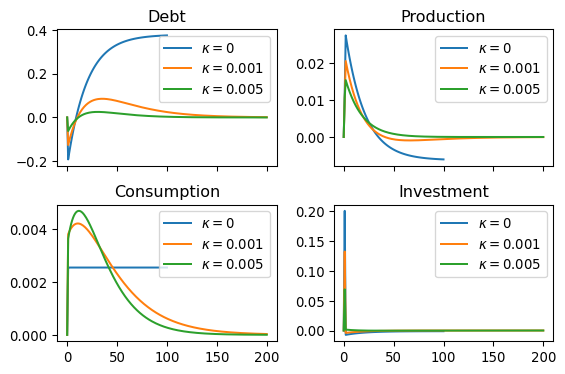